
<h2 style="color: MediumPurple; font-family:; text-align:center;font-size:35px">
  Tarea 1: Análisis Exploratorio de Datos (EDA) para EXOPLANETAS 
</h2>
<h1 style="color: MediumPurple; font-size:13.5px;"> Students: </h1>Ornella Cañellas Arredondo and Valentina Cortés Flores 
<h1 style="color: MediumPurple; font-size:13.5px;"> Rol:  </h1> 202387002-1 ;  202287510-0
<h1 style="color: MediumPurple; font-size:13.5px;"> Professor: </h1> Pía Amigo

<h2 style="color:Pink; font-family:; text-align:center;font-size:25px">
  ❁ Desafío general ❁
</h2>

<h2 style="color:Pink; font-family:; text-align:center;font-size:17px">
   ¿La población de exoplanetas observada representa realmente la población de
planetas que existe? 
</h2>

<h2 style="color:Pink; font-family:; text-align:center;font-size:25px">
  ❁ Pregunta de Investigación ❁
</h2>

<h2 style="color:Pink; font-family:; text-align:center;font-size:17px">
   ¿Qué características tienen los exoplanetas en relación con su habitabilidad?  
</h2>

<h2 style="color:#BA55D3; font-family:; text-align:center;font-size:20px">
  ❁۪ ｡˚ Metodología para escoger relaciones generales ❁۪ ｡˚
</h2>

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
%matplotlib inline
sns.set_style("white")

In [15]:
font = {'size'   : 13}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=10) 
matplotlib.rc('ytick', labelsize=10) 
matplotlib.rcParams['figure.dpi'] = 300

In [16]:
#Paquetes para visualización

from io import StringIO
from IPython.display import Image  
import pydotplus

from sklearn.tree import export_graphviz 

<h2 style="color:#BA55D3; font-family:; text-align:center;font-size:25px">
  ❁۪ ｡˚ Haciendo una revisión rápida del set de datos❁۪ ｡˚
</h2>


Cada fila de la base de datos corresponde a **un exoplaneta**.
Como hay una gran cantidad de categorías o características disponibles, algunas relevantes que se quieren tratar son; 
- `P_NAME`: Nombre del exoplaneta
- `P_DETECTION`: Aquí se menciona el método de detección ya sea por microlensing, transit, radial velocity, etc.
- `P_TEMP_SUR`: Esto menciona la temperatura superficial del exoplaneta en Kelvin (K)
- `P_YEAR`: Esto es el año en que el exoplaneta fue descubierto
- `P_PERIOD`: Esto es el periodo del exoplaneta en Días
- `P_MASS`: masa en M_Tierra (M_Earth)
- `P_RADIUS`: radio en R_Tierra (R_Earth)
- `P_TYPE_TEMP`: como es el exoplaneta en relación a temperatura cualitativa sea hot, cold o warm.
- `P_TYPE`: El tipo de exoplaneta
- `P_HABZONE_OPT`: Categoría de habitablidad óptima (1) y no habitabilidad óptima (0)
- `P_ESI`: Indica cuan similar es el exoplaneta a la Tierra, con un ESI > 0.5 se considera potencialmente habitable
etc...

In [17]:
#lectura de archivo 
EXO_set = pd.read_csv('hwc.csv', index_col=0)

In [18]:
EXO_set

,P_DETECTION,P_DISCOVERY_FACILITY,P_YEAR,P_UPDATE,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_MASS_LIMIT,P_MASS_ORIGIN,P_RADIUS,...,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_TYPE_TEMP,P_HABITABLE,P_ESI,S_CONSTELLATION,S_CONSTELLATION_ABR,S_CONSTELLATION_ENG
P_NAME,,,,,,,,,,,,,,,,,,,,,
OGLE-2016-BLG-1227L b,Microlensing,OGLE,2020,2020-04-02,250.00000,-120.00000,413.00000,0,Mass,13.90,...,NaN,0.214133,0,0,NaN,0,NaN,Scorpius,Sco,Scorpion
Kepler-276 c,Transit,Kepler,2013,2018-09-25,16.60000,-3.60000,4.40000,0,Mass,2.90,...,2.097783,0.316980,0,0,Hot,0,0.272032,Cygnus,Cyg,Swan
Kepler-829 b,Transit,Kepler,2016,2019-04-16,5.10000,NaN,NaN,0,M-R relationship,2.11,...,1.756317,0.459559,0,0,Hot,0,0.254763,Lyra,Lyr,Lyre
K2-283 b,Transit,K2,2018,2019-09-05,12.20000,NaN,NaN,0,M-R relationship,3.52,...,0.568374,0.443760,0,0,Hot,0,0.193906,Pisces,Psc,Fishes
Kepler-477 b,Transit,Kepler,2016,2019-04-16,4.94000,NaN,NaN,0,M-R relationship,2.07,...,0.768502,0.386150,0,0,Hot,0,0.276721,Lyra,Lyr,Lyre
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HD 222155 b,Radial Velocity,Haute-Provence Observatory,2011,2023-06-12,581.62598,-82.63539,111.23994,0,Mass,13.40,...,1.893917,0.541322,0,0,Cold,0,0.178593,Andromeda,And,Andromeda
HD 88986 b,Radial Velocity,Haute-Provence Observatory,2023,2023-12-04,17.20000,-3.80000,4.00000,0,Mass,2.49,...,2.520276,0.543834,0,0,Hot,0,0.379540,Leo Minor,LMi,Little Lion
Kepler-30 b,Transit,Kepler,2012,2023-11-28,11.30000,-1.40000,1.40000,0,Mass,3.90,...,1.249824,0.400198,0,0,Hot,0,0.241771,Lyra,Lyr,Lyre


In [19]:
print(EXO_set["P_DISTANCE"])
#print(EXO_set["P_NAME"][:-1])
print(EXO_set["P_MASS"][:-1])

P_NAME
OGLE-2016-BLG-1227L b    3.400000
Kepler-276 c             0.199400
Kepler-829 b             0.067800
K2-283 b                 0.029100
Kepler-477 b             0.091100
                           ...   
HD 222155 b              5.205792
HD 88986 b               0.596704
Kepler-30 b              0.180159
HD 3167 d                0.076849
OGLE-2019-BLG-1180L b    5.190000
Name: P_DISTANCE, Length: 5599, dtype: float64
P_NAME
OGLE-2016-BLG-1227L b    250.00000
Kepler-276 c              16.60000
Kepler-829 b               5.10000
K2-283 b                  12.20000
Kepler-477 b               4.94000
                           ...    
KMT-2022-BLG-0440L b      15.40000
HD 222155 b              581.62598
HD 88986 b                17.20000
Kepler-30 b               11.30000
HD 3167 d                  4.33000
Name: P_MASS, Length: 5598, dtype: float64


In [20]:
EXO_set.info()
EXO_set.shape[0]
EXO_set.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 5599 entries, OGLE-2016-BLG-1227L b to OGLE-2019-BLG-1180L b
Columns: 117 entries, P_DETECTION to S_CONSTELLATION_ENG
dtypes: float64(81), int64(18), object(18)
memory usage: 5.0+ MB


,P_YEAR,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_MASS_LIMIT,P_RADIUS,P_RADIUS_ERROR_MIN,P_RADIUS_ERROR_MAX,P_RADIUS_LIMIT,P_PERIOD,...,S_HZ_CON0_MAX,S_HZ_CON1_MIN,S_HZ_CON1_MAX,S_SNOW_LINE,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_HABITABLE,P_ESI
count,5599.000000,5592.000000,2506.000000,2506.000000,5599.000000,5592.000000,3847.000000,3847.000000,5599.000000,5.350000e+03,...,5366.000000,5366.000000,5366.000000,5366.000000,5.376000e+03,5595.000000,5599.000000,5599.000000,5599.000000,5358.000000
mean,2016.188962,442.521283,-127.777520,174.465166,0.022861,5.715494,-0.432279,0.544259,-0.000714,7.994082e+04,...,2.301153,1.239781,2.301153,3.596167,1.014471e+35,0.425790,0.047151,0.033577,0.019825,0.257089
std,4.527714,2369.505048,383.670428,625.151645,0.160982,5.331450,0.960669,1.568228,0.026721,5.498596e+06,...,4.587874,2.390133,4.587874,6.741964,5.259131e+36,0.077064,0.211981,0.180155,0.184617,0.131622
min,1992.000000,0.020000,-6038.739700,0.000000,-1.000000,0.310000,-32.506000,0.000000,-1.000000,9.070629e-02,...,0.001910,0.000911,0.001910,0.002434,4.356319e-05,0.029269,0.000000,0.000000,0.000000,0.023896
25%,2014.000000,4.040000,-73.100900,2.712500,0.000000,1.780000,-0.480000,0.130000,0.000000,4.465382e+00,...,1.060687,0.568834,1.060687,1.615711,4.781093e-01,0.391256,0.000000,0.000000,0.000000,0.186192
50%,2016.000000,8.750000,-19.069800,20.000000,0.000000,2.780000,-0.220000,0.280000,0.000000,1.156951e+01,...,1.561742,0.854147,1.561742,2.502441,1.361846e+00,0.443760,0.000000,0.000000,0.000000,0.268055
75%,2020.000000,162.092490,-2.542630,85.813670,0.000000,11.900000,-0.110000,0.581500,0.000000,4.150555e+01,...,2.364700,1.299225,2.364700,3.873593,2.556535e+00,0.470516,0.000000,0.000000,0.000000,0.301299
max,2024.000000,89700.000000,0.000000,12395.308000,1.000000,77.342000,0.000000,68.910000,0.000000,4.020000e+08,...,120.348830,67.331558,120.348830,214.468620,2.726899e+38,1.003328,1.000000,1.000000,2.000000,0.968362



<h2 style="color:#BA55D3; font-family:; text-align:center;font-size:20px">
  ¿Cuáles variables son numéricas y cuáles son categóricas?
</h2>
Se tienen variables numéricas como lo son la masa, el período del exoplaneta, la temperatura superficial, entre otras. Por otra parte, las variables categóricas resultan ser el nombre del exoplaneta, el año en que fue descubierto, el método por el que fue detectado, la temperatura de forma cualitativa (hot, warm, cold), entre otros.

<h2 style="color:#BA55D3; font-family:; text-align:center;font-size:20px">
  Comprensión de la muestra de exoplanetas
</h2>


Antes de estudiar la supervivencia, necesitamos comprender a que tipo  representan los datos. Con las preguntas iniciales se van comprendiendo los datos que se incluyen en la tabla, solo como un acercamiento a la muestra, después se van creando gráficas para analizar y establecer otras relaciones.

Preguntas iniciales:

- ¿Cuántos exoplanetas se tienen en la muestra ? Se tienen 5598 exoplanetas
  
- ¿Qué características contiene la base de datos? La base de datos contiene variadas características tanto cuantitativas como cualitativas, lo que se puede ver en la parte de variables numéricas y categóricas, que de alguna forma muestran y permiten clasificar las categorías. 

- ¿Cómo son las unidades por período y masa? el período está en días, y masa en M_Earth

  
- ¿Cuántos métodos de detección hay? Hay 11 métodos de detección (observando gráfica de más abajo)

  
- ¿Cuáles son los radios de los exoplanetas? Hay variados cuyo promedio es 5.715494 Rterrestre (muchos son terrestres)

  
- ¿Hay más exoplanetas con períodos largos o cortos? Depende del rango que se defina largo o corto, pero viendo la tabla se tiene un promedio de período de 79940 días

  
- ¿En qué año se detectaron más exoplanetas? Se detectaron más exoplanetas en el año 2016.

Revise la estructura general de la tabla: dimensión, columnas, estadística básica, etc.

In [21]:
EXO_set.info()  #aqui se ven por categoria la cantidad de los datos existentes y no existentes
EXO_set.shape[0] #aqui la cantidad
EXO_set.describe() #con este comando se pueden ver las estadísticas de los datos

<class 'pandas.core.frame.DataFrame'>
Index: 5599 entries, OGLE-2016-BLG-1227L b to OGLE-2019-BLG-1180L b
Columns: 117 entries, P_DETECTION to S_CONSTELLATION_ENG
dtypes: float64(81), int64(18), object(18)
memory usage: 5.0+ MB


,P_YEAR,P_MASS,P_MASS_ERROR_MIN,P_MASS_ERROR_MAX,P_MASS_LIMIT,P_RADIUS,P_RADIUS_ERROR_MIN,P_RADIUS_ERROR_MAX,P_RADIUS_LIMIT,P_PERIOD,...,S_HZ_CON0_MAX,S_HZ_CON1_MIN,S_HZ_CON1_MAX,S_SNOW_LINE,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABZONE_OPT,P_HABZONE_CON,P_HABITABLE,P_ESI
count,5599.000000,5592.000000,2506.000000,2506.000000,5599.000000,5592.000000,3847.000000,3847.000000,5599.000000,5.350000e+03,...,5366.000000,5366.000000,5366.000000,5366.000000,5.376000e+03,5595.000000,5599.000000,5599.000000,5599.000000,5358.000000
mean,2016.188962,442.521283,-127.777520,174.465166,0.022861,5.715494,-0.432279,0.544259,-0.000714,7.994082e+04,...,2.301153,1.239781,2.301153,3.596167,1.014471e+35,0.425790,0.047151,0.033577,0.019825,0.257089
std,4.527714,2369.505048,383.670428,625.151645,0.160982,5.331450,0.960669,1.568228,0.026721,5.498596e+06,...,4.587874,2.390133,4.587874,6.741964,5.259131e+36,0.077064,0.211981,0.180155,0.184617,0.131622
min,1992.000000,0.020000,-6038.739700,0.000000,-1.000000,0.310000,-32.506000,0.000000,-1.000000,9.070629e-02,...,0.001910,0.000911,0.001910,0.002434,4.356319e-05,0.029269,0.000000,0.000000,0.000000,0.023896
25%,2014.000000,4.040000,-73.100900,2.712500,0.000000,1.780000,-0.480000,0.130000,0.000000,4.465382e+00,...,1.060687,0.568834,1.060687,1.615711,4.781093e-01,0.391256,0.000000,0.000000,0.000000,0.186192
50%,2016.000000,8.750000,-19.069800,20.000000,0.000000,2.780000,-0.220000,0.280000,0.000000,1.156951e+01,...,1.561742,0.854147,1.561742,2.502441,1.361846e+00,0.443760,0.000000,0.000000,0.000000,0.268055
75%,2020.000000,162.092490,-2.542630,85.813670,0.000000,11.900000,-0.110000,0.581500,0.000000,4.150555e+01,...,2.364700,1.299225,2.364700,3.873593,2.556535e+00,0.470516,0.000000,0.000000,0.000000,0.301299
max,2024.000000,89700.000000,0.000000,12395.308000,1.000000,77.342000,0.000000,68.910000,0.000000,4.020000e+08,...,120.348830,67.331558,120.348830,214.468620,2.726899e+38,1.003328,1.000000,1.000000,2.000000,0.968362


Nuevamente, para hacer un approach antes de analizar relaciones, tenemos las siguientes preguntas 
• ¿qué representa una observación? La observación en ML es el proceso mismo del monitoreo de los datos que ingresan (inputs) en una ejecución específicamente para características correspondientes a una variable para un punto específico, asimismo también para los datos de salida (outputs) denominados como los targets que se encuentran en el aprendizaje supervisado. Además, la observación en si misma ayuda a la detección de muchas situaciones en los datos usados/trabajados, como por ejemplo detectar datos atípicos, posibles sesgos observacionales, superposiciones de datos, diferencias entre ellos mismos, etc.
• ¿qué población está siendo estudiada? Como se había mencionado, se están estudiando diversos exoplanetas. 
• ¿cuáles son las principales features? También se mencionaron más arriba, como la temperatura superficial, el período, la distancia del exoplaneta a su Sol, etc.
• ¿qué tipo de información contiene cada una? Por ejemplo, la distancia, que se encuentra en UA (Unidad Astronómica), otorga el valor numérico de distancia del exoplaneta a su Sol, la habitabilidad óptima otorga categóricamente si la habitabilidad del exoplaneta es óptima (1) o no (0), entre otros.
• ¿existen valores faltantes, valores extremos o problemas de calidad? Sí (adelanto), esto se ve y justifica más adelante a través de las representaciones gráficas.
• ¿hay alguna limitación importante en la forma en que se obtuvieron los datos? También esto se discute más adelante

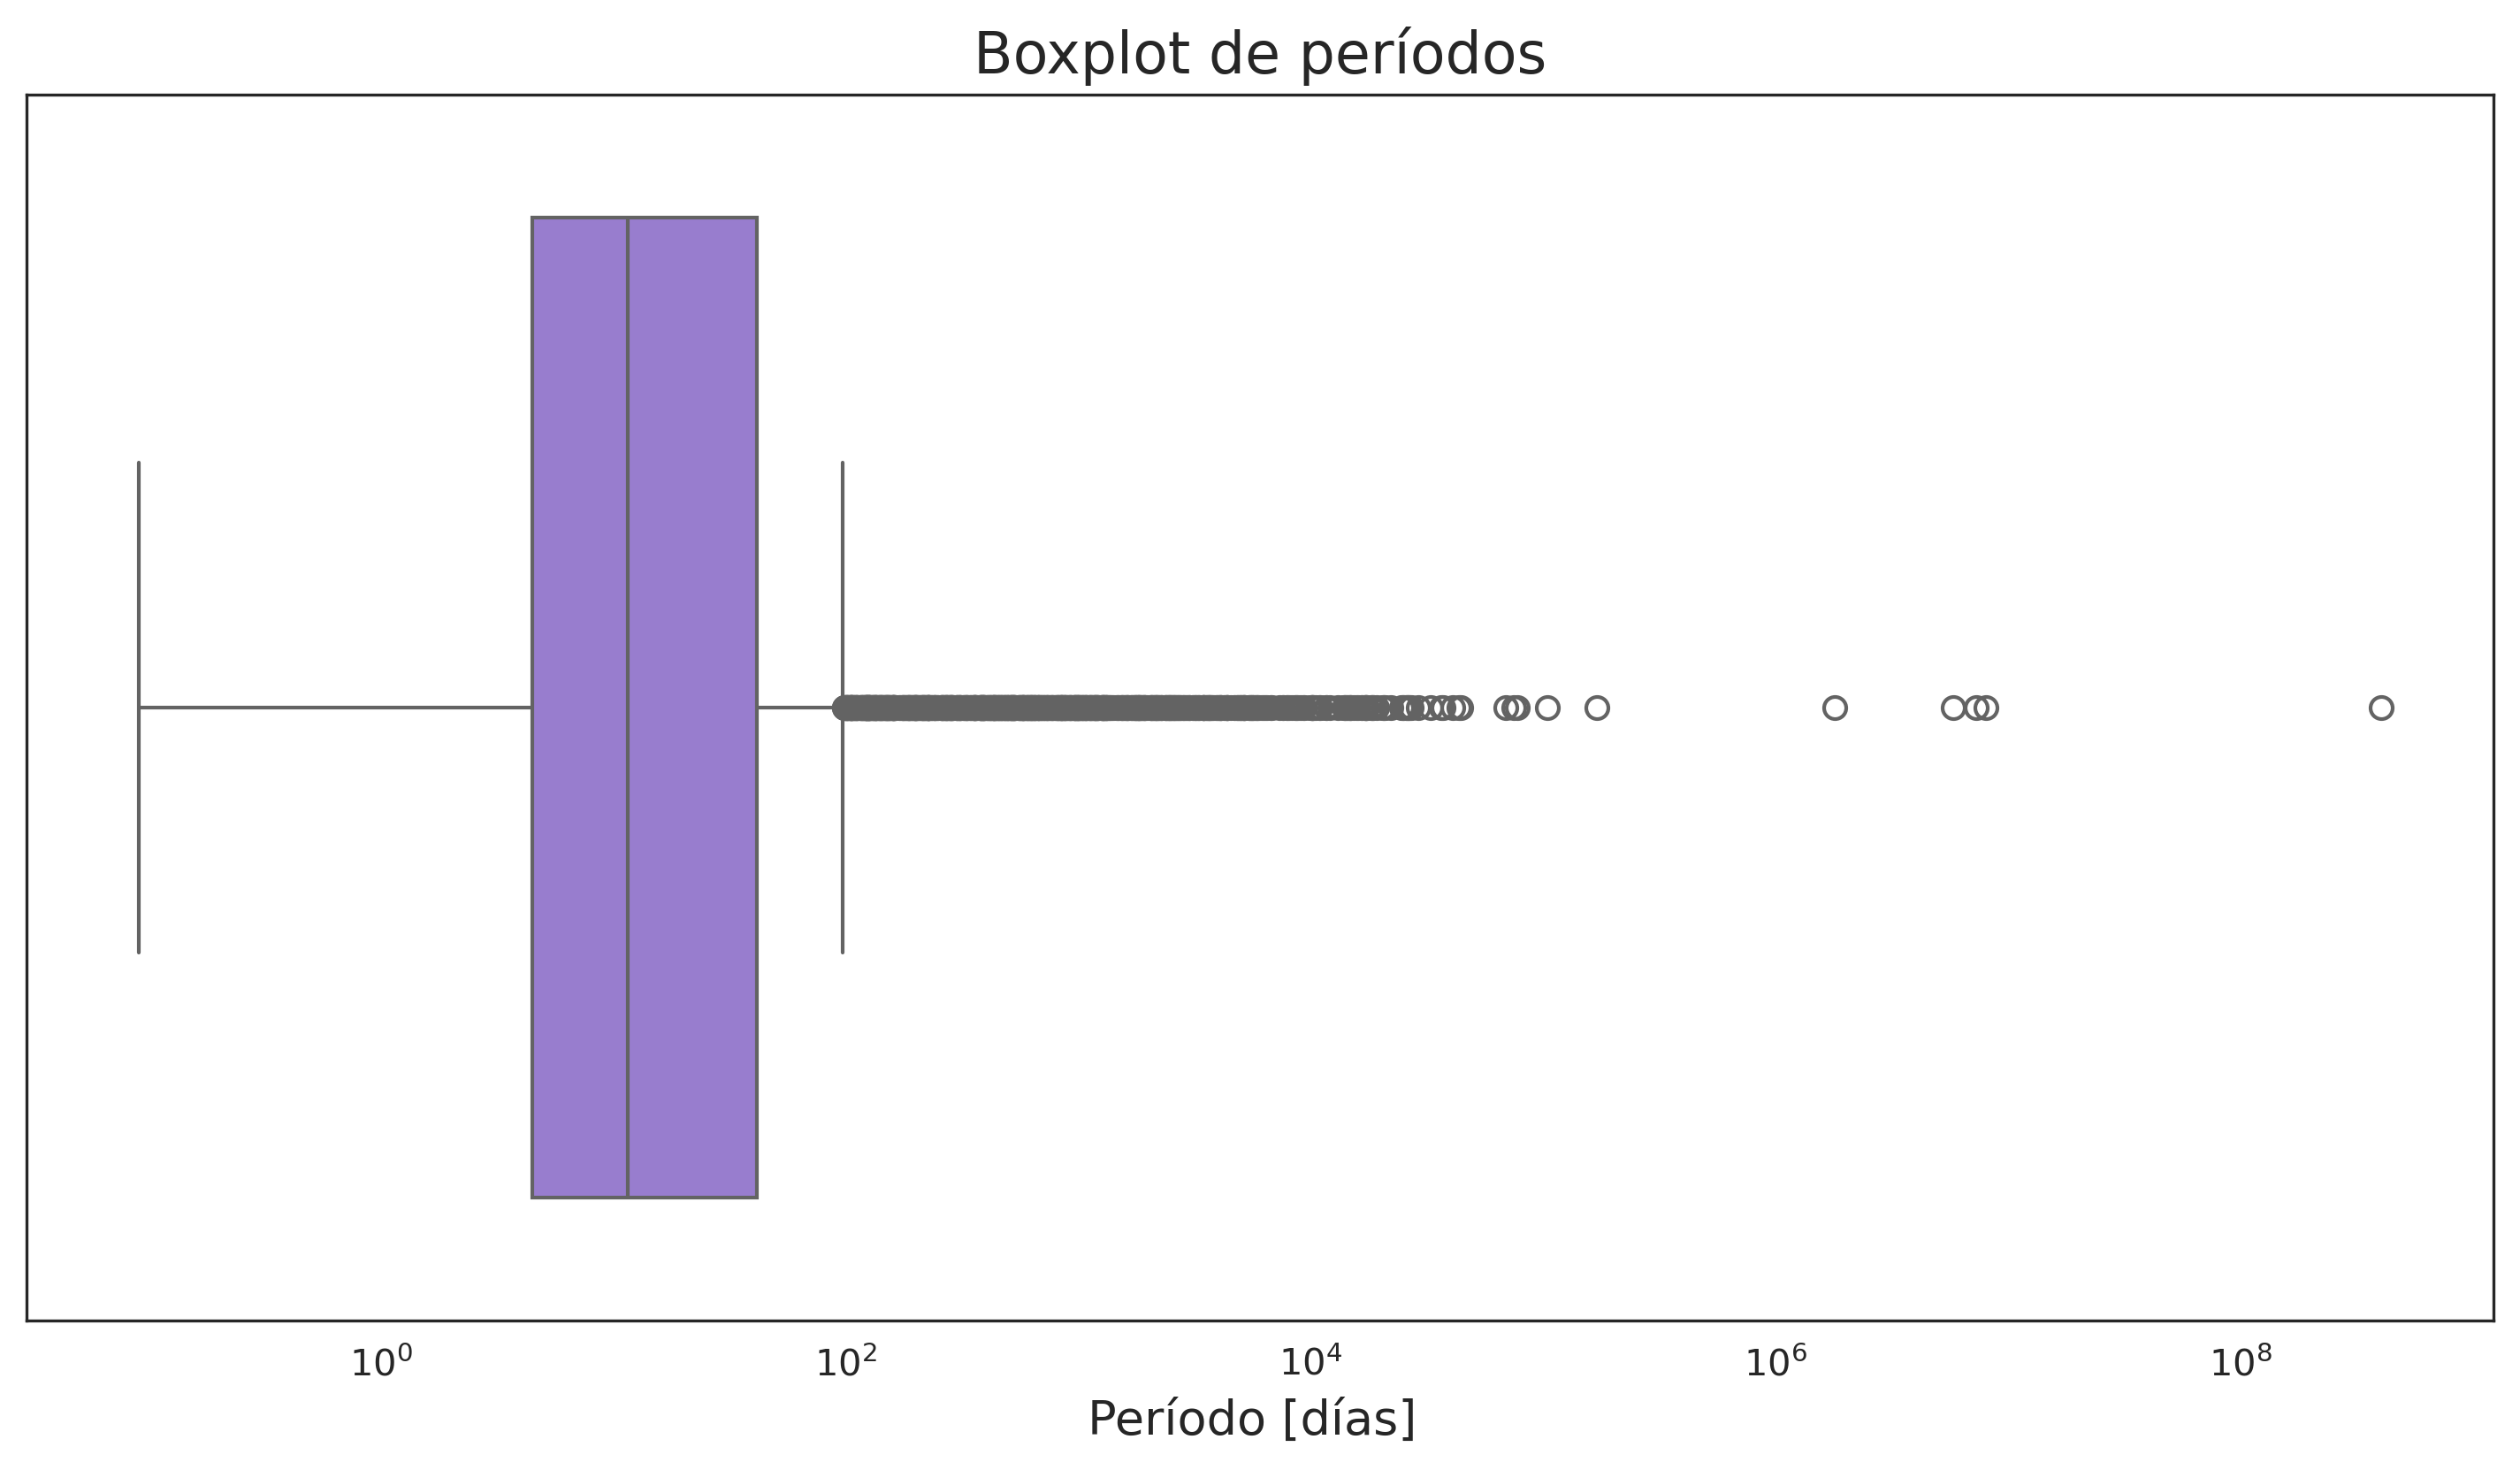

79940.81961236008 11.569511 4.4653823500000005 41.50555475


In [22]:
plt.figure(figsize=(12,6))
sns.boxplot(data=EXO_set,x="P_PERIOD",color="mediumpurple")
#Para localizar cuartiles, media y mediana
median = EXO_set["P_PERIOD"].median()
Q1 = EXO_set["P_PERIOD"].quantile(0.25)
Q3 = EXO_set["P_PERIOD"].quantile(0.75)
mean = EXO_set["P_PERIOD"].mean()
#plt.axvline(Q1, color="pink", linestyle="-", label=f"Q1 = {Q1:.1f}")
#plt.axvline(median, color="fuchsia", linestyle="-.", label=f"Mediana = {median:.1f}")
#plt.axvline(Q3, color="pink", linestyle="-", label=f"Q3 = {Q3:.1f}")
#plt.axvline(mean, color="grey", linestyle="-", label=f"Media = {mean:.1f}")
#plt.legend(fontsize=7,loc="lower right")
plt.xlabel("Período [días] ")
plt.title("Boxplot de períodos")
plt.xscale("log")
plt.show()
print(mean, median,Q1,Q3)

Por ejemplo, en la gráfica de períodos claramente se ven valores atípicos, donde para los datos proporcionados, el promedio de período es alrededor de 79940 días, la mediana es de 11.56 días, el primer cuartil es alrededor de 4.5 días y el tercer cuartil es aprox. 41.5 días.

### Ejemplo de gráfico: Exoplanetas por año

Para una característica categórica podemos comenzar contando exoplanetas fueron detectados en años específicos.


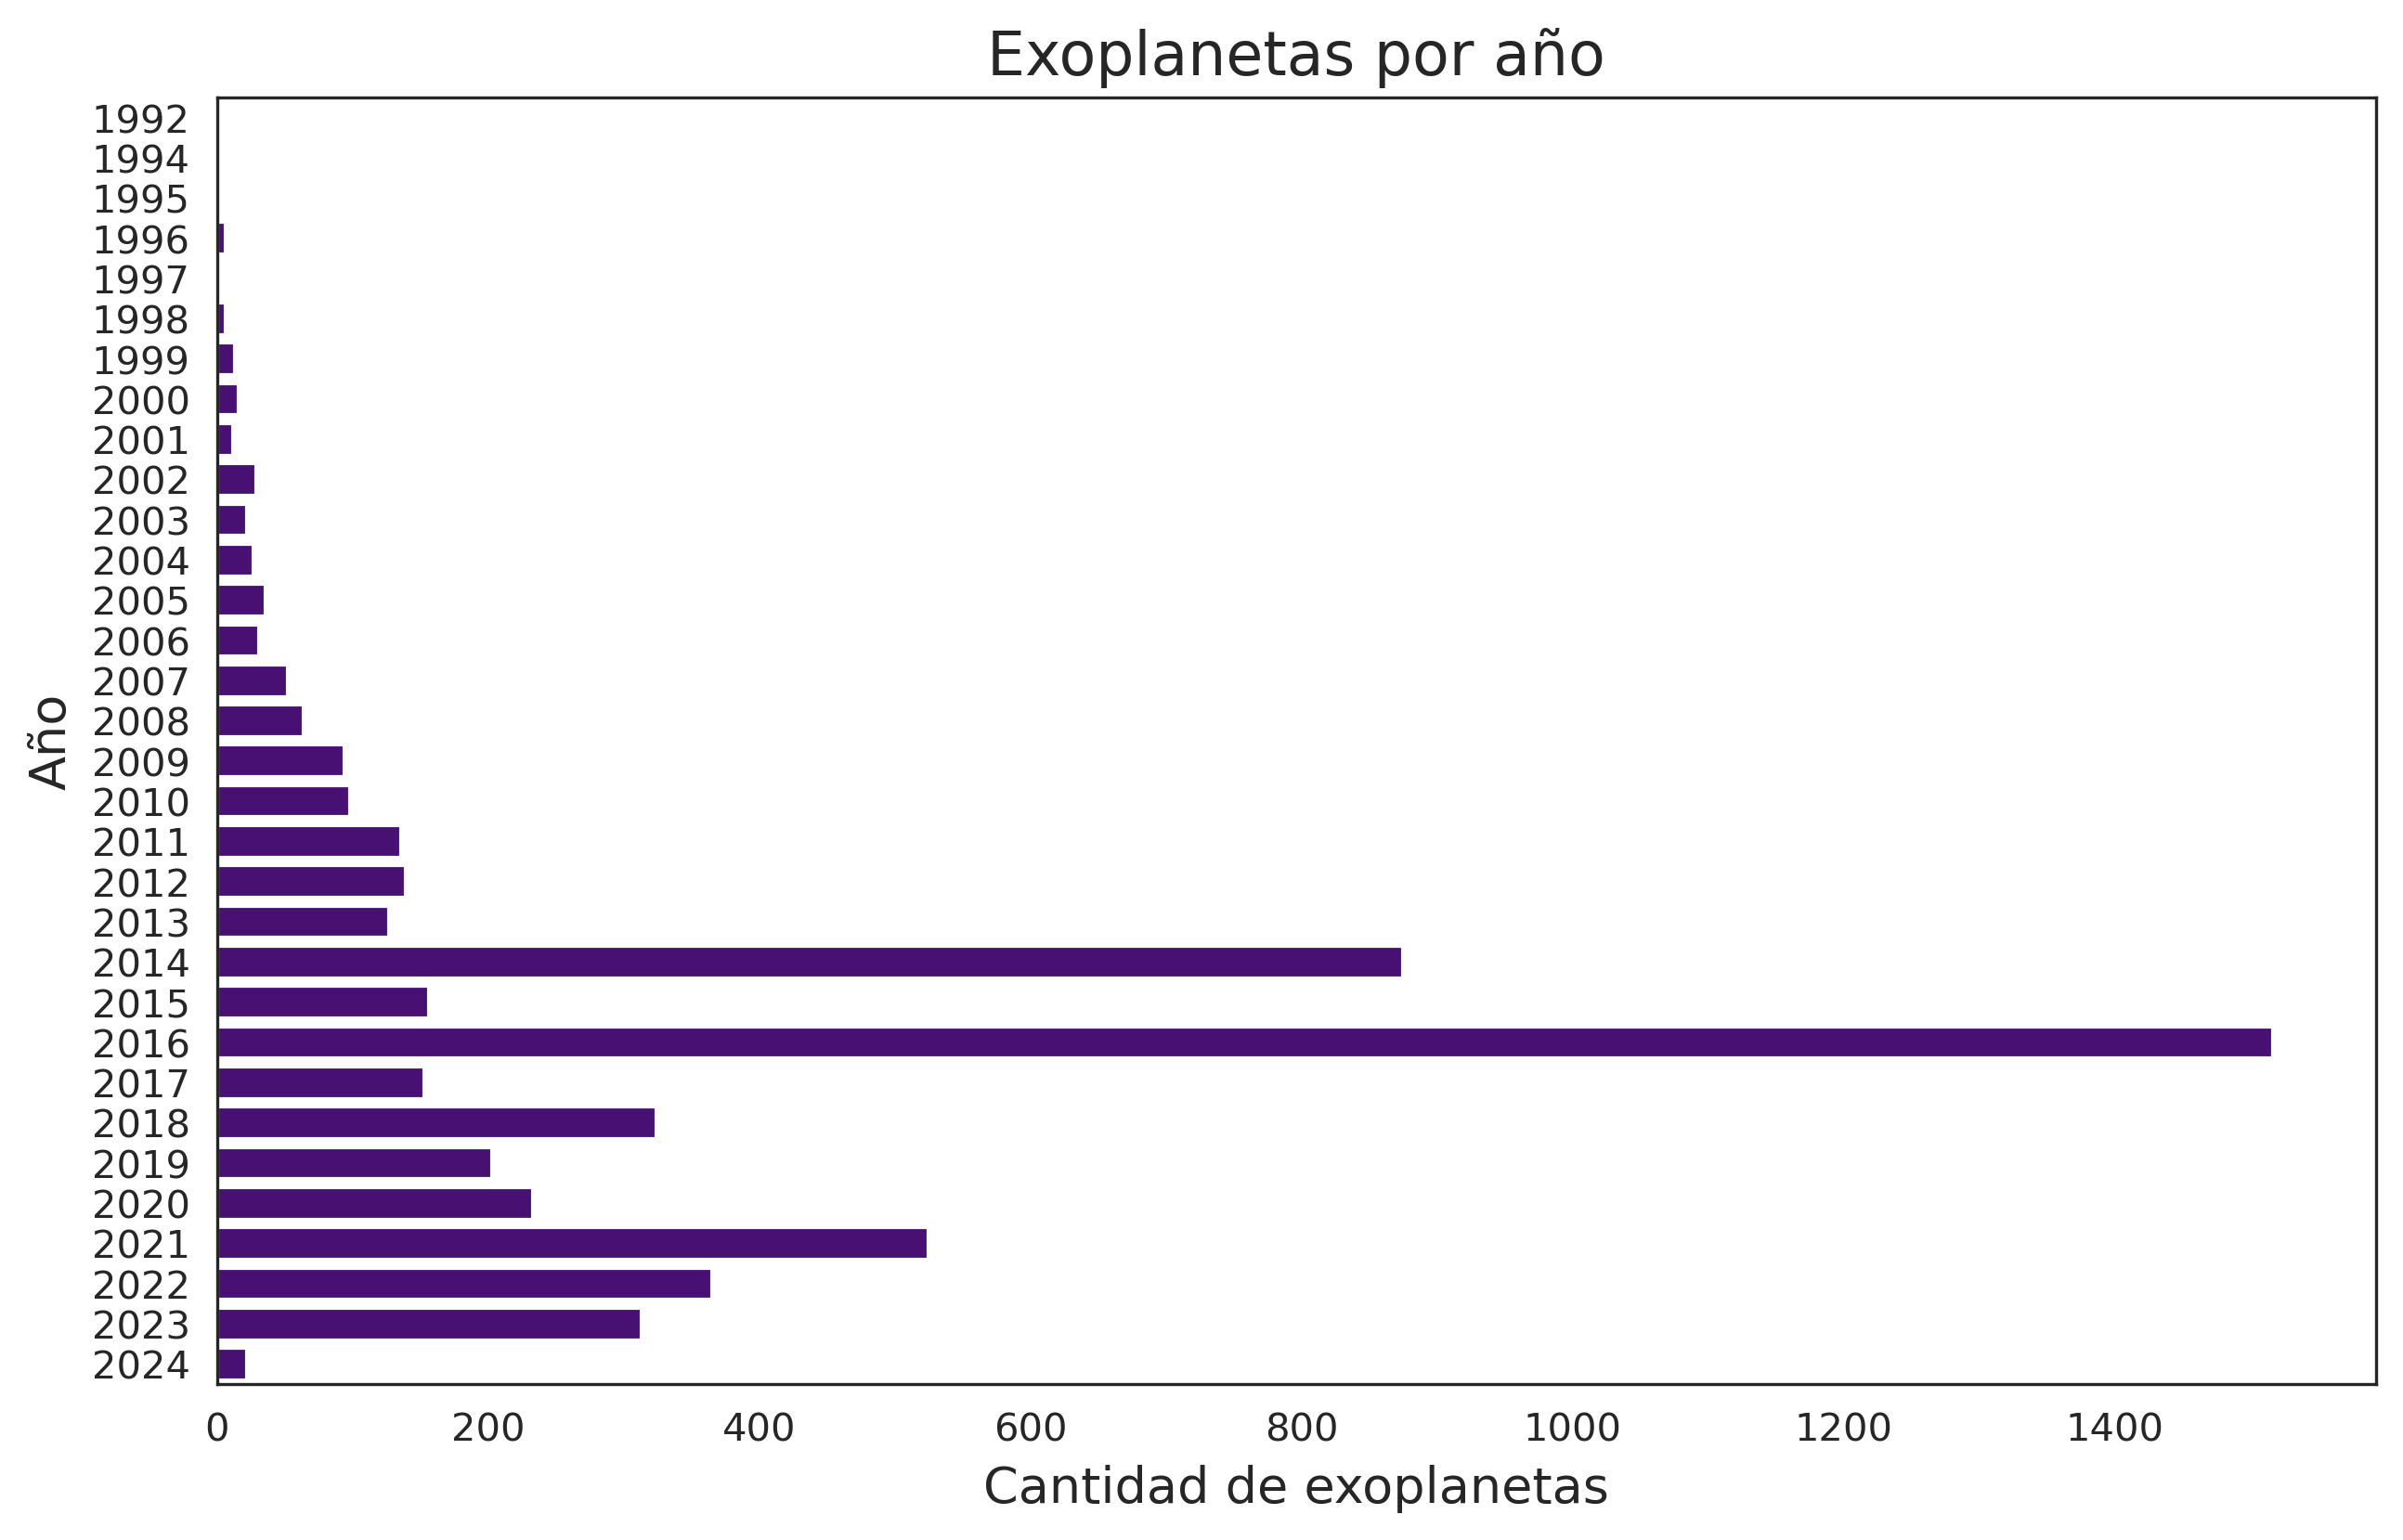

In [23]:
plt.figure(figsize=(10,6))
sns.countplot(data=EXO_set, y="P_YEAR", color="Indigo")
plt.xlabel("Cantidad de exoplanetas")
plt.ylabel("Año")
plt.title("Exoplanetas por año")
plt.show()

**1. Graficando cantidad de exoplanetas por método de detección.**

- Qué tipo de detección tiene más exoplanetas? La detección por tránsito.
- La muestra está balanceada entre los tipos de detección? Claramente, no está balanceada pues se puede ver que domina detección por tránsito, posteriormente por velocidad radial, luego microlentes y después hay relativas pequeñas cantidades de exoplanetas detectados con TTV, imaging, ETV, entre otros.

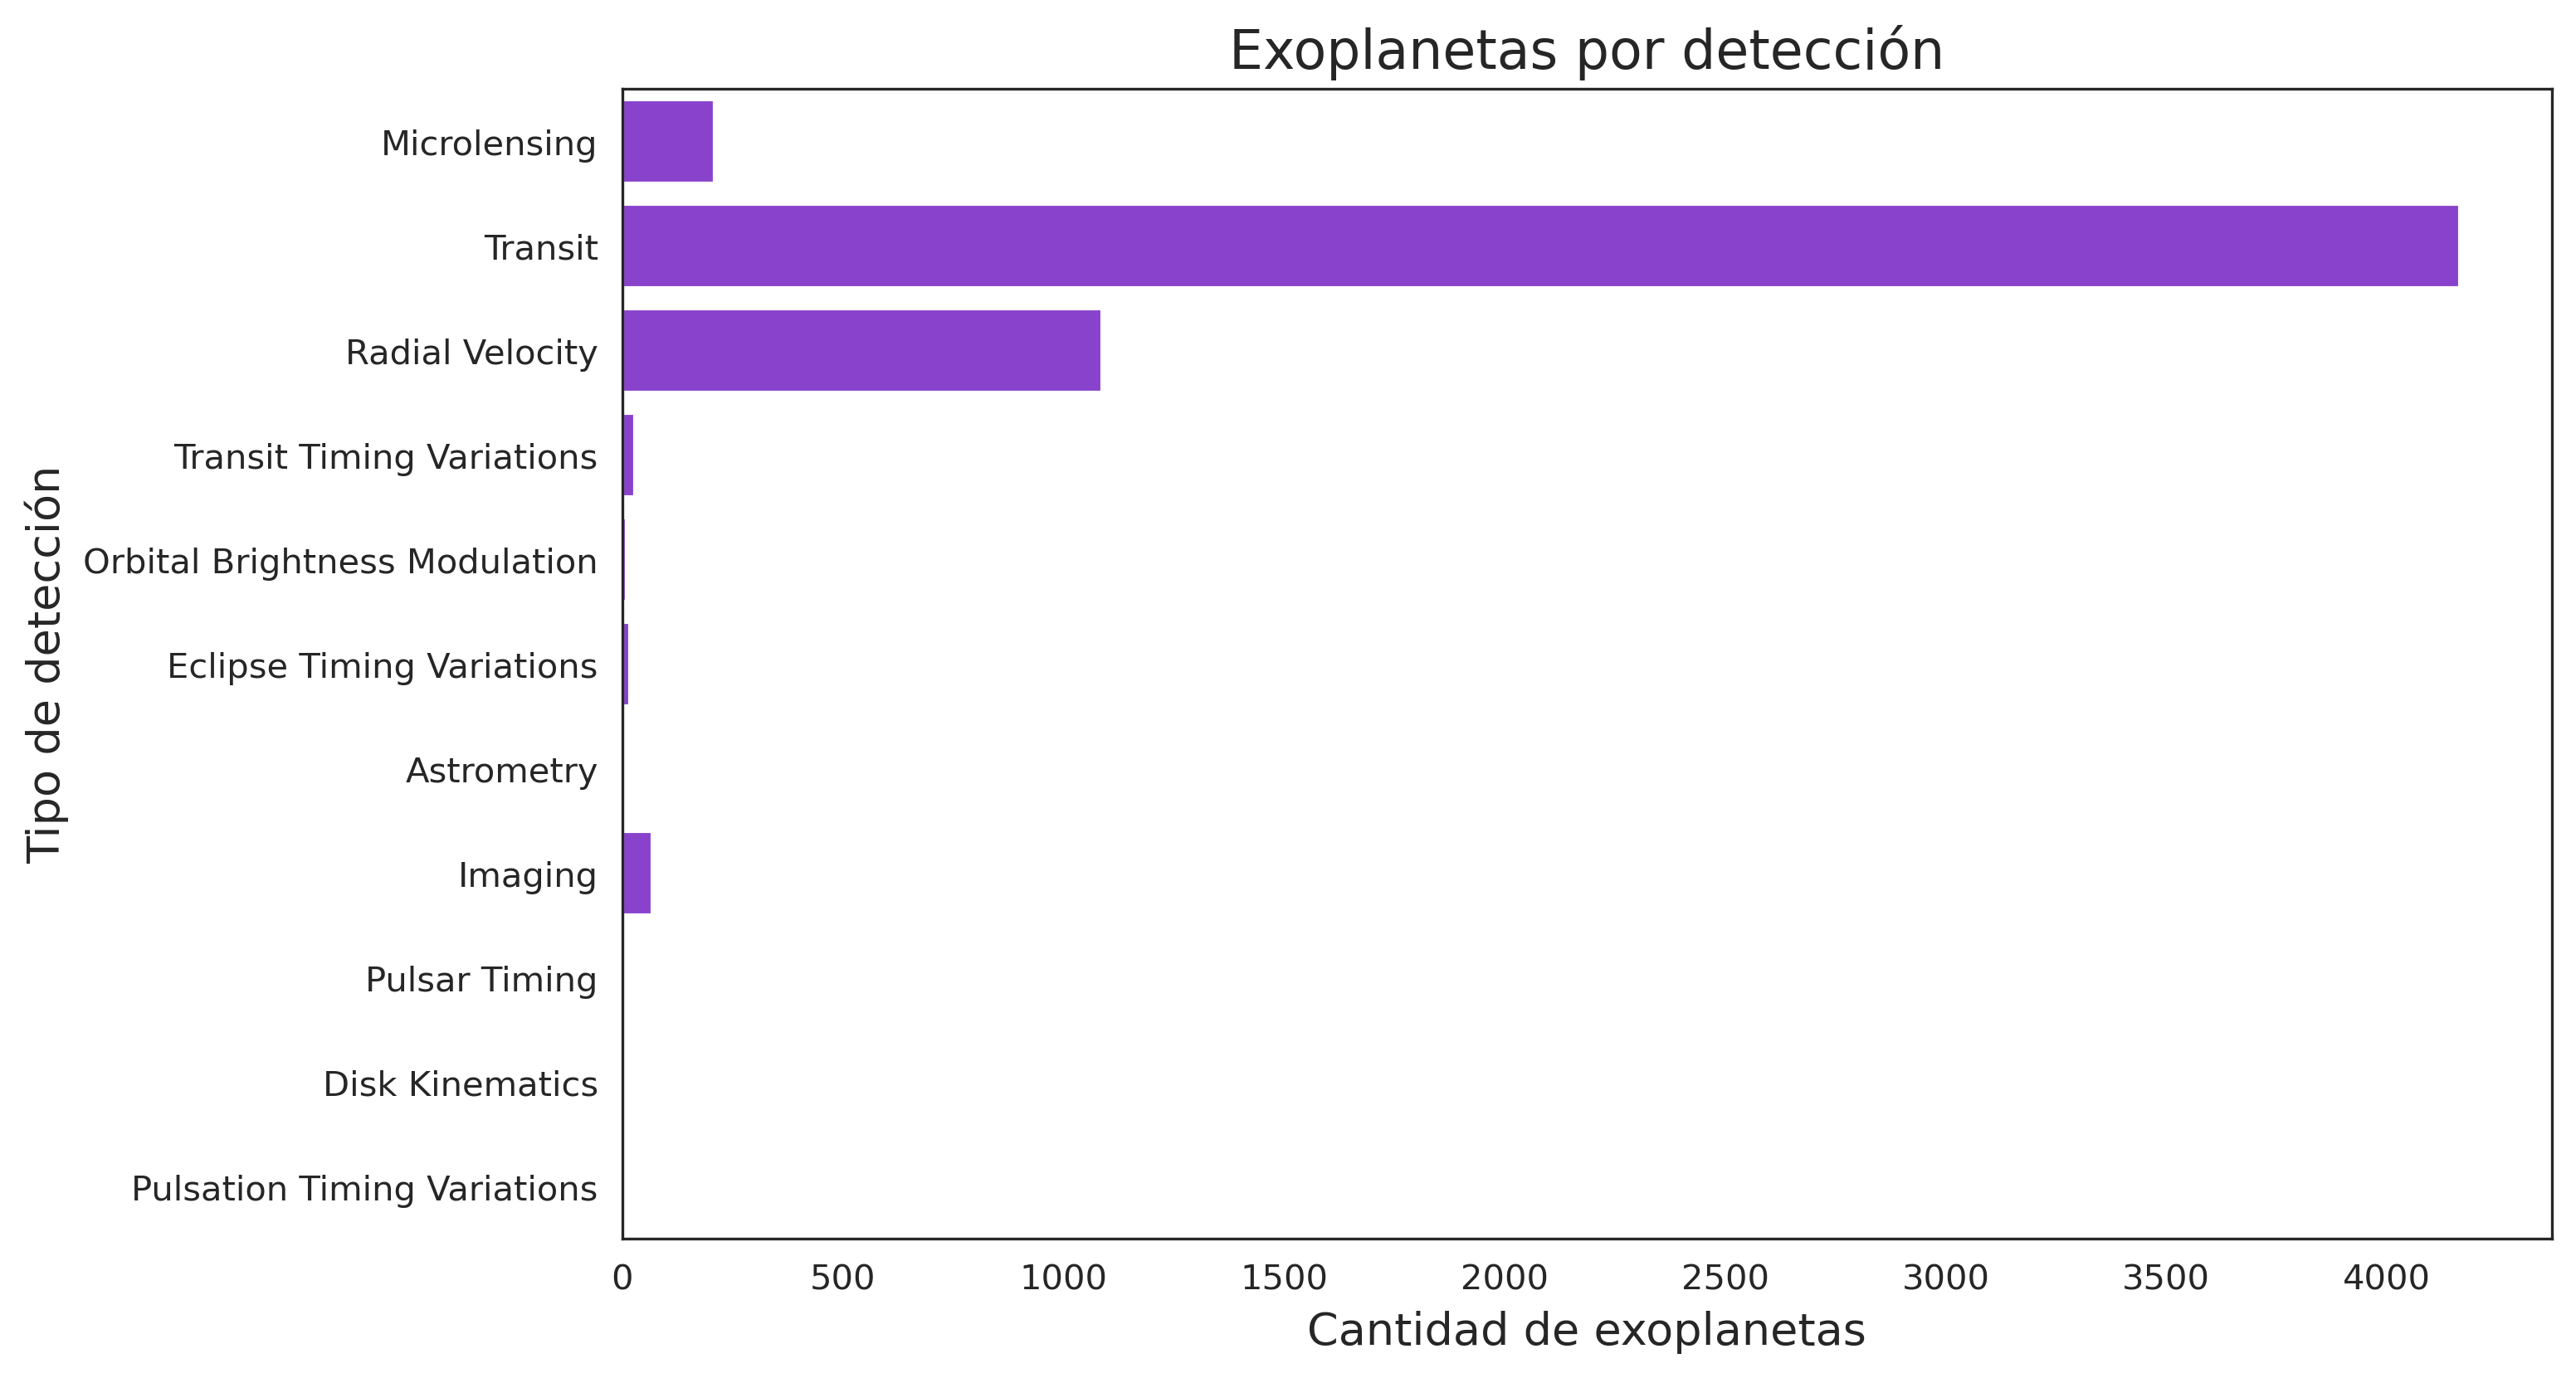

In [24]:
plt.figure(figsize=(10,6))
sns.countplot(data=EXO_set, y="P_DETECTION", color="blueviolet")
plt.xlabel("Cantidad de exoplanetas")
plt.ylabel("Tipo de detección")
plt.title("Exoplanetas por detección")
plt.show()

 2.Graficando la cantidad de exoplanetas según `TEMP TYPE`.

- Qué clase (o tipo) cualitativa de temperatura contiene más exoplanetas? Primero la clase Hot, luego la clase cold, y luego la warm.
  
- La muestra está balanceada entre las tres clases de temperatura? No está balanceada, puesto que hay muchísimos exoplanetas detectados que son de clase Hot.


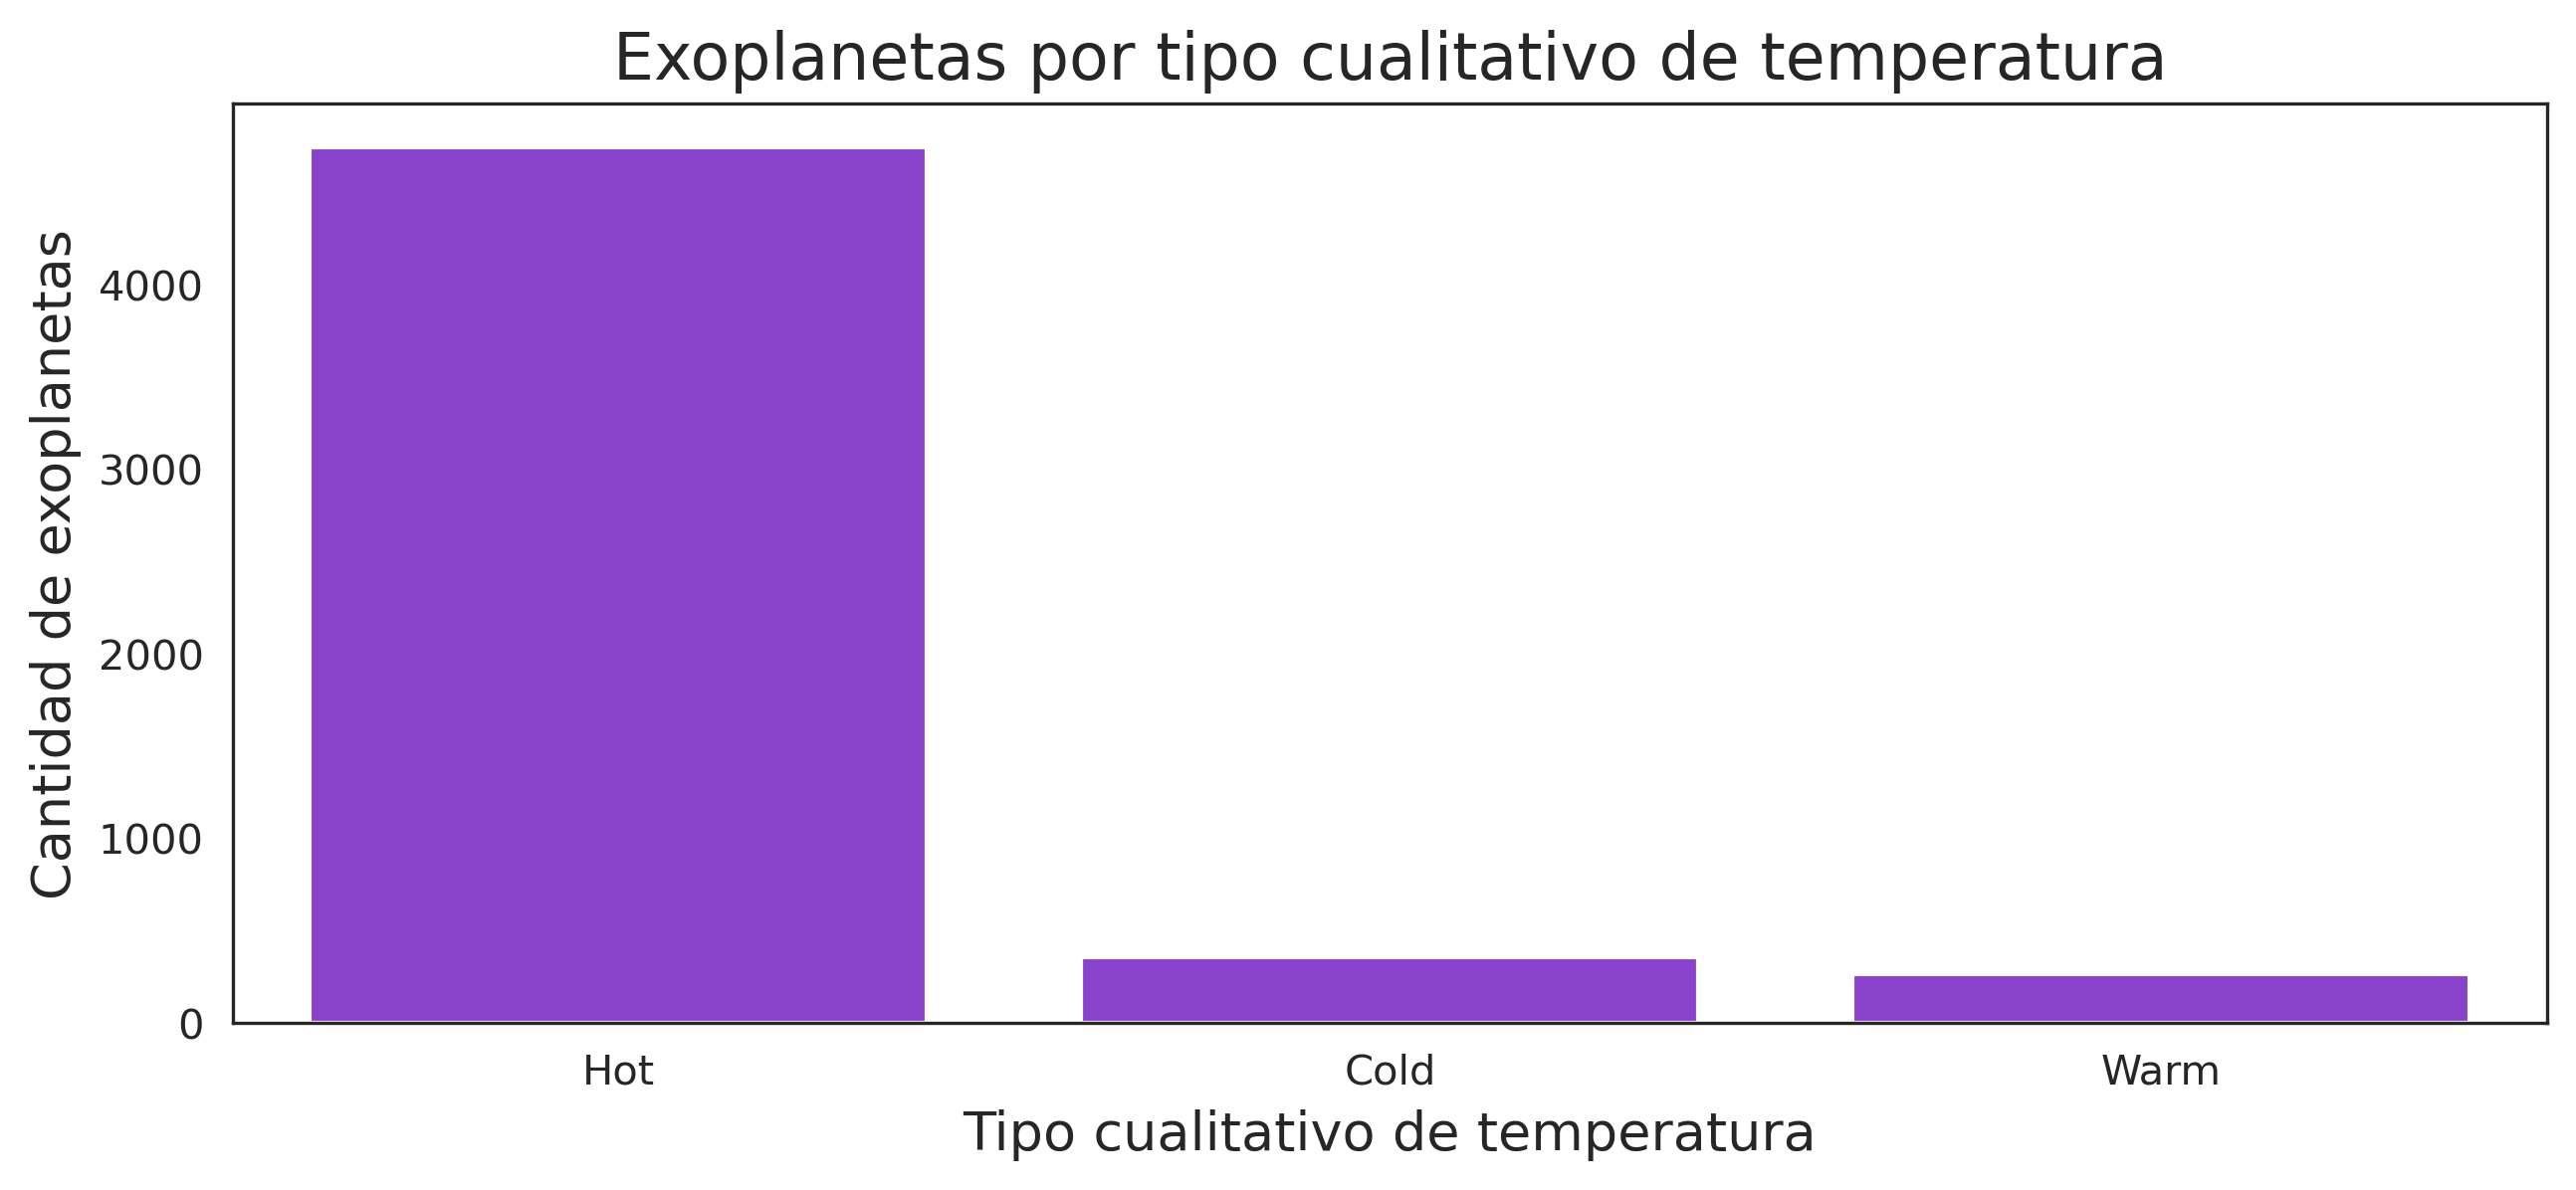

In [25]:
#relacion periodo y P_TYPE_TEMP
plt.figure(figsize=(10,4))
sns.countplot(data=EXO_set, x="P_TYPE_TEMP", color="blueviolet")
plt.xlabel("Tipo cualitativo de temperatura")
plt.ylabel("Cantidad de exoplanetas")
plt.title("Exoplanetas por tipo cualitativo de temperatura")
plt.show()

3. Se explora la relación entre período y masa con scatter.
- En el scatter se puede ver alguna concentración para valores específicos? Sí, específicamente entre períodos de alrededor 0.5 días a 120 días. Y de masas entre 0.1 Masas terrestres a casi 10000 masas terrestres.
- Hay datos alejados? Si se ve un dato más alejado para una masa entre 1000 y 10000 masas terrestres y 10^8 días para el período.
  

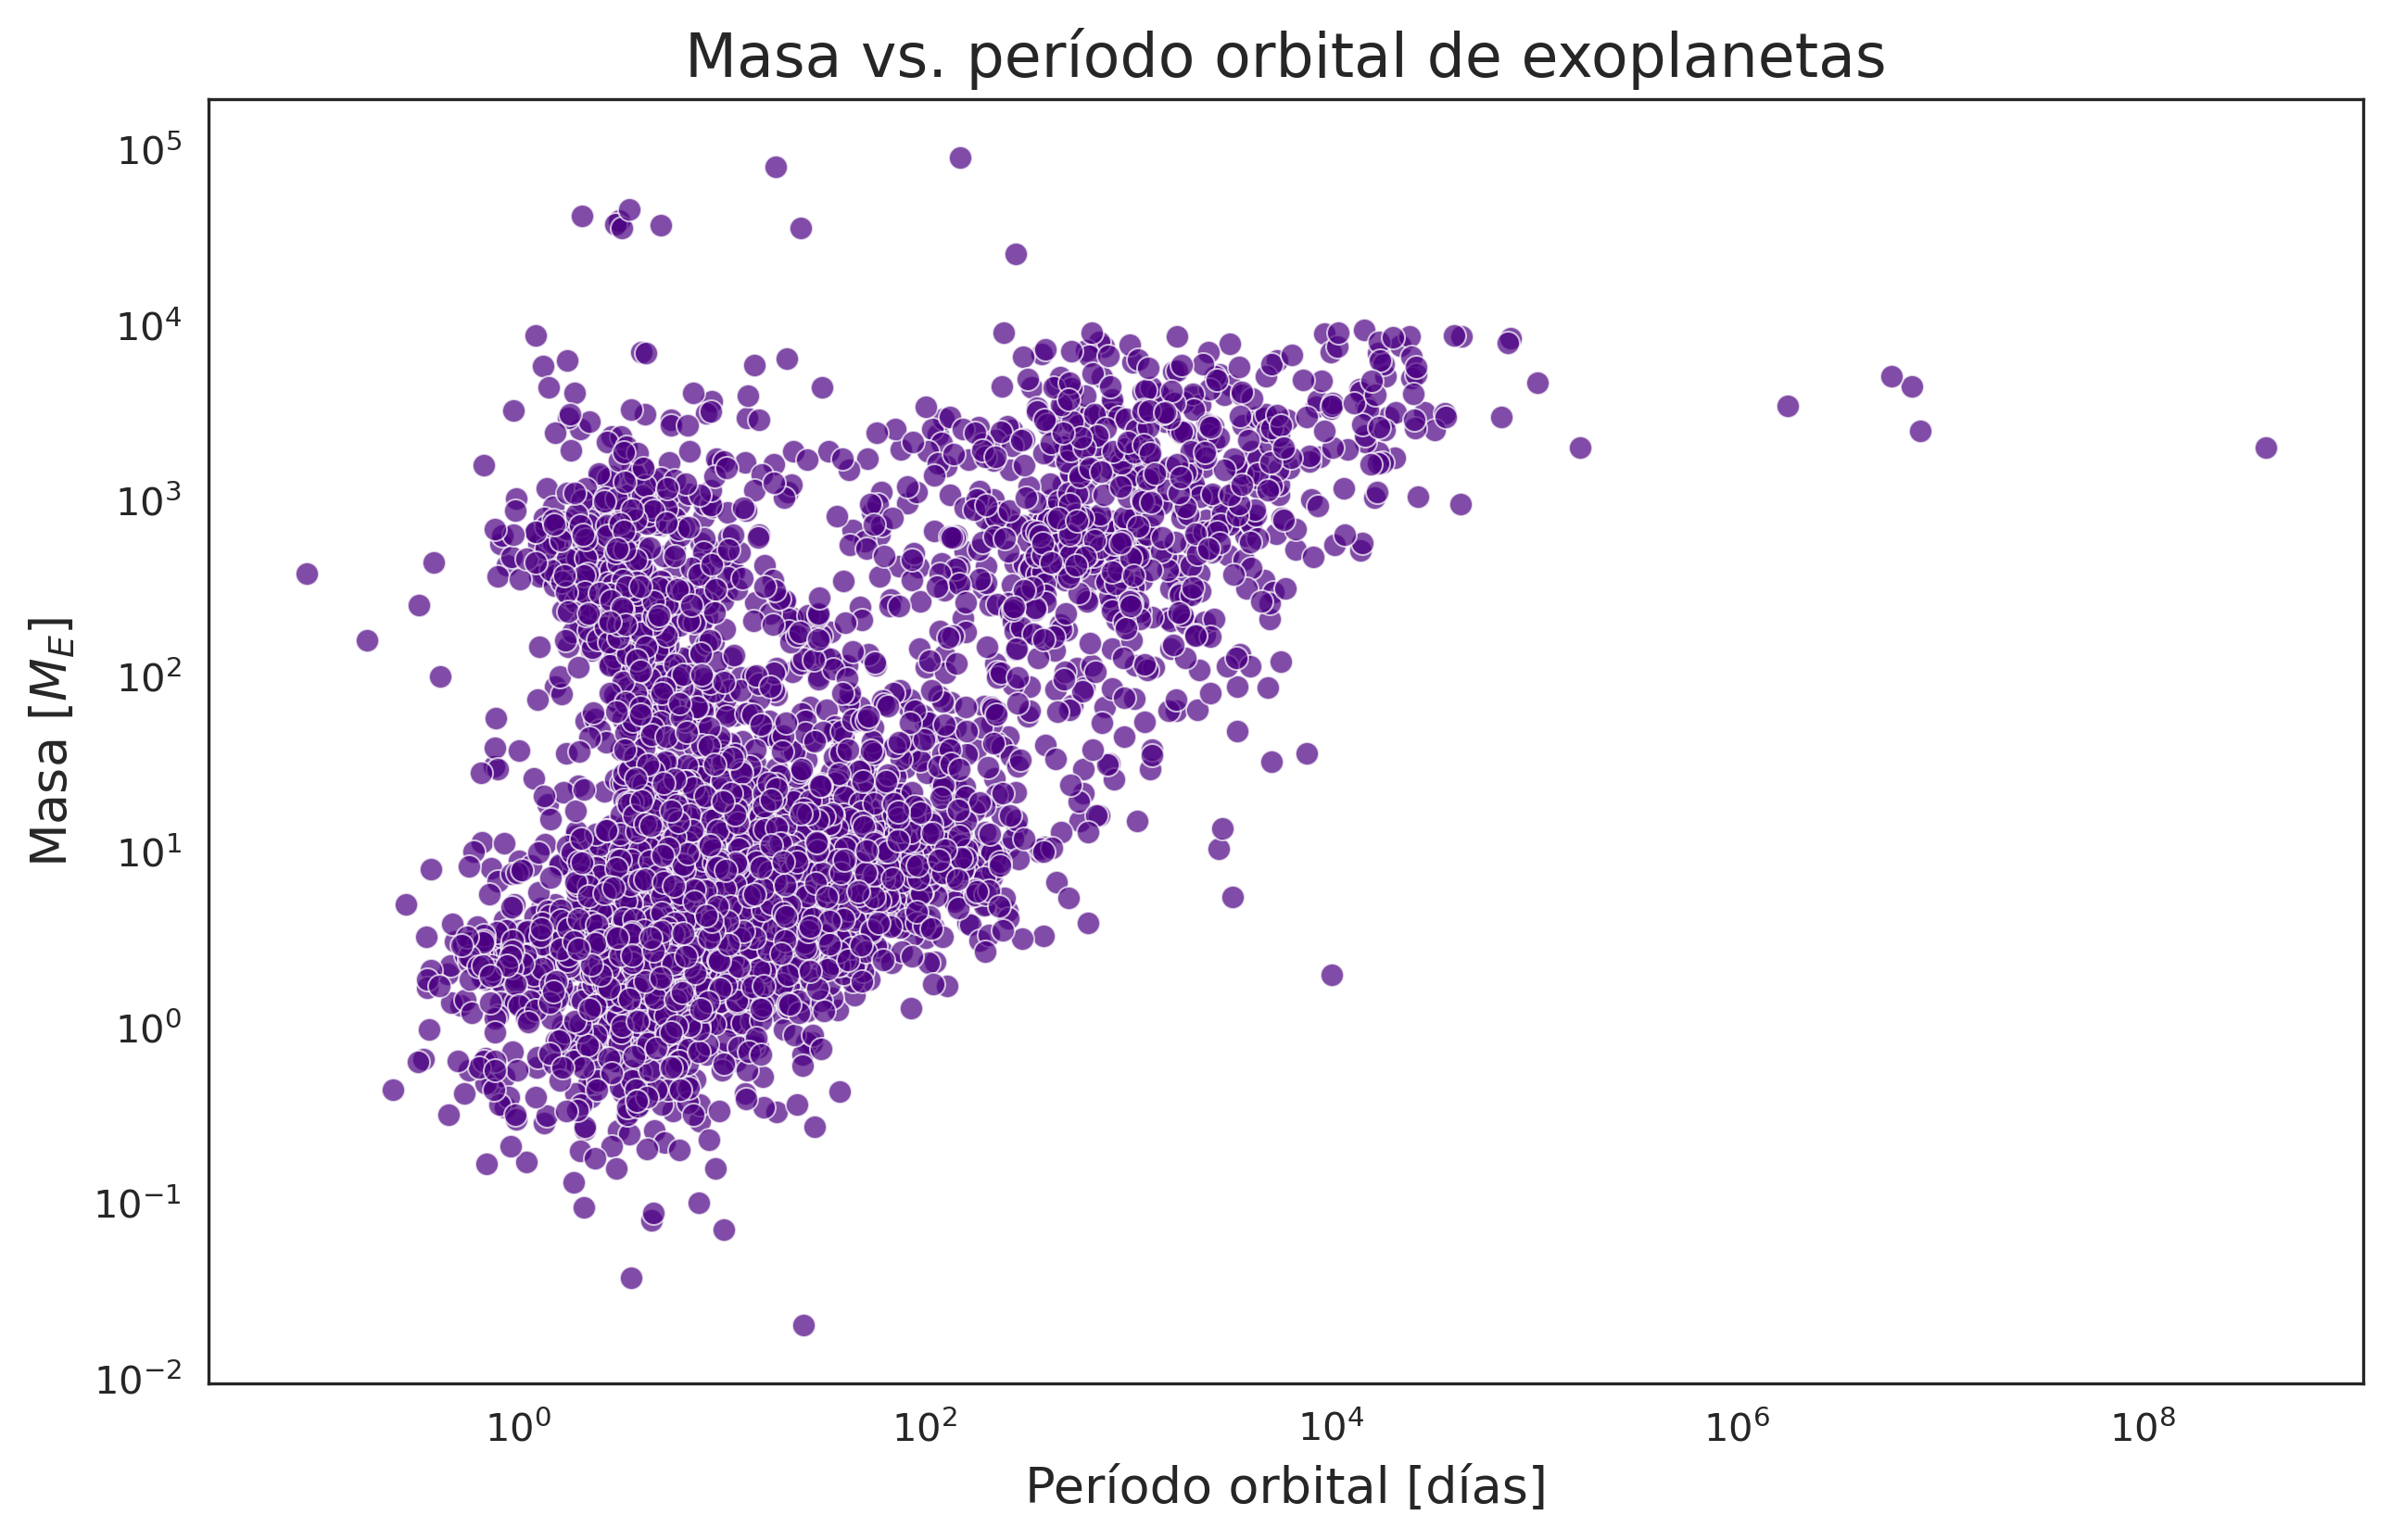

In [26]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=EXO_set,
    x="P_PERIOD",
    y="P_MASS",
    color="indigo",
    alpha=0.7
)

plt.xlabel("Período orbital [días]")
plt.ylabel(r"Masa [$M_E$]")
plt.title("Masa vs. período orbital de exoplanetas")

plt.xscale("log")
plt.yscale("log")

plt.show()

3. Explorando el período orbital respecto al año de detección
   
   En qué año se tienen detecciones de exoplanetas con más períodos? Esto es ambiguo, y diriamos que no se puede saber directamente, porque en los scatter por año pueden haber muchos puntos sobrepuestos.
   En qué año se tienen detecciones de exoplanetas con períodos o algún período mayor? En 2021, con un período de más de 10^8 días, luego en 2006 y 2015 con un poco más de 10^6 días.

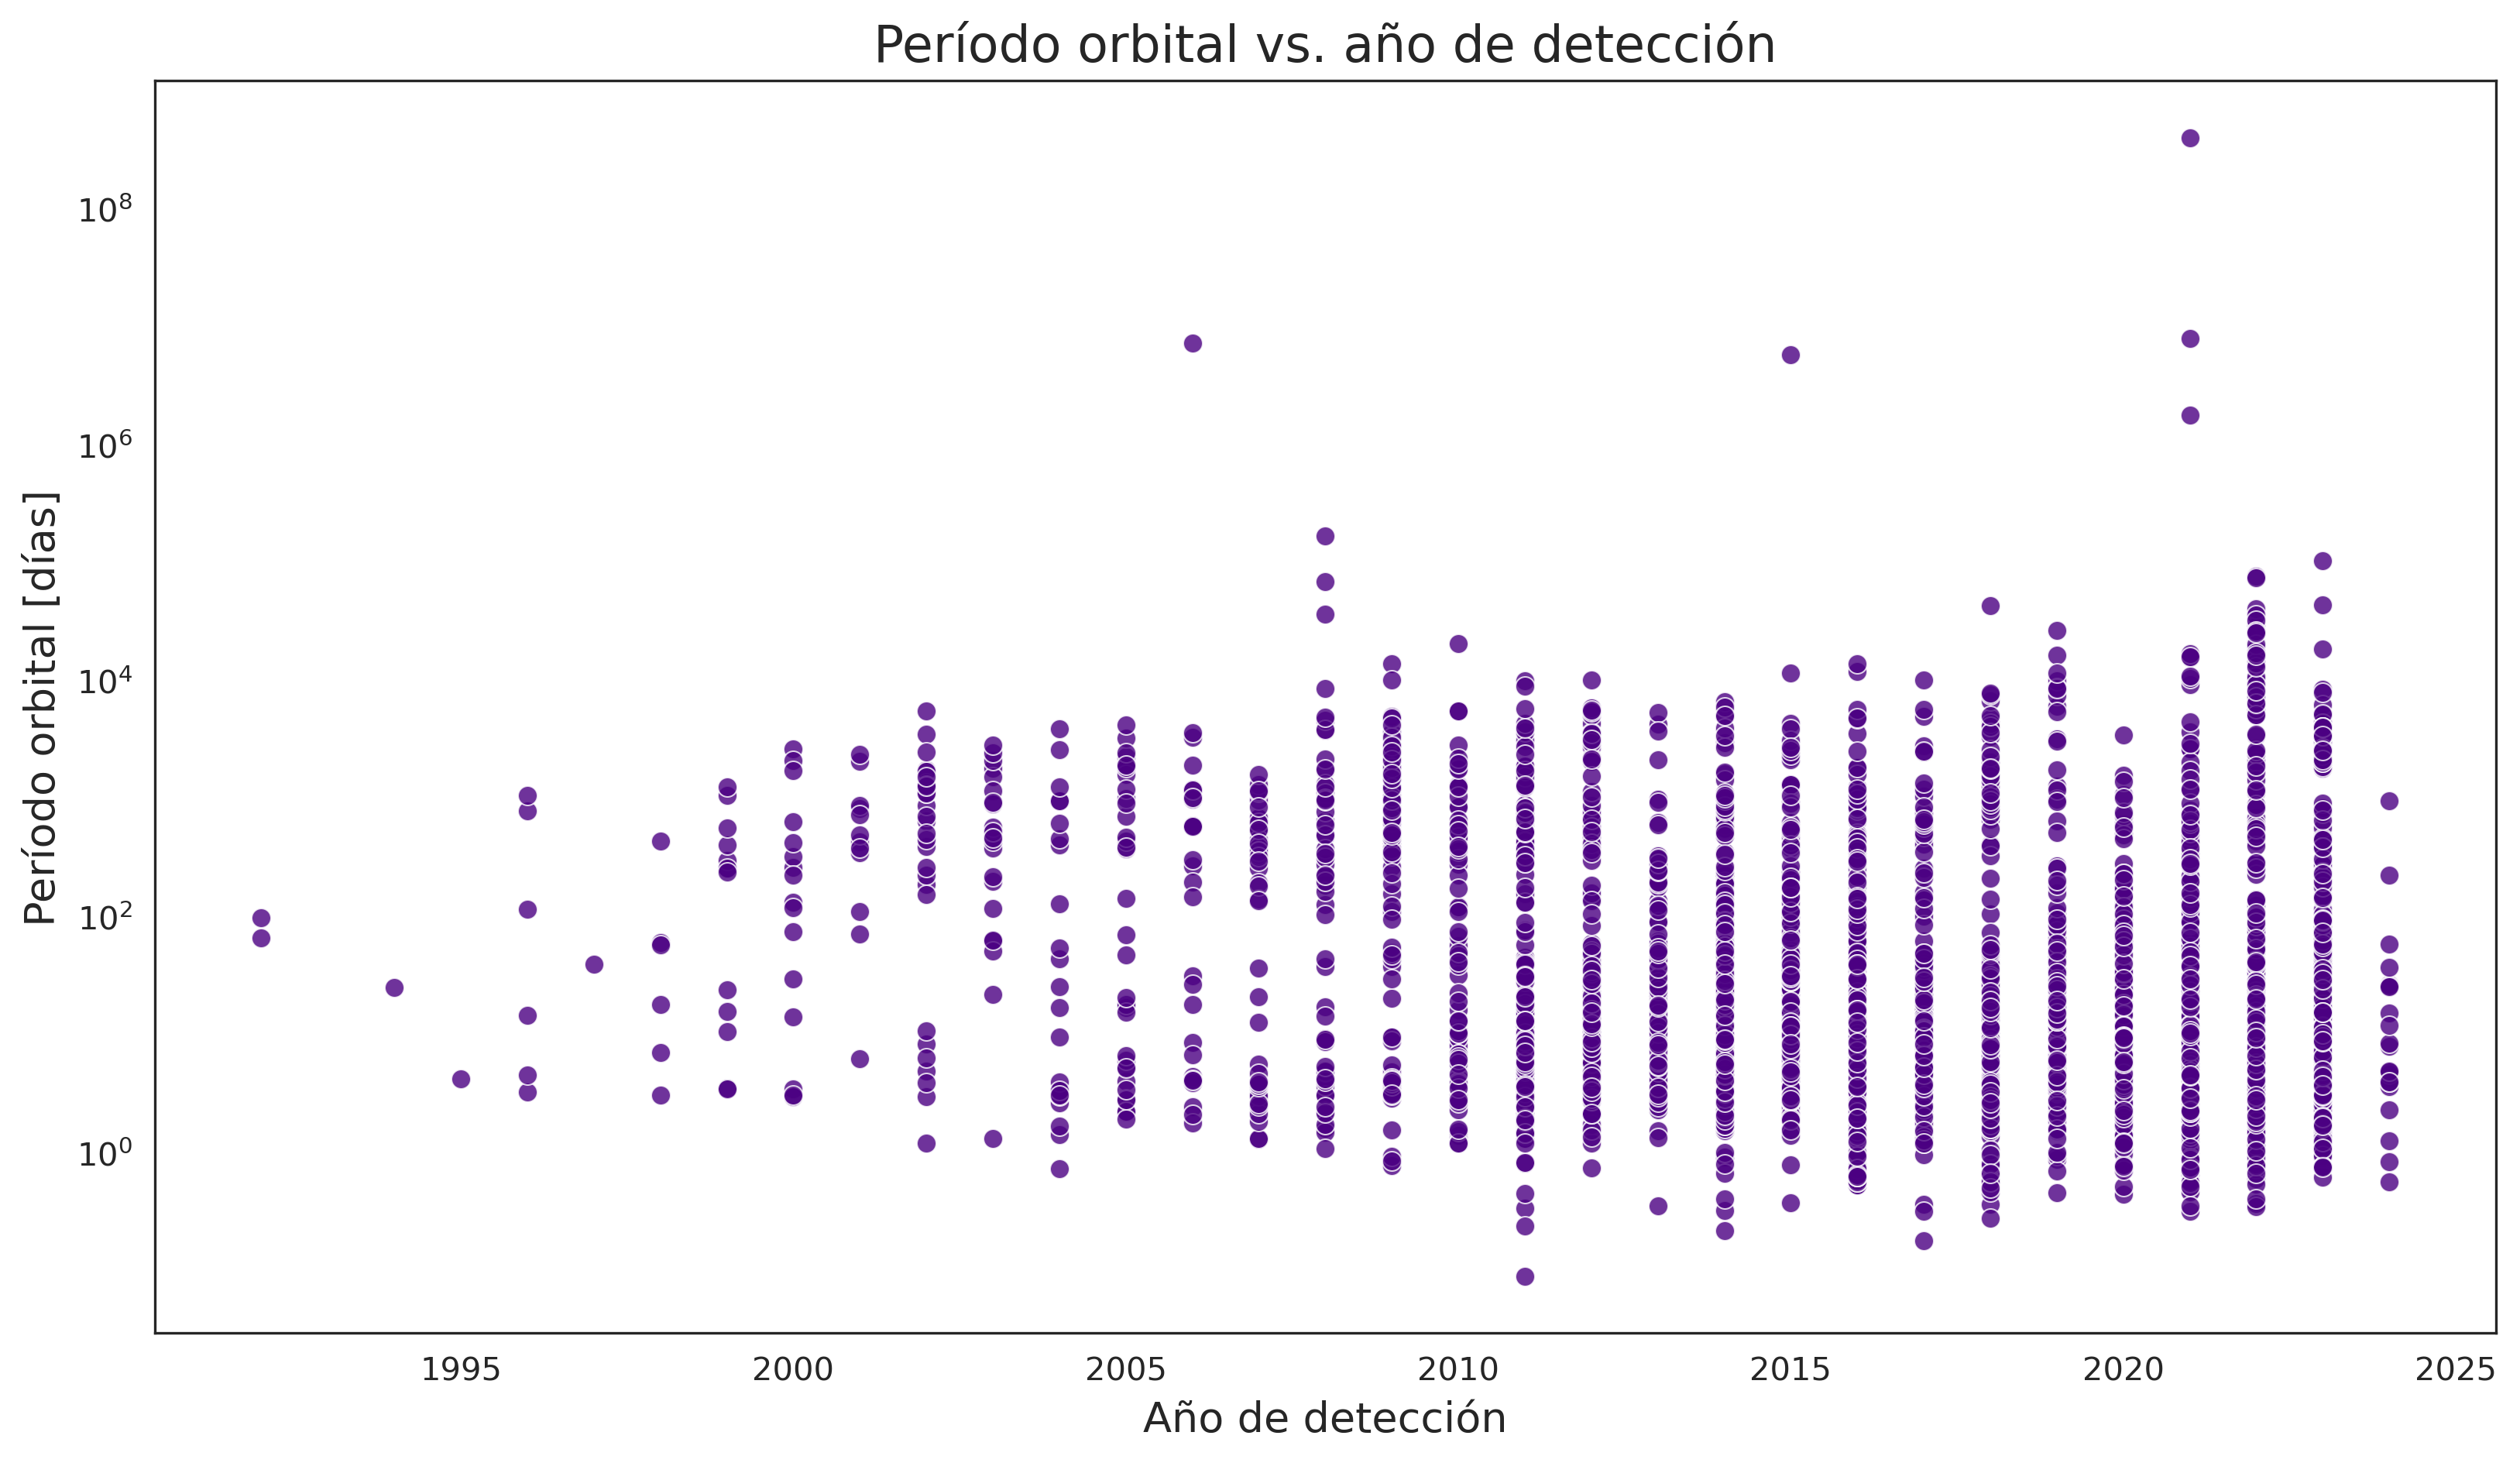

In [27]:
plt.figure(figsize=(13,7))

sns.scatterplot(data=EXO_set,x="P_YEAR",y="P_PERIOD",alpha=0.8,color="indigo")
plt.yscale("log")
plt.xlabel("Año de detección")
plt.ylabel("Período orbital [días]")
#plt.xlim(2004,2024)
plt.title("Período orbital vs. año de detección")
plt.show()

4. Boxplot para ver cómo se distribuyen las masas según el método de detección.

- ¿La distribución para los métodos de detección son simétricas? Los boxplots no son simétricos para los distintos métodos de detección, se ven valores atípicos, también amplias distribuciones.
  
- ¿Existen valores muy lejos de la distribución? Sí, se ven valores atípicos, por ello luego para poder observar mejor se hacen por separado boxplot para los 3 métodos de detección más comunes, como visto en la gráfica de exoplanetas por detección en gráfico bar (Transit, Radial Velocity, microlensing). Especialmente para el método de detección de tránsito, se tienen valores atípicos, mientras que para los dos últimos no.

- ¿Qué podría significar esto? Puede ser que el método de detección sea o muy apto o completo (por ejemplo para transit) que detecta con mucha precisión a los exoplanetas, pero también puede existir que la detección no sea del 100% segura, como sucede a veces en Astronomía, donde las observaciones son tentativas y se tienen que corroborar. Por ejemplo, en casos contrarios donde ni se ven valores atípicos, quizás esos métodos no son tan buenos o tan exactos como para detectar una variedad de exoplanetas con respecto a sus radios. El imaging quizás es mejor para exoplanetas con radios terrestres desde 10 a 100 Radios terrestres, mientras para tránsitos se abarcan bastantes radios hasta con detecciones (diriamos asi) atípicas o extremas (entonces se detectaron muy bien o "sobredetectaron").


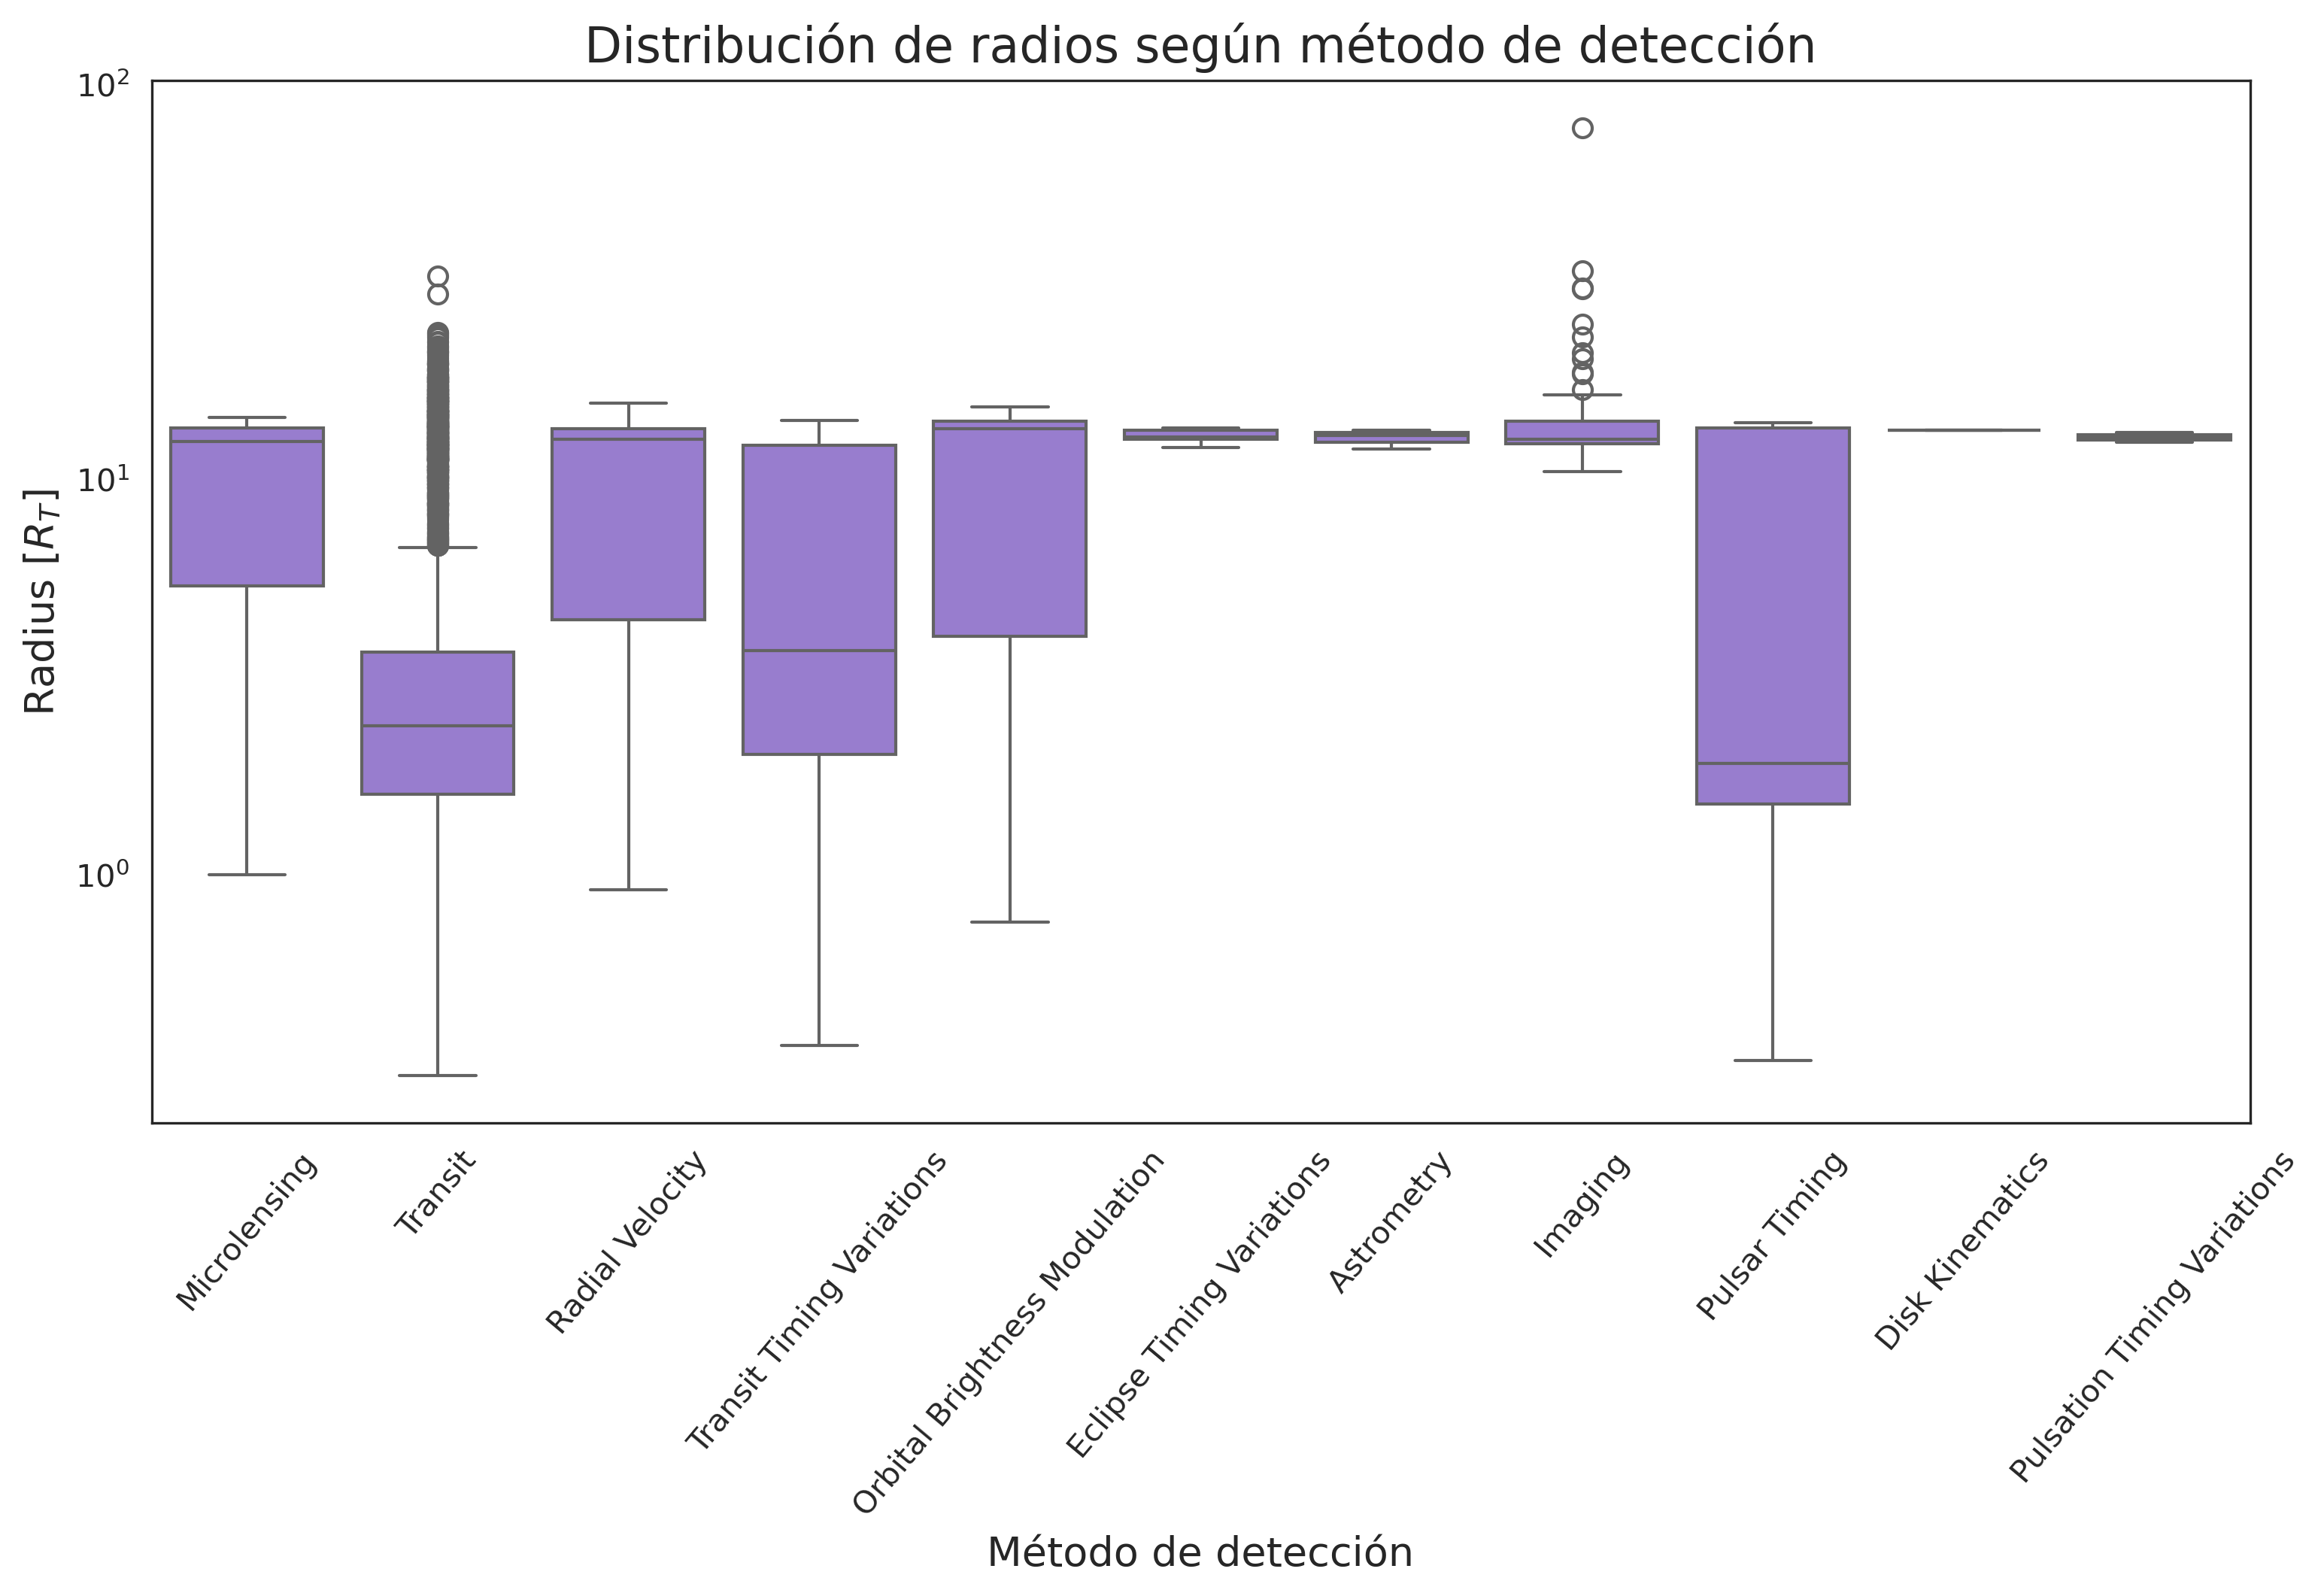

In [28]:
plt.figure(figsize=(12,6))
sns.boxplot(data=EXO_set,x="P_DETECTION",y="P_RADIUS",color="mediumpurple")
plt.xlabel("Método de detección")
plt.ylabel(r"Radius [$R_T$]")
plt.title("Distribución de radios según método de detección")
plt.xticks(rotation=50)
plt.yscale("log")
plt.show()

Por ejemplo, para los 3 tipos de detecciones donde más exoplanetas fueron detectados y también donde hay más valores atípicos.

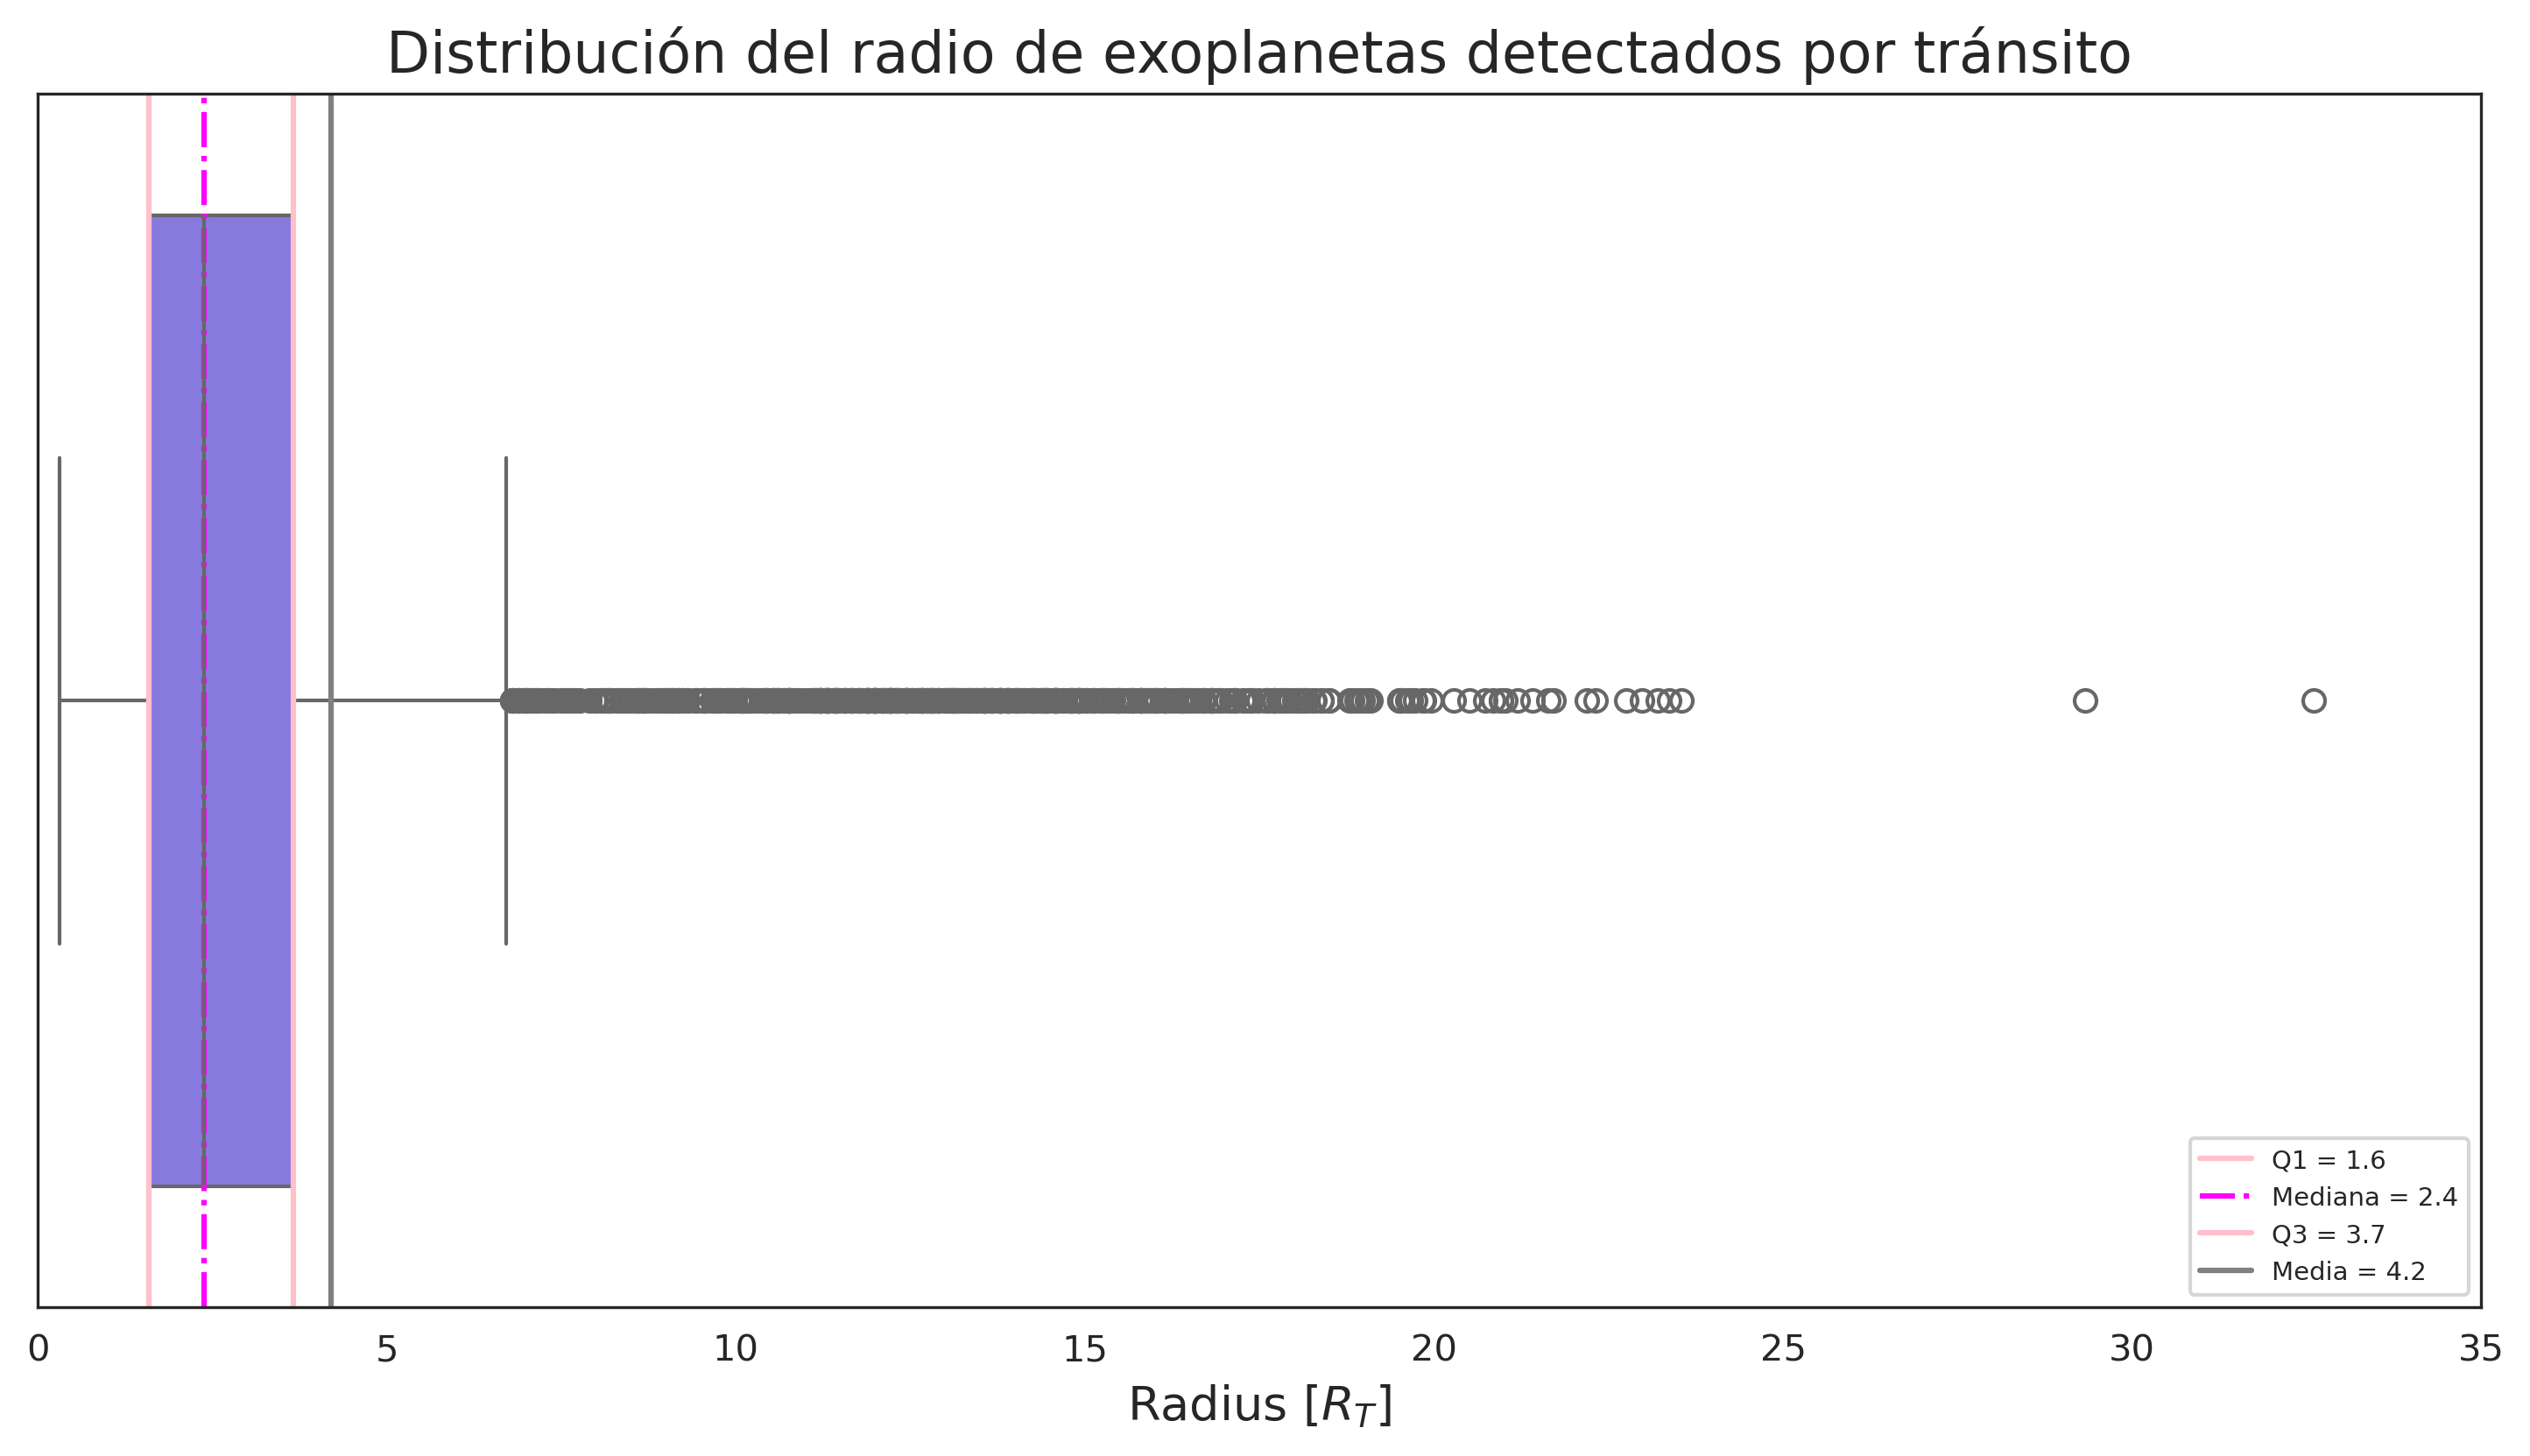

4.199891262602017 2.38 1.59625 3.6575


In [29]:
metodo_t = EXO_set[EXO_set["P_DETECTION"] == "Transit"]

plt.figure(figsize=(12, 6))
sns.boxplot(data=metodo_t,x="P_RADIUS",color="mediumslateblue")
plt.xlabel(r"Radius [$R_T$]")
plt.title("Distribución del radio de exoplanetas detectados por tránsito")
median = metodo_t["P_RADIUS"].median()
Q1 = metodo_t["P_RADIUS"].quantile(0.25)
Q3 = metodo_t["P_RADIUS"].quantile(0.75)
mean = metodo_t["P_RADIUS"].mean()
plt.axvline(Q1, color="pink", linestyle="-", label=f"Q1 = {Q1:.1f}")
plt.axvline(median, color="fuchsia", linestyle="-.", label=f"Mediana = {median:.1f}")
plt.axvline(Q3, color="pink", linestyle="-", label=f"Q3 = {Q3:.1f}")
plt.axvline(mean, color="grey", linestyle="-", label=f"Media = {mean:.1f}")
#plt.xscale("log")
plt.xlim(0,35)
plt.legend(fontsize=7,loc="lower right")
plt.show()
print(mean, median,Q1,Q3)

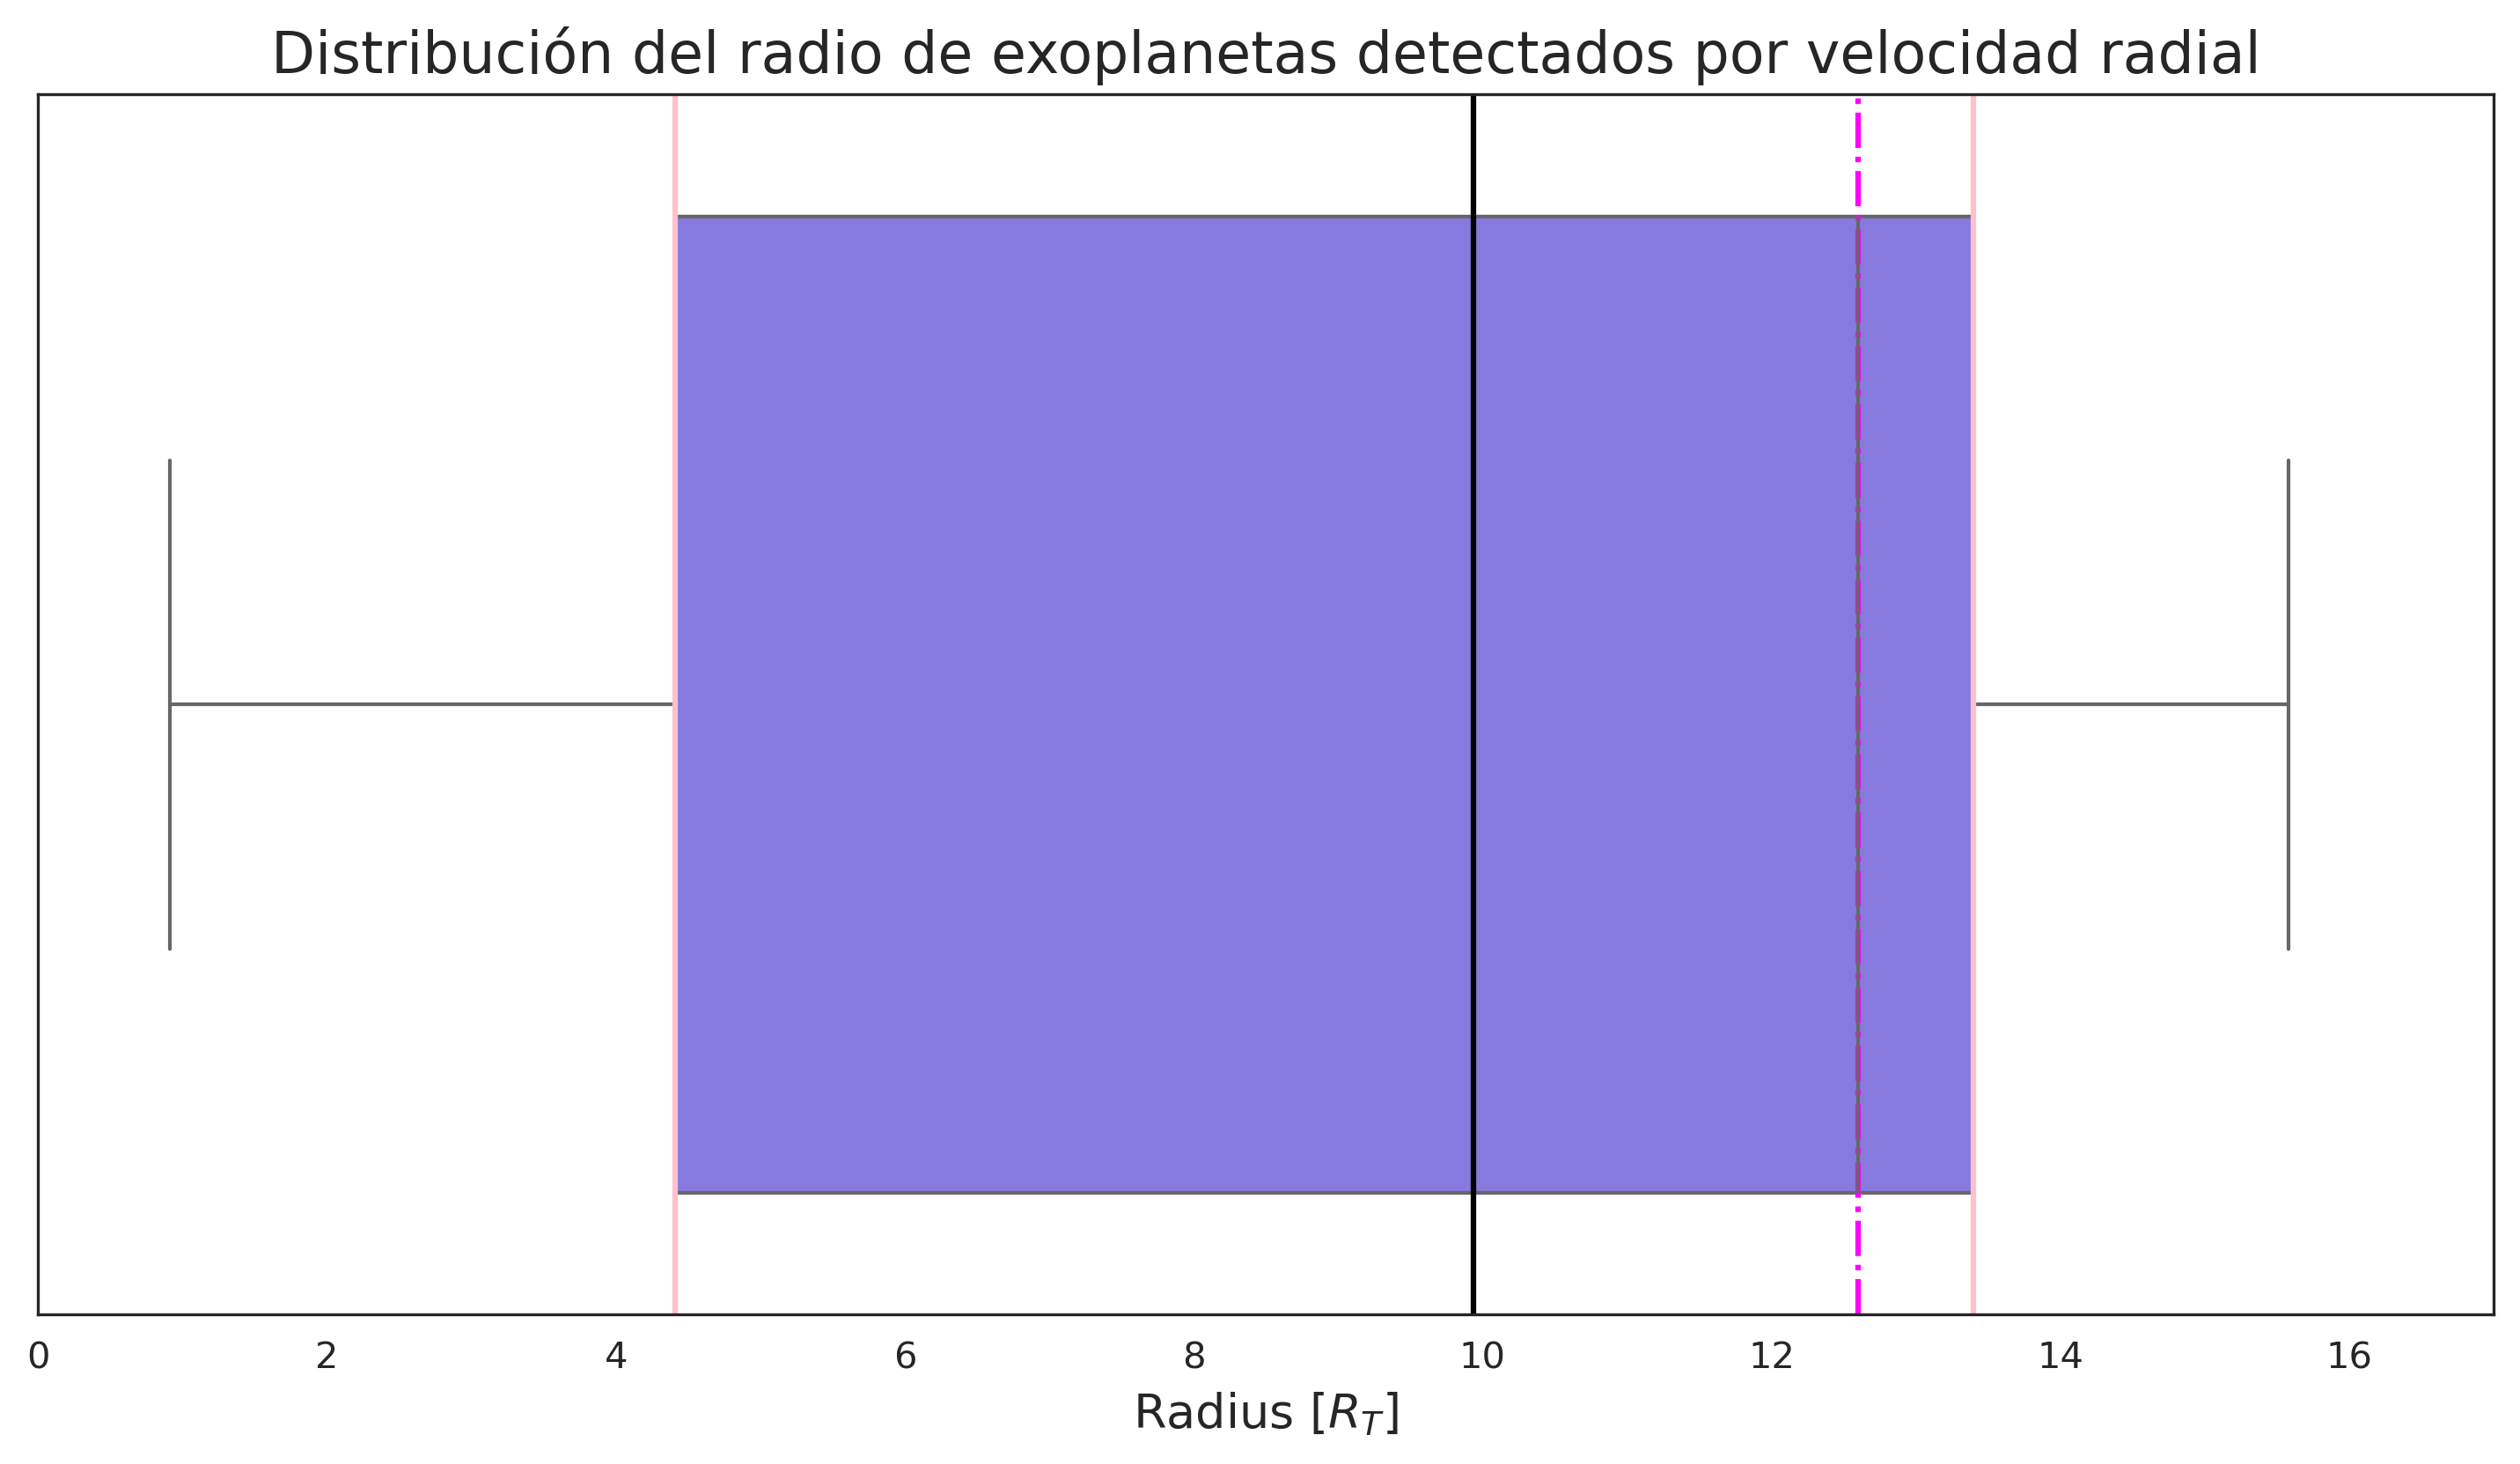

9.935205244935542 12.6 4.4125 13.4


In [30]:
metodo_r = EXO_set[EXO_set["P_DETECTION"] == "Radial Velocity"]

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=metodo_r,
    x="P_RADIUS",
    color="mediumslateblue"
)
median = metodo_r["P_RADIUS"].median()
Q1 = metodo_r["P_RADIUS"].quantile(0.25)
Q3 = metodo_r["P_RADIUS"].quantile(0.75)
mean = metodo_r["P_RADIUS"].mean()
plt.axvline(Q1, color="pink", linestyle="-", label=f"Q1 = {Q1:.1f}")
plt.axvline(median, color="fuchsia", linestyle="-.", label=f"Mediana = {median:.1f}")
plt.axvline(Q3, color="pink", linestyle="-", label=f"Q3 = {Q3:.1f}")
plt.axvline(mean, color="black", linestyle="-", label=f"Media = {mean:.1f}")
plt.xlabel(r"Radius [$R_T$]")
plt.title("Distribución del radio de exoplanetas detectados por velocidad radial")
plt.xlim(0,17)
plt.show()
print(mean, median,Q1,Q3)

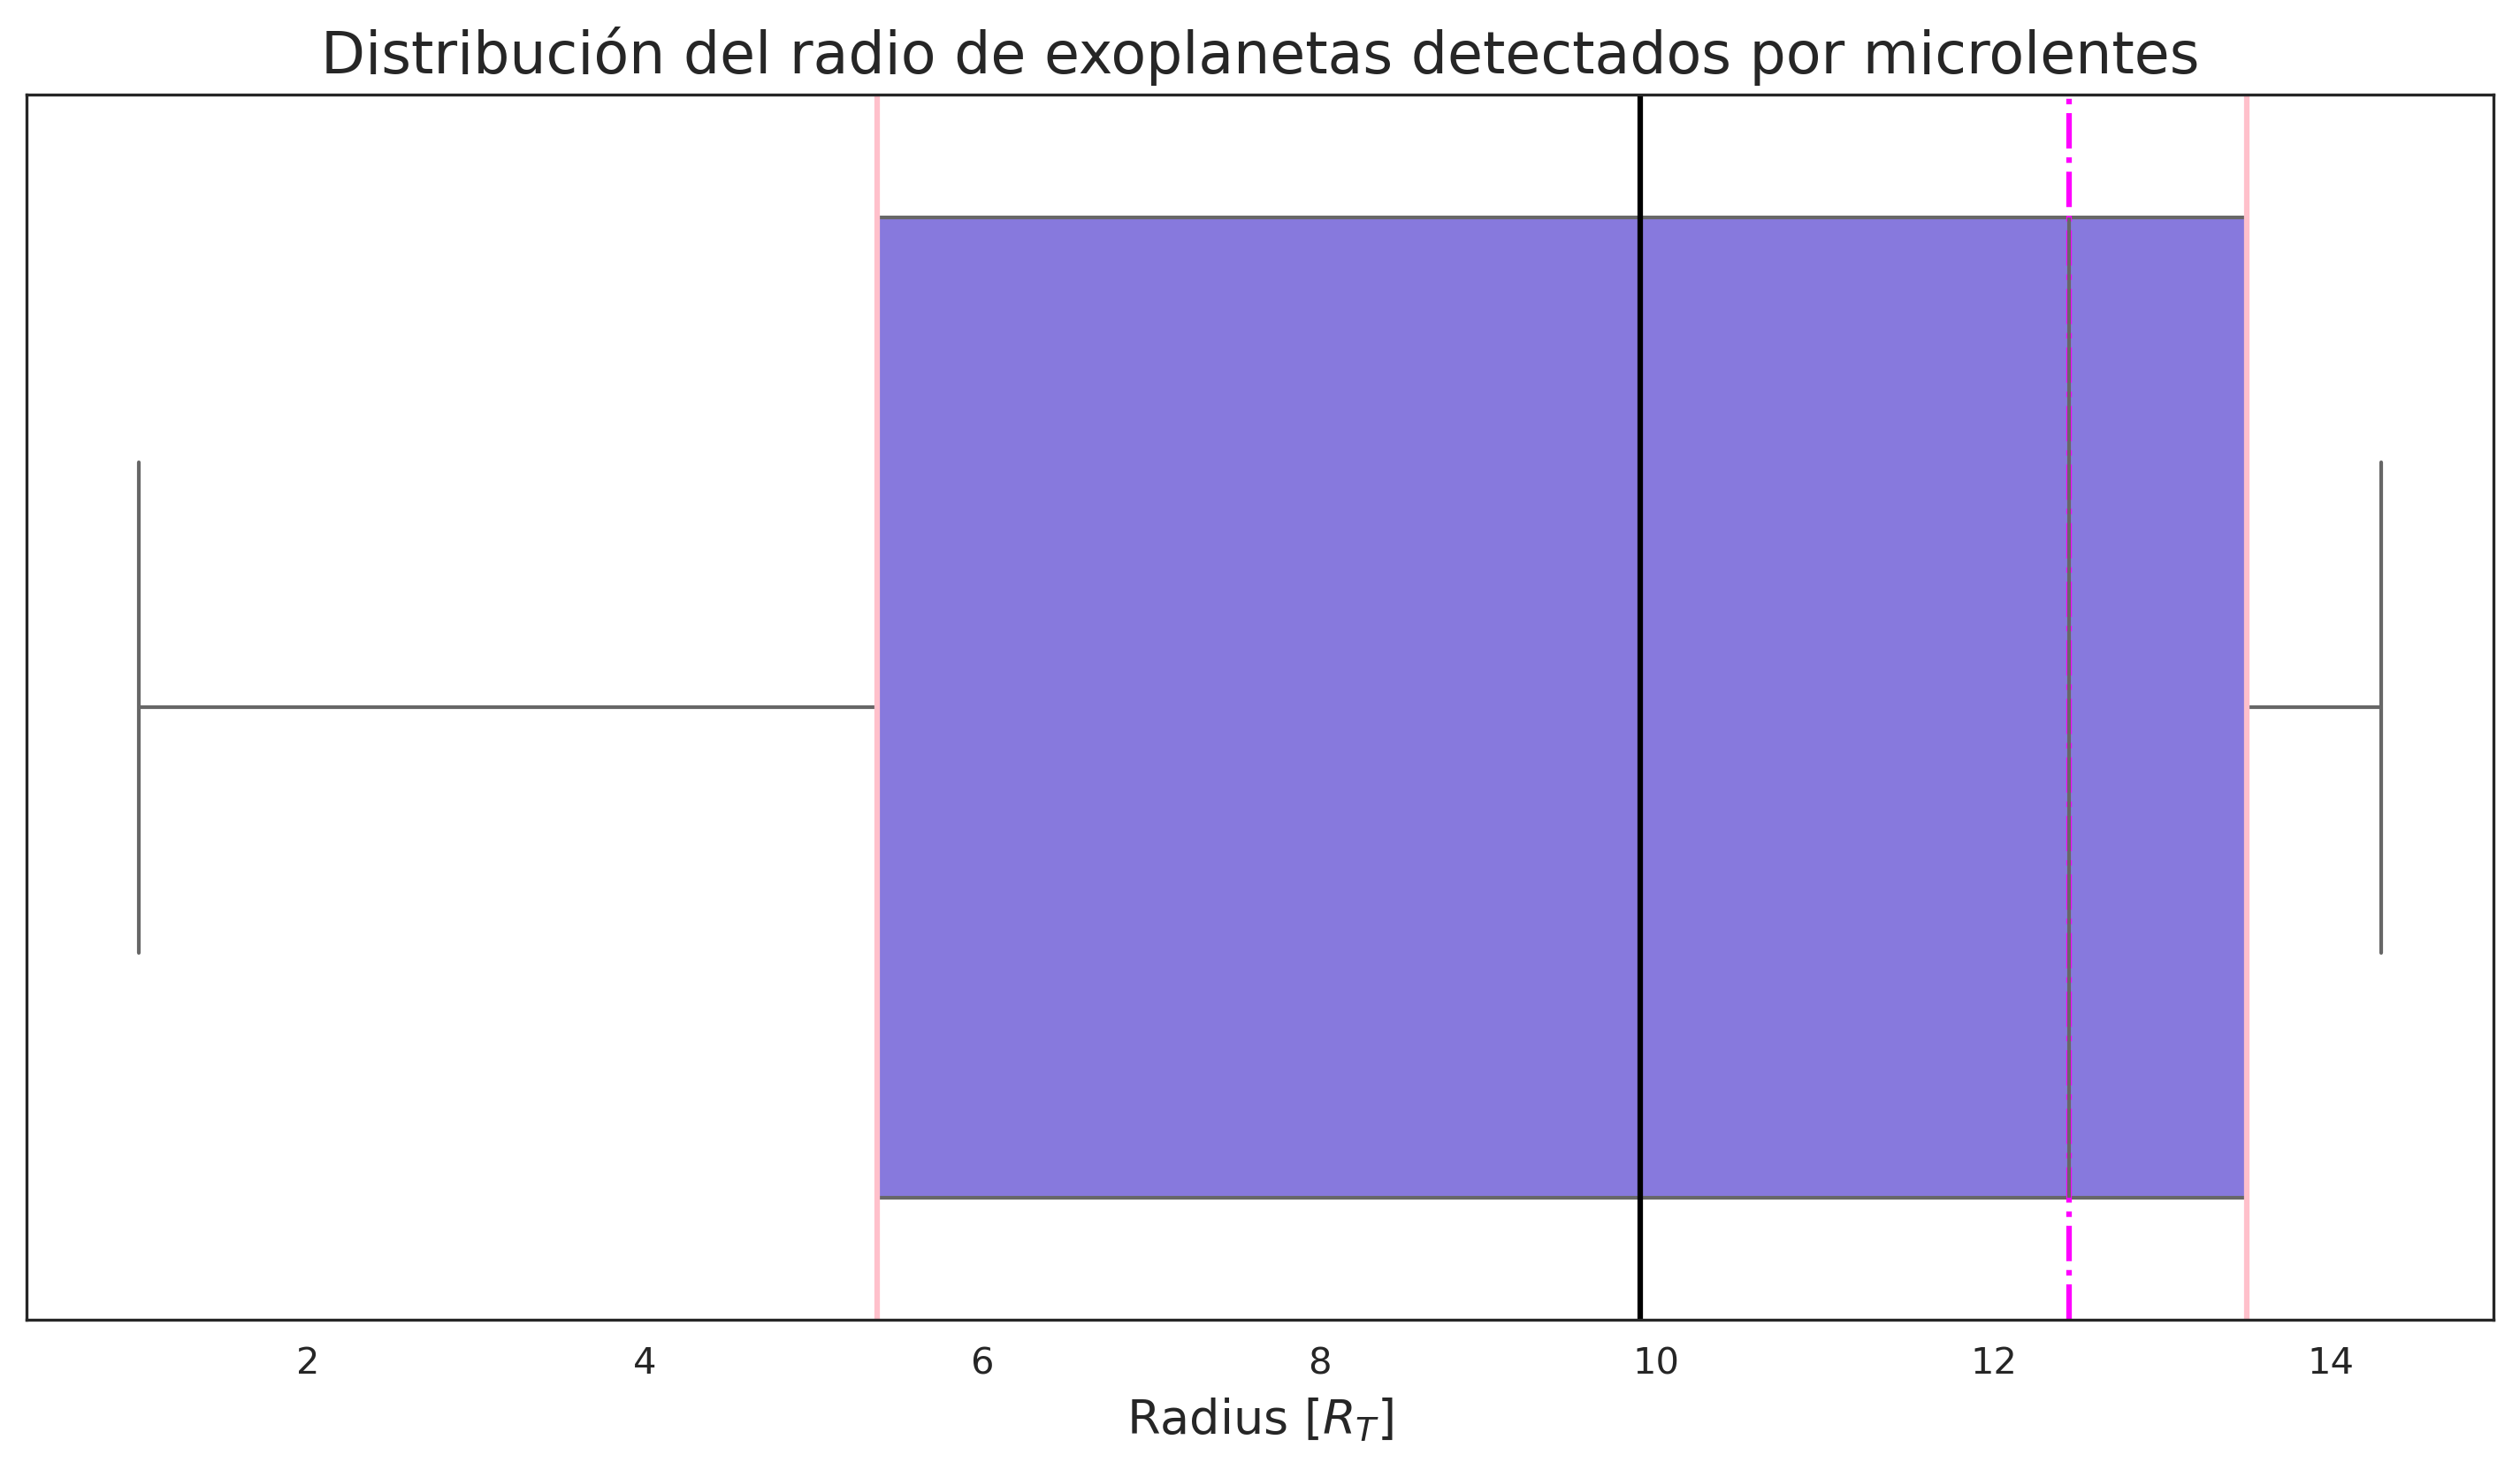

9.9027 12.45 5.38 13.5


In [31]:
metodo_m = EXO_set[EXO_set["P_DETECTION"] == "Microlensing"]

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=metodo_m,
    x="P_RADIUS",
    color="mediumslateblue"
)
median = metodo_m["P_RADIUS"].median()
Q1 = metodo_m["P_RADIUS"].quantile(0.25)
Q3 = metodo_m["P_RADIUS"].quantile(0.75)
mean = metodo_m["P_RADIUS"].mean()
plt.axvline(Q1, color="pink", linestyle="-", label=f"Q1 = {Q1:.1f}")
plt.axvline(median, color="fuchsia", linestyle="-.", label=f"Mediana = {median:.1f}")
plt.axvline(Q3, color="pink", linestyle="-", label=f"Q3 = {Q3:.1f}")
plt.axvline(mean, color="black", linestyle="-", label=f"Media = {mean:.1f}")
plt.xlabel(r"Radius [$R_T$]")
plt.title("Distribución del radio de exoplanetas detectados por microlentes")
plt.show()
print(mean, median,Q1,Q3)

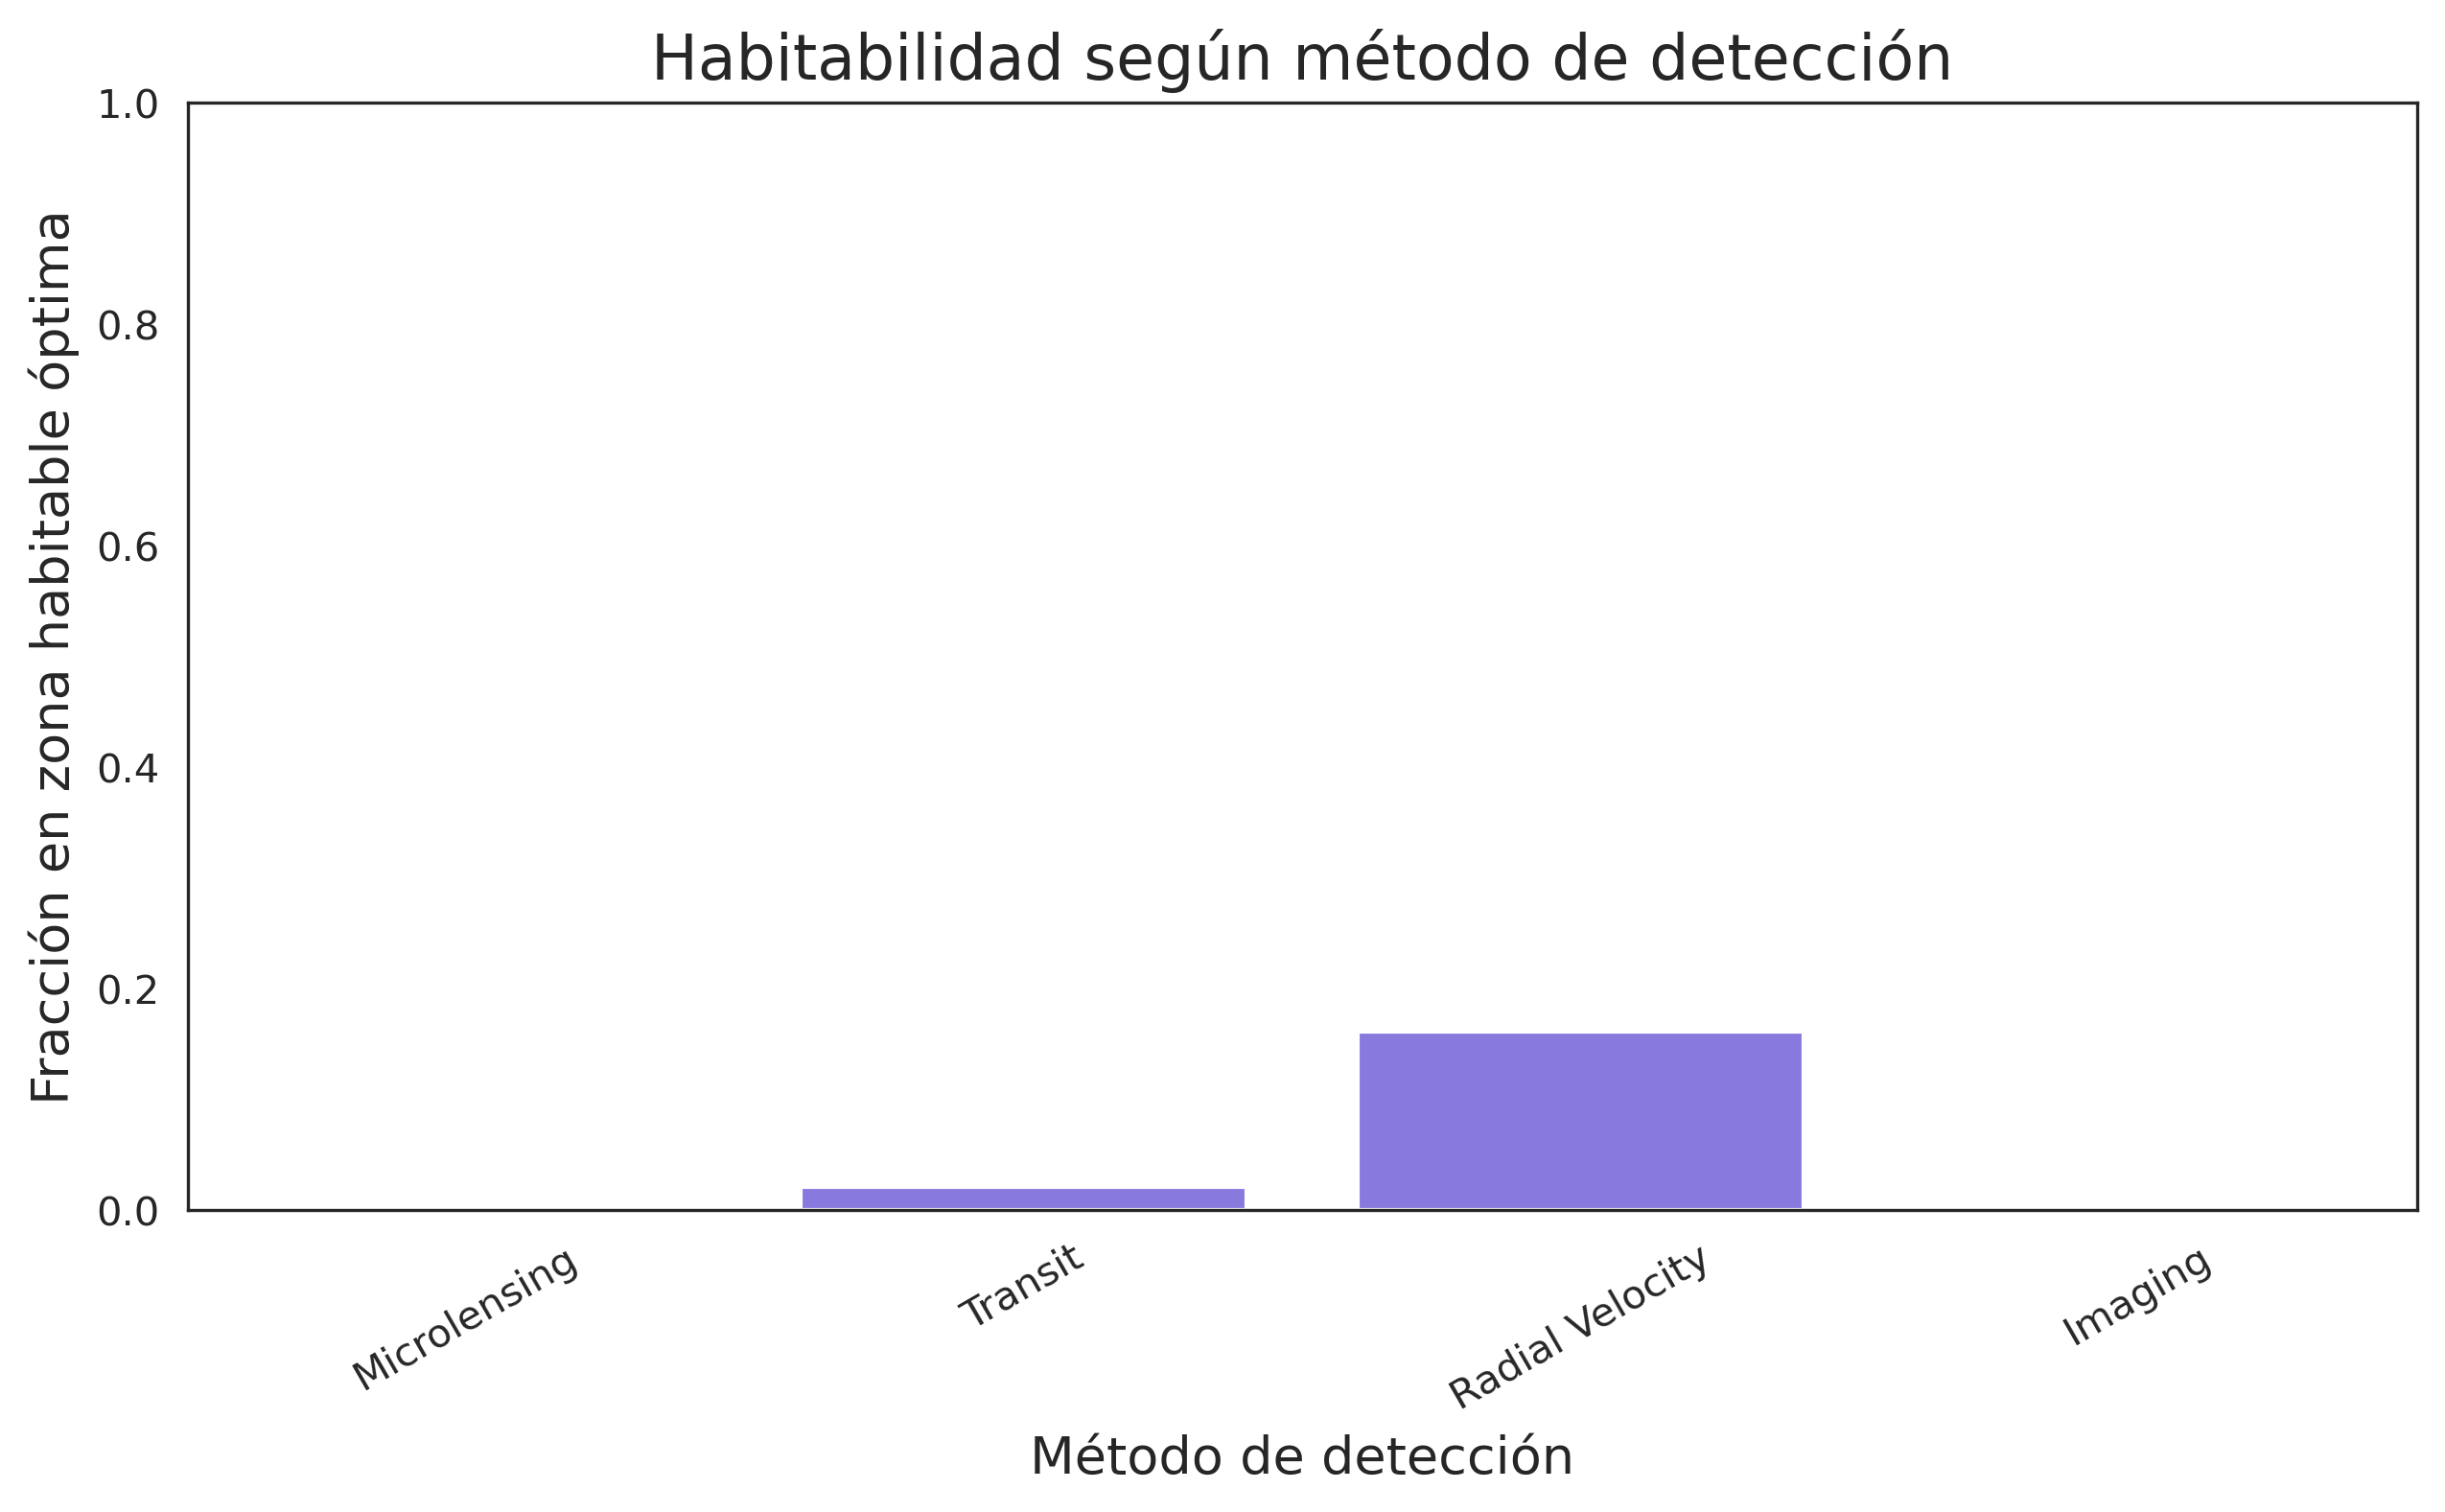

Transit: n = 4166
Radial Velocity: n = 1087
Microlensing: n = 210
Imaging: n = 68


In [32]:
conteo_deteccion = EXO_set["P_DETECTION"].value_counts()
metodos_principales = conteo_deteccion[conteo_deteccion > 30].index  # se filtran métodos con muestra muy chica

plt.figure(figsize=(10,5))
sns.barplot(data=EXO_set[EXO_set["P_DETECTION"].isin(metodos_principales)],
            x="P_DETECTION", y="P_HABZONE_OPT", color="mediumslateblue", errorbar=None)
plt.xlabel("Método de detección")
plt.ylabel("Fracción en zona habitable óptima")
plt.title("Habitabilidad según método de detección")
plt.xticks(rotation=30)
plt.ylim(0,1)
plt.show()

for m in metodos_principales:
    n = (EXO_set["P_DETECTION"] == m).sum()
    print(f"{m}: n = {n}")

¿La fracción de habitabilidad depende del método de detección? Sí, claramente depende. Radial Velocity muestra una fracción bastante mayor que Transit, que está cerca de 0%, a pesar de que Transit tiene casi 4 veces más exoplanetas detectados (n=4166 vs n=1087). Microlensing e Imaging no muestran fracción apreciable en zona habitable óptima.
Esto es evidencia directa de sesgo observacional: cada método detecta preferentemente cierto tipo de planeta (ej. Transit favorece planetas cercanos a su estrella, con períodos cortos y altas temperaturas, lo que reduce su probabilidad de estar en zona habitable), lo que afecta qué exoplanetas "parecen" habitables solo por ser detectables con ese método.

<h2 style="color:#BA55D3; font-family:; text-align:center;font-size:20px">
  Calidad de los datos
</h2>
¿Qué información falta y por qué podría importar?

Antes de interpretar cualquier patrón debemos revisar la calidad de los datos.

Nos interesa detectar:

- valores faltantes, puesto que como se había visto antes pueden haber pasajeros con categorías consideradas como NaN.
- características con mucha información incompleta
- valores extremos o sospechosos
- decisiones de limpieza que puedan cambiar nuestras conclusiones


In [33]:
datos_faltantes = EXO_set.isnull().sum() #valores que faltan en la tabla de exoplanetas
datos_faltantes

P_DETECTION               0
P_DISCOVERY_FACILITY      0
P_YEAR                    0
P_UPDATE                  0
P_MASS                    7
                       ... 
P_HABITABLE               0
P_ESI                   241
S_CONSTELLATION           0
S_CONSTELLATION_ABR       0
S_CONSTELLATION_ENG       0
Length: 117, dtype: int64

### Ejemplo de gráfico: valores faltantes

Podemos visualizar cuántos datos faltan en cada característica. De las 117 categorías, se van a analizar las de interés, como el periodo, la temperatura superficial, el radio del planeta, la caracteristica cualitativa de temperatura del exoplaneta, la masa, la distancia del exoplaneta a su Sol, el tipo de exoplaneta. (El focus para ver si re. Por ejemplo, se tiene que en los datos del período faltan un poco más de 200, en la temperatura superficial faltan casi 3160, mientras que en el radio del exoplaneta y para el tipo de exoplaneta faltan alrededor de 6 datos.


(El focus para ver si realmente los exoplanetas detectados/observados representan los exoplanetas que existen, se puede basar en lo de temperaturas, distancia al Sol respecto a clase de exoplaneta)

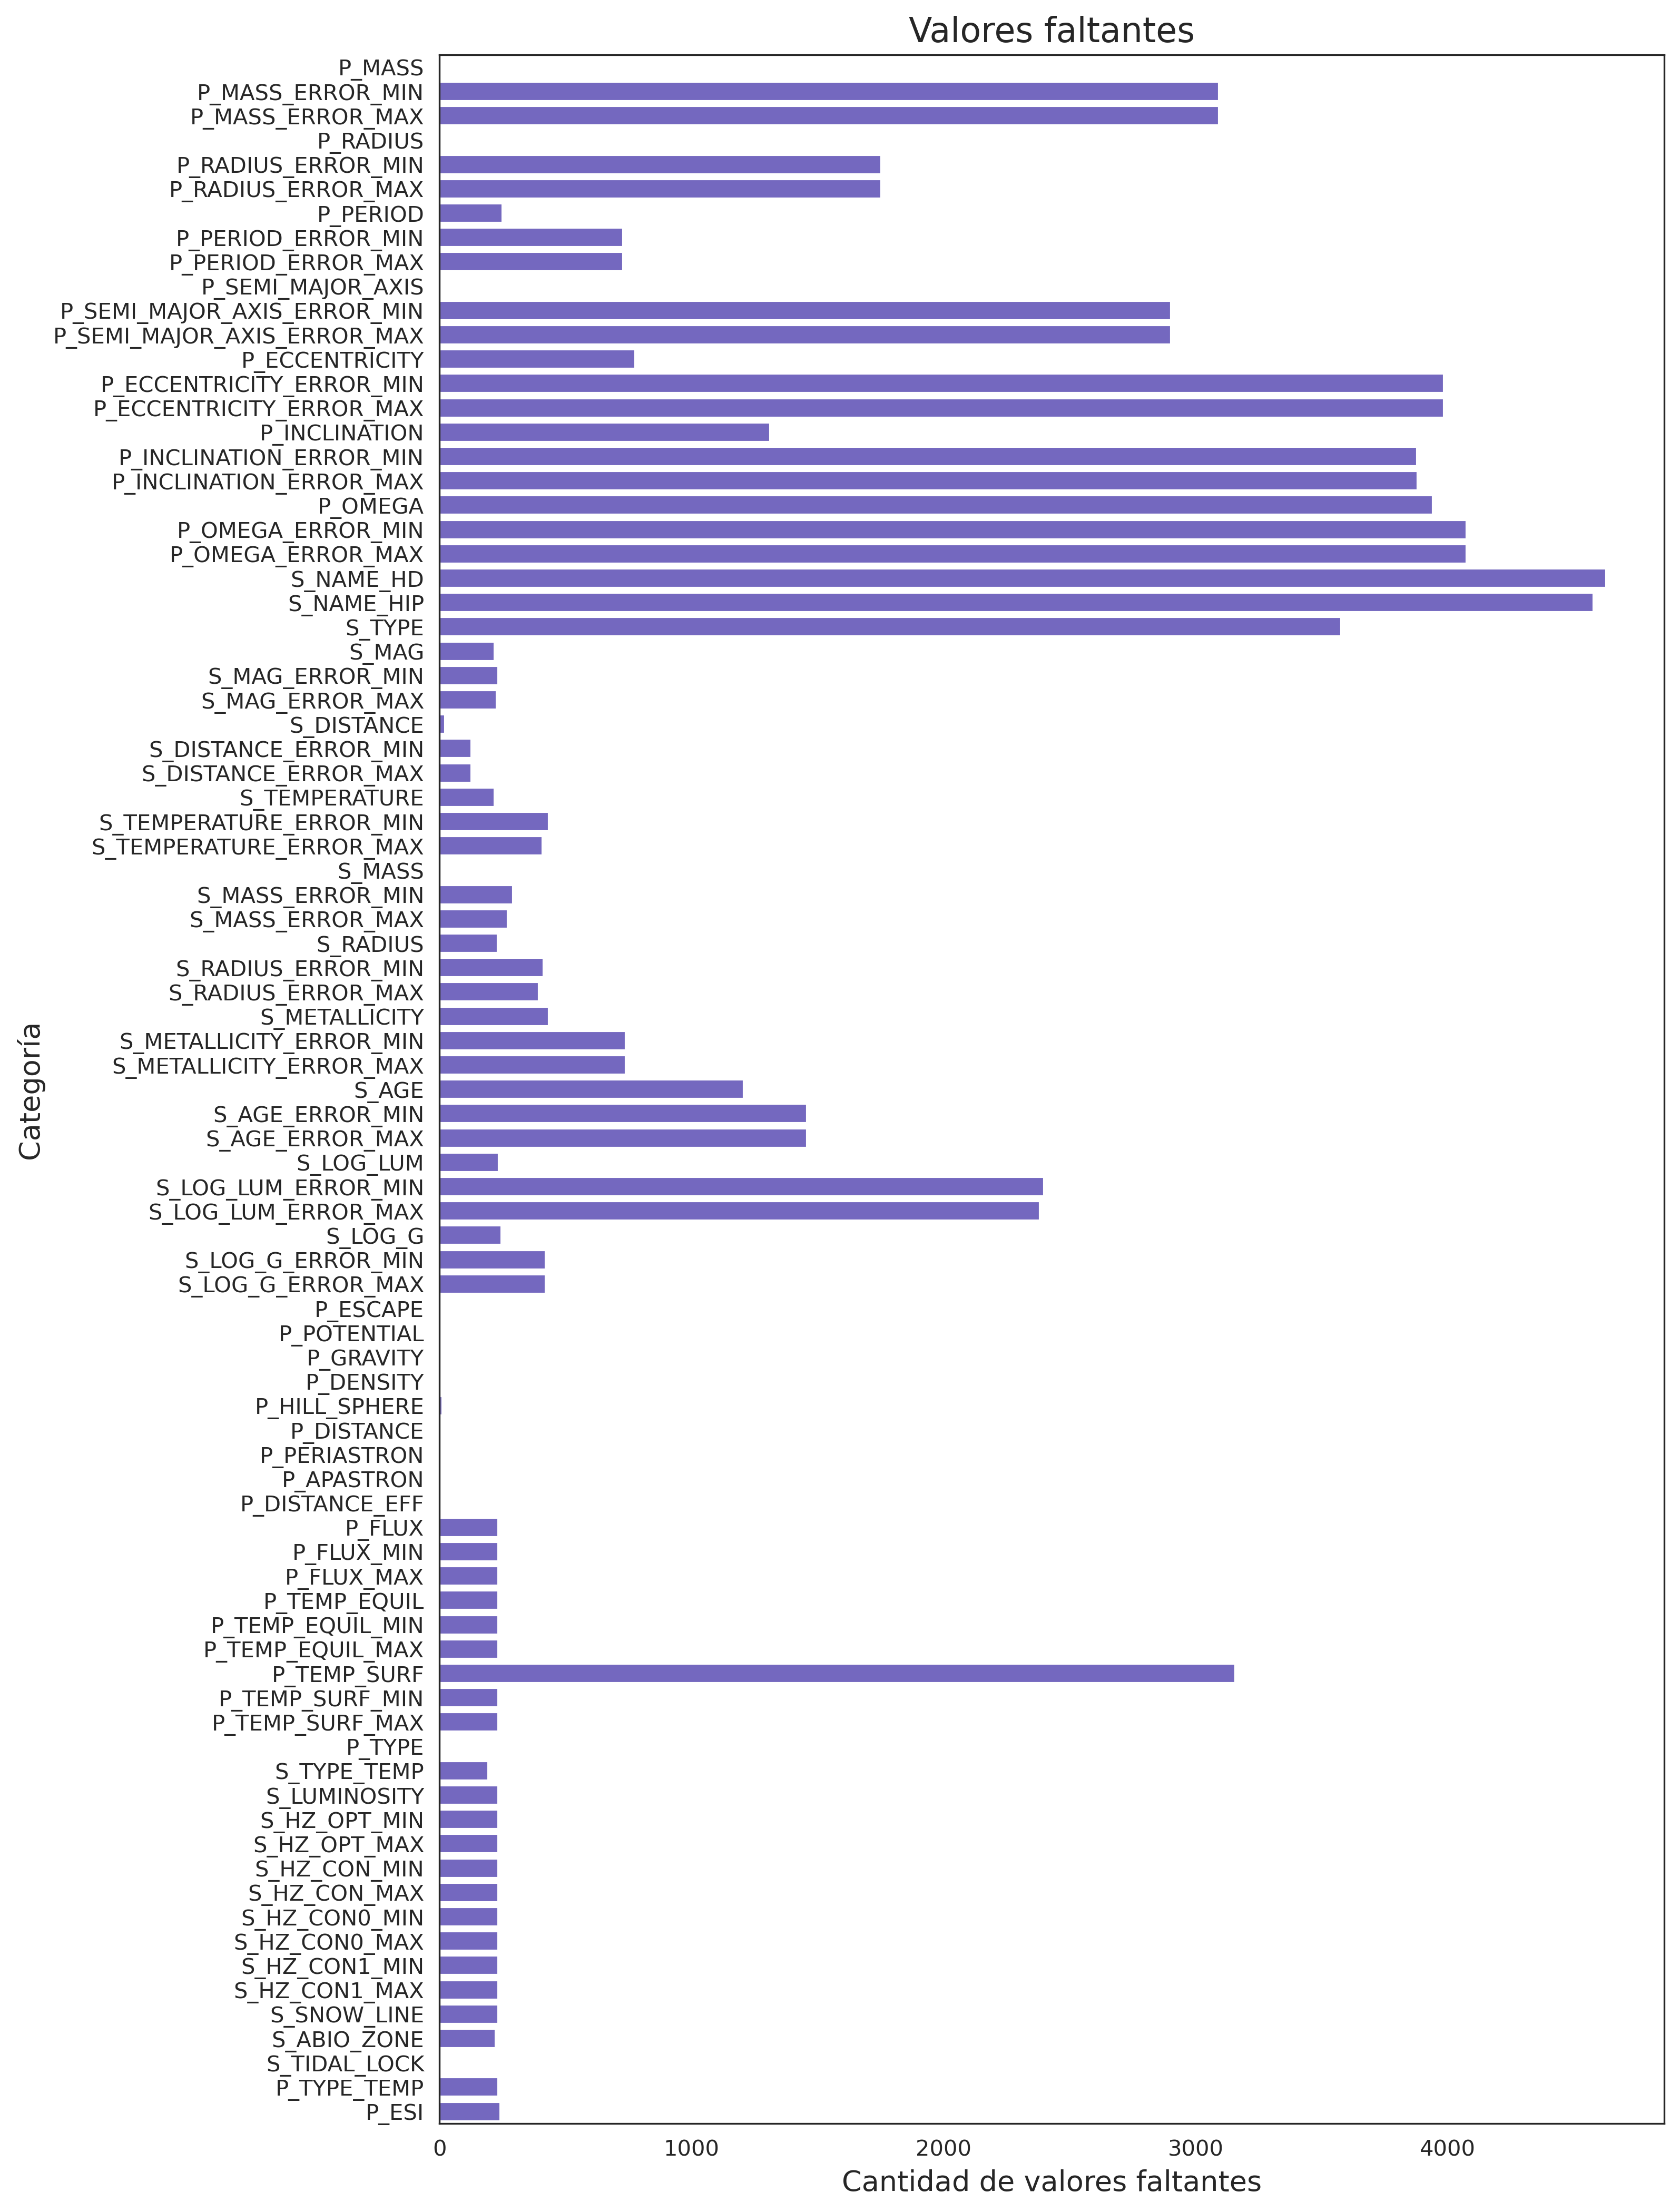

In [34]:
faltantes = datos_faltantes[datos_faltantes > 0]
plt.figure(figsize=(10,17))
sns.barplot(x=faltantes.values, y=faltantes.index, color='slateblue')
plt.xlabel("Cantidad de valores faltantes")
plt.ylabel("Categoría")
plt.title("Valores faltantes")
#plt.xlim(0,30)
plt.show()

Observando especialmente `P_PERIOD`, `P_MASS` y `P_TEMP_SURF`, `P_TYPE_TEMP`.

**1. Podemos comparar la media y la mediana de `P_PERIOD`, además de otras categorías respecto a los valores faltantes.**

- Son similares? No son similares, la mediana para el período de los exoplanetas es de 11.56 días mientras que la media es de 79940.81 días.
- Es la media una buena representación de un período típico? Depende de cómo definamos cuál es el período típico, esto en realidad es ambiguo.
- Como se tiene abajo hay valores faltantes para categorías de masa, periodo, type temp, y temperatura superficial. Estos son 7, 249, 234 y 3158 valores faltantes, respectivamente. Además se ven los porcentajes que son del total de data, puesto que sirve para analizar si es posible reemplazarlos por la median o mean debido a que la median es menos sensible a datos extremos y el mean resulta ser más sensible, o si es que es óptimo eliminarlos o no, etc.

In [35]:
period = int(datos_faltantes[datos_faltantes > 0]["P_PERIOD"])
mass = int(datos_faltantes[datos_faltantes > 0]["P_MASS"])
typee = int(datos_faltantes[datos_faltantes > 0]["P_TYPE_TEMP"])
temp = int(datos_faltantes[datos_faltantes > 0]["P_TEMP_SURF"])
#Mediana y media de mass, period, temp
print(np.median((EXO_set["P_PERIOD"]).dropna()),np.mean((EXO_set["P_PERIOD"]).dropna()))
print(np.median((EXO_set["P_MASS"]).dropna()),np.mean((EXO_set["P_MASS"]).dropna()))
print(np.median((EXO_set["P_TEMP_SURF"]).dropna()),np.mean((EXO_set["P_TEMP_SURF"]).dropna()))
#porcentajes faltantes respecto al total (5598 exoplanetas)
print("Valores de período faltantes corresponden a aprox. 4.45% del total")
print("Valores de masa faltantes corresponden a aprox. 0.13% del total")
print("Valores de type temp faltantes corresponden a aprox. 4.18% del total")
print("Valores de temperatura superficial faltantes corresponden a aprox. 56.41% del total")
#Datos faltantes 
period,mass,typee,temp

11.569511 79940.81961236008
8.75 442.52128253093707
908.70112 971.9940228635805
Valores de período faltantes corresponden a aprox. 4.45% del total
Valores de masa faltantes corresponden a aprox. 0.13% del total
Valores de type temp faltantes corresponden a aprox. 4.18% del total
Valores de temperatura superficial faltantes corresponden a aprox. 56.41% del total


(249, 7, 234, 3158)

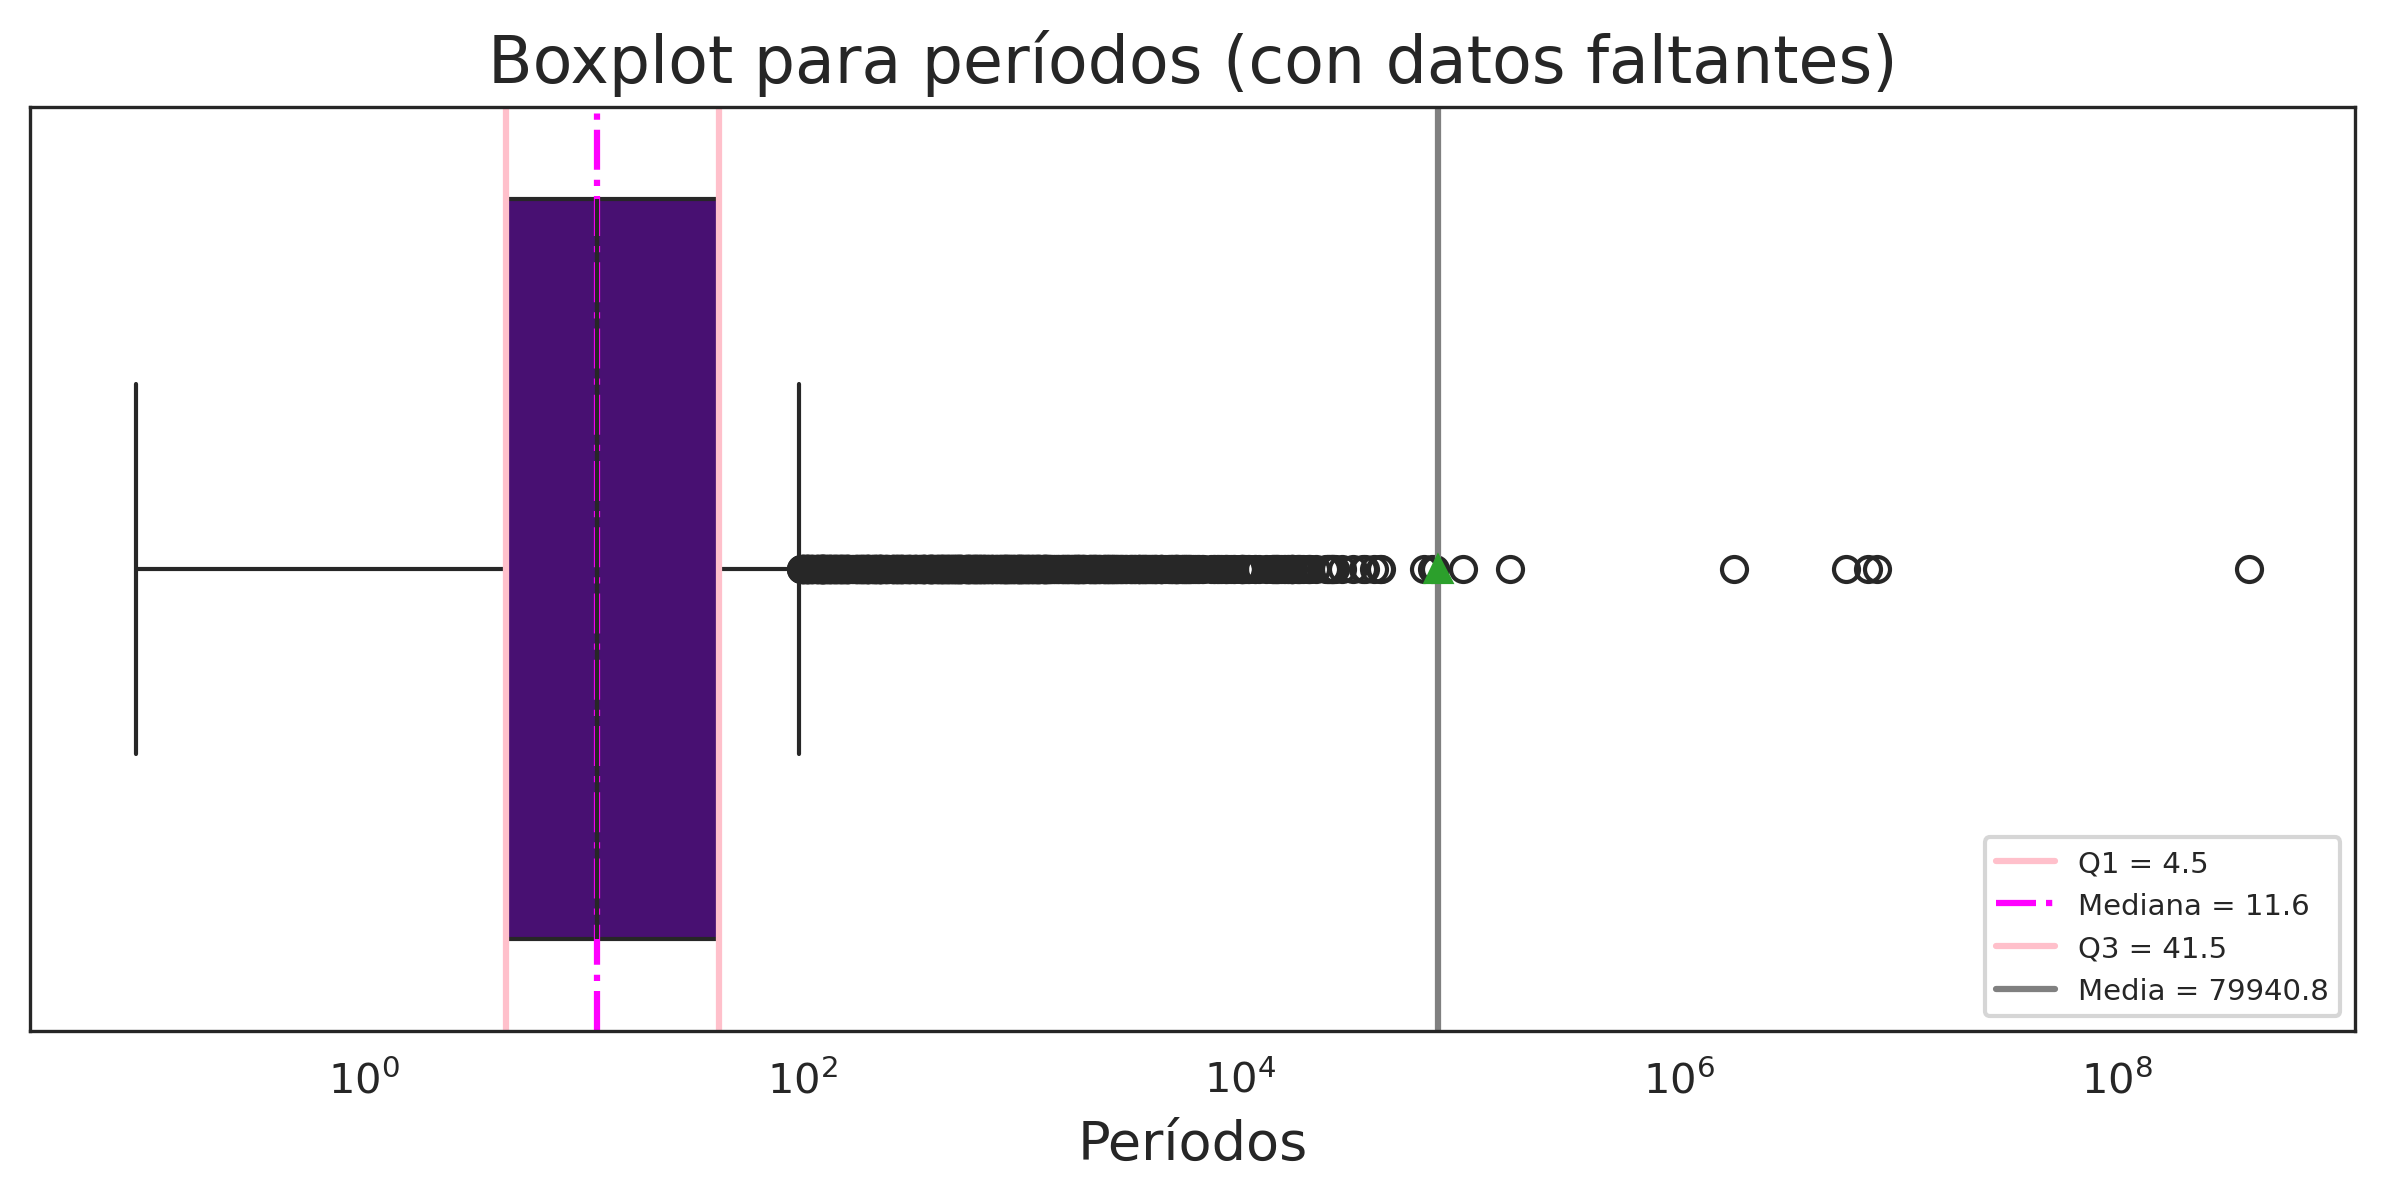

79940.81961236008 11.569511 4.4653823500000005 41.50555475


In [36]:
#boxplot para period
EXO_set = pd.read_csv("hwc.csv")
plt.figure(figsize=(10, 4))
sns.boxplot(data=EXO_set, x="P_PERIOD", color="indigo", showmeans=True)
#Para localizar cuartiles, media y mediana
median = EXO_set["P_PERIOD"].median()
mean = EXO_set["P_PERIOD"].mean()
Q1 = EXO_set["P_PERIOD"].quantile(0.25)
Q3 = EXO_set["P_PERIOD"].quantile(0.75)
mean = EXO_set["P_PERIOD"].mean()
plt.axvline(Q1, color="pink", linestyle="-", label=f"Q1 = {Q1:.1f}")
plt.axvline(median, color="fuchsia", linestyle="-.", label=f"Mediana = {median:.1f}")
plt.axvline(Q3, color="pink", linestyle="-", label=f"Q3 = {Q3:.1f}")
plt.axvline(mean, color="grey", linestyle="-", label=f"Media = {mean:.1f}")
plt.xlabel("Períodos")
plt.title("Boxplot para períodos (con datos faltantes)")
plt.legend(fontsize=7,loc="lower right")
plt.xscale("log")
plt.show()
print(mean, median,Q1,Q3)

**2. El periodo tiene datos faltantes.**

- Le parece razonable reemplazar todas las periodos faltantes por la media? Quizás si, porque si faltan alrededor de 200 datos comparado con la cantidad total de exoplanetas resultan ser alrededor del 3.5% del total de datos, pero de esta misma forma como el valor de la media es mucho mayor al de la mediana puede afectar, es decir, compensaría esa relativa poca cantidad de datos faltantes con tener un valor mayor.
- Qué problema podría producir esa decisión en la distribución de periodos? Quizás "regularse" en su distribución.
- Qué otra estrategia consideraría? La mediana, para que la muestra no se vea muy afectada y además de que la cantidad de 11.56 resulta razonable.


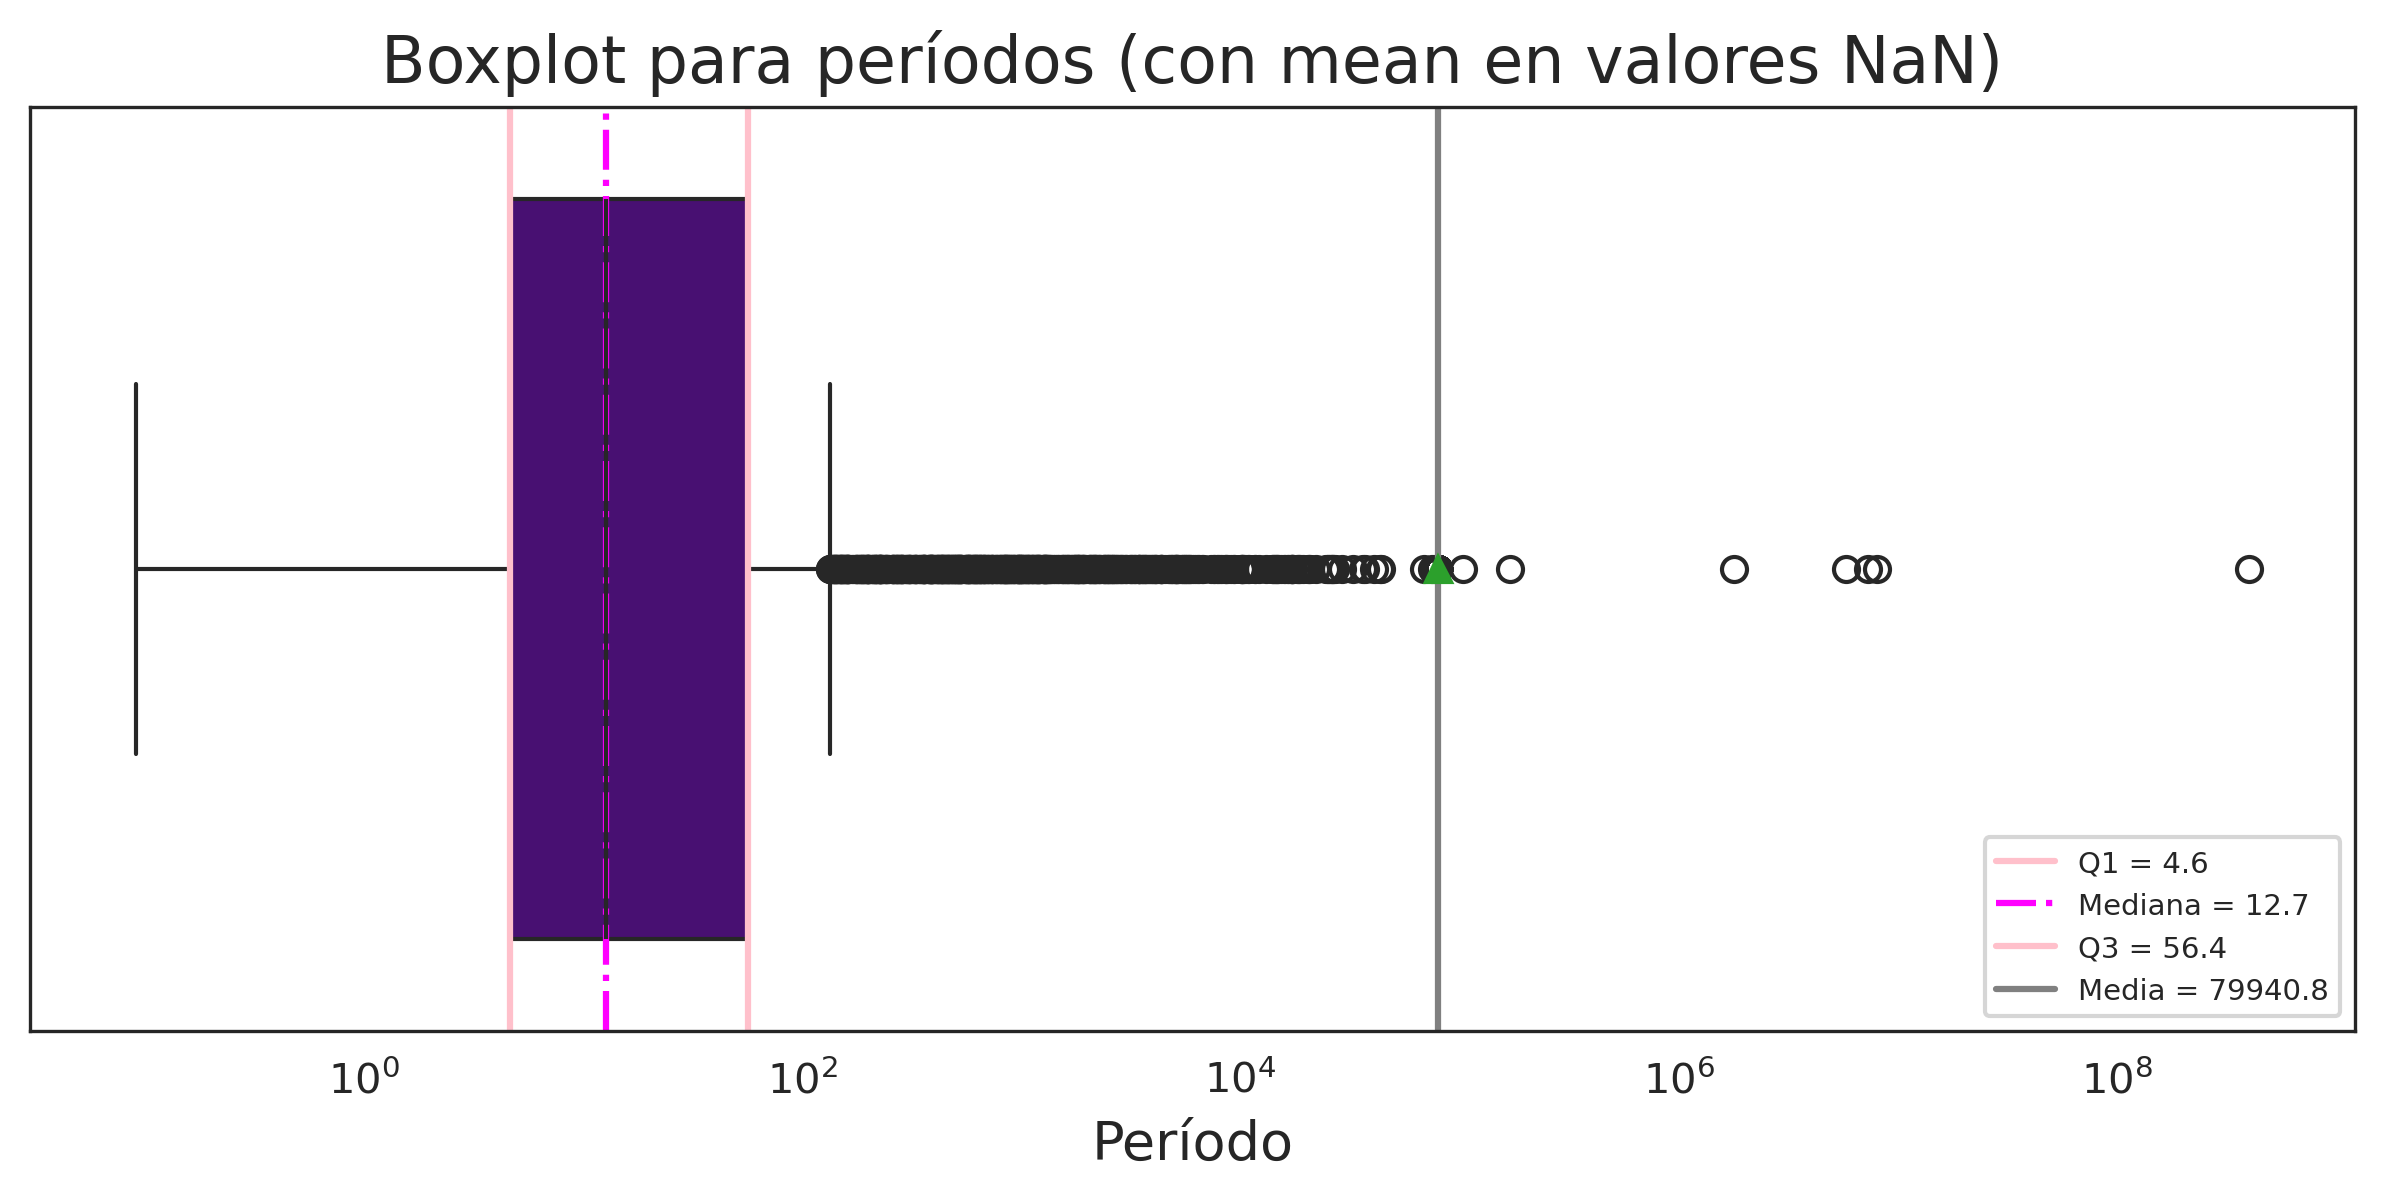

79940.8196123601 12.7372 4.63871 56.425447000000005


In [37]:
#Aquí escribo de nuevo la tabla del set de exoplanetas pero con nombre EXO_set2 para no confundir, para la tabla con datos rellenos para la edad
EXO_set2 = pd.read_csv("hwc.csv")
EXO_set2["P_PERIOD"] = EXO_set2["P_PERIOD"].fillna(mean) #agregando la media a los datos faltantes para el periodo
plt.figure(figsize=(10, 4))
sns.boxplot(data=EXO_set2, x="P_PERIOD", color="indigo", showmeans=True)
#Para localizar cuartiles, media y mediana
median = EXO_set2["P_PERIOD"].median()
Q1 = EXO_set2["P_PERIOD"].quantile(0.25)
Q3 = EXO_set2["P_PERIOD"].quantile(0.75)
mean = EXO_set2["P_PERIOD"].mean()
plt.axvline(Q1, color="pink", linestyle="-", label=f"Q1 = {Q1:.1f}")
plt.axvline(median, color="fuchsia", linestyle="-.", label=f"Mediana = {median:.1f}")
plt.axvline(Q3, color="pink", linestyle="-", label=f"Q3 = {Q3:.1f}")
plt.axvline(mean, color="grey", linestyle="-", label=f"Media = {mean:.1f}")
plt.xlabel("Período")
plt.title("Boxplot para períodos (con mean en valores NaN)")
plt.legend(fontsize=7,loc="lower right")
plt.xscale("log")
plt.show()
print(mean, median,Q1,Q3)

Como se puede ver en el boxplot realizado con periodos faltantes, los valores de promedio, mediana, Q1 y Q3 son aprox. 79941 días, 11.56 días, 4.46 días, 41.51 días. Mientras que para el boxplot en donde se reemplazo los NaN con el mean, son 79941 días, 12.73 días, 4.64 días, 56.43 días. Luego se puede decir que para la mediana impactó ese cambio, y también en el cuartil 3 (que agrupa alrededor del 75% de los datos).

**3. `P_TEMP_SURF` tiene una gran cantidad de valores faltantes.**

- Intentaría rellenarlos? No, porque como se obtuvo más arriba, los datos faltantes son 56.41% del total. Luego no convendría en absoluto rellenarlos
- Eliminaría la característica? Tampoco considerariamos eliminarla, porque resulta ser igualmente un factor importante para poder clasificar un exoplaneta.
- Podría el hecho de conocer o no la temperatura superficial puede contener información por sí mismo? Si podría, esto respecto a cuánto más caliente es en número, por ejemplo, cómo resulta ser un exoplaneta respecto a otro, pero aún así se tiene que comparar con la característica cualitativa de la temperatura como se hace abajo, además de otras cualidades/características.
- Respecto a la visualización con bins, se probaron con 5, 13, 30. Se dejaron los gráficos con 13 bins donde resulta ser algo "regular" por decirlo así en como se comporta la distribución pero la que mejor se visualiza es la Distribución de temperatura superficial para clase Hot. Mientras que para Cold y Warm las distribuciones no se ven tan bien. Aunque de igual forma, para la clase Warm, resultan ser prominentes los rangos 200 hasta 310 Kelvin aprox. Lo que resulta interesante porque al investigar sobre la temperatura media superficial de la Tierra, esta es de 287 K, como para encontrar si hay relación con la habitabilidad del exoplaneta (como un Earth-alike). Eso se ve más adelante

In [38]:
#Para trabajar con las temperaturas y clases de temperatura, como se tenían inicialmente datos faltantes en edades, el package de pandas
#ignora los valores nulos cuando se calculan el promedio y mediana, entonces esto es útil para "clasificar" que datos
#van a graficarse para ver la distribución 

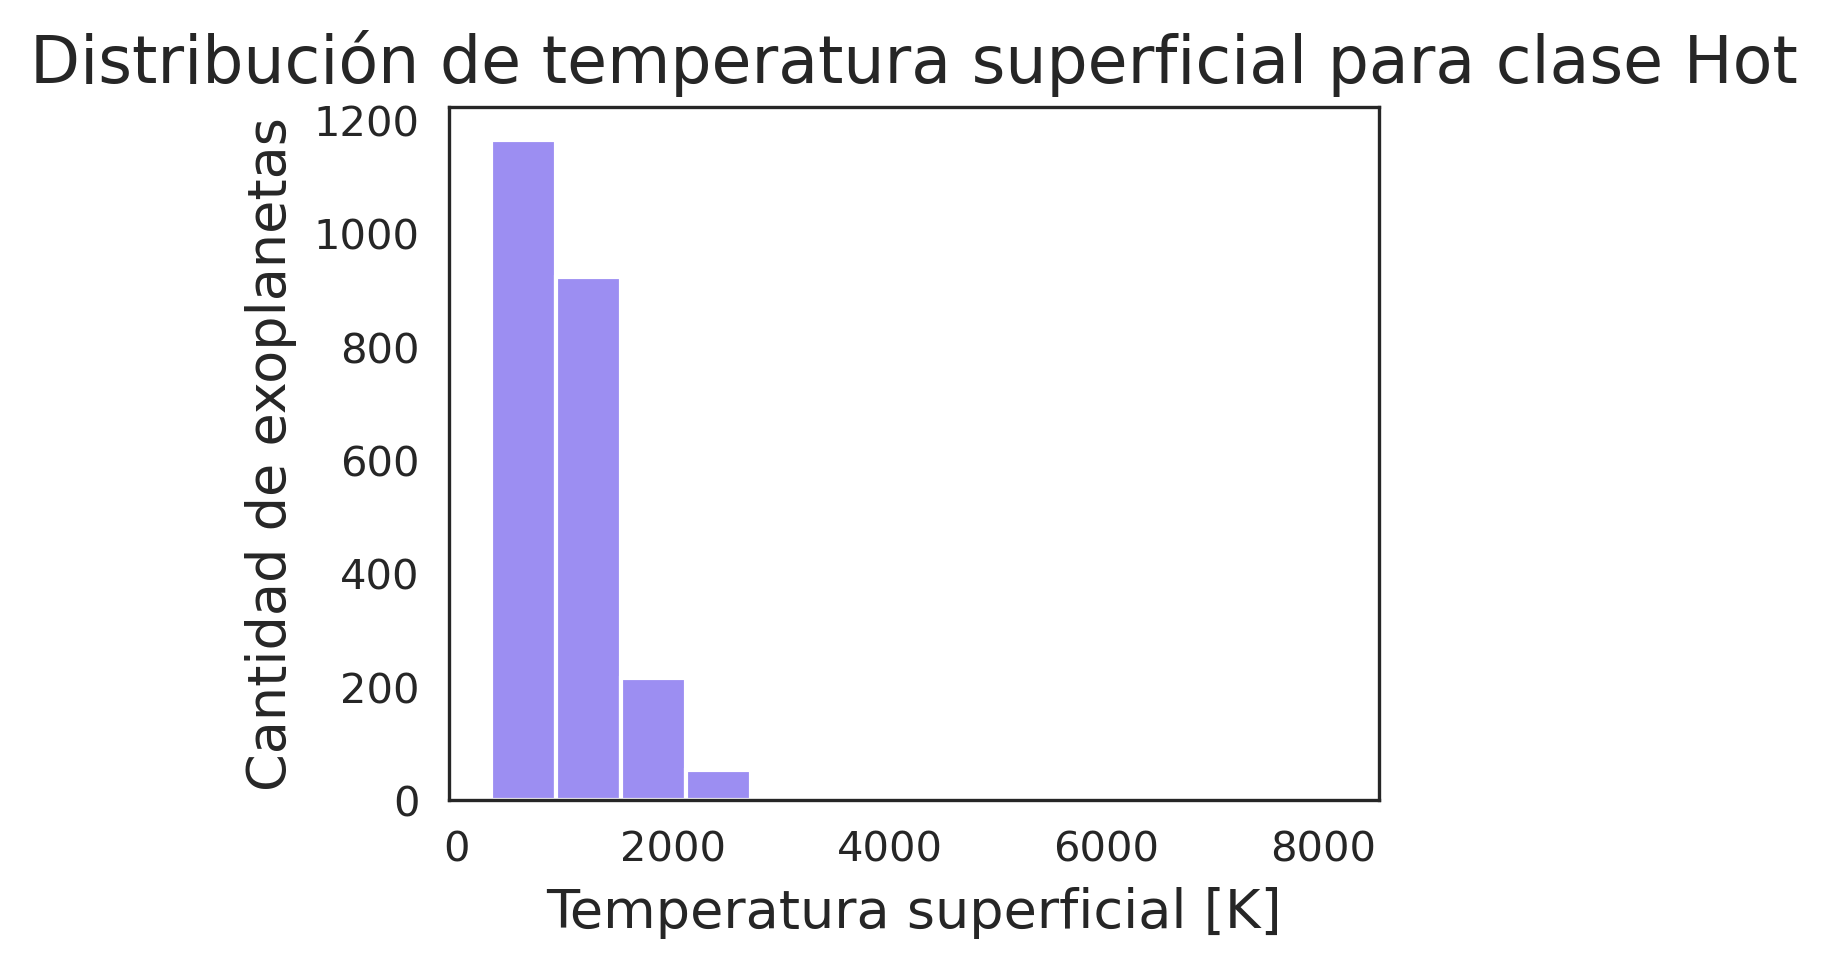

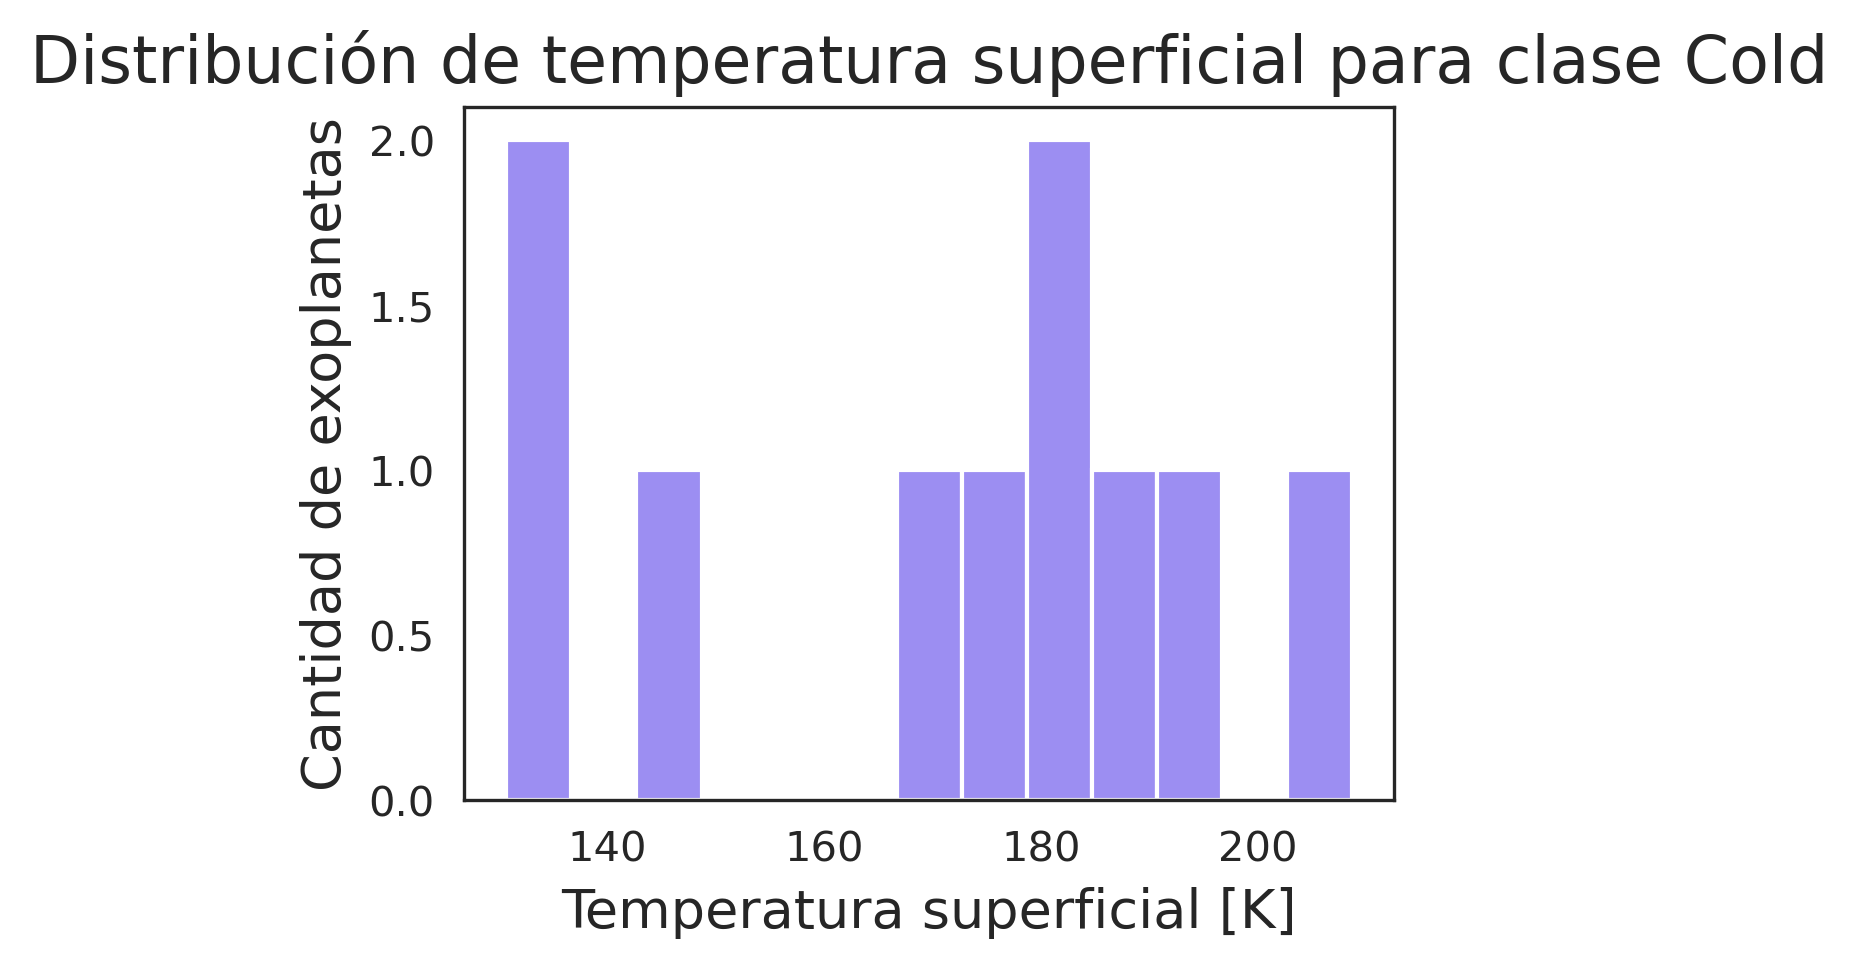

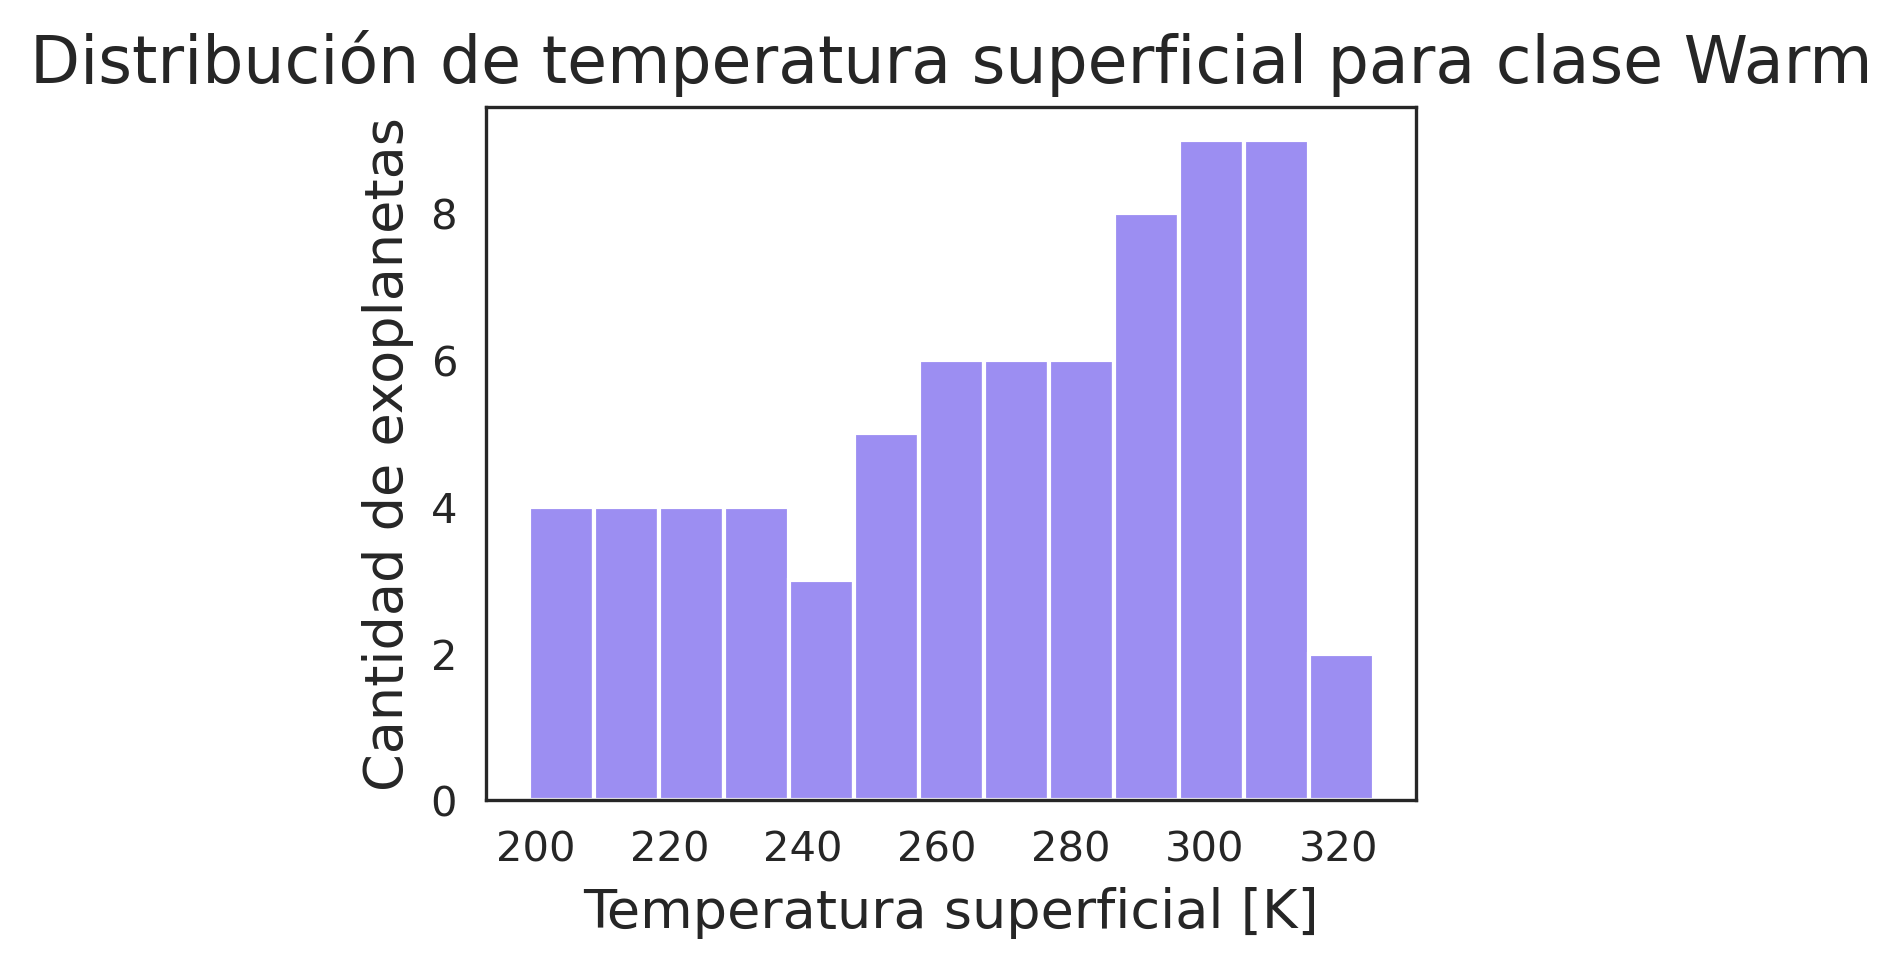

In [39]:
for clasenum in ["Hot", "Cold", "Warm"]:
    clasee = EXO_set[(EXO_set["P_TEMP_SURF"].notnull()) & (EXO_set["P_TYPE_TEMP"] == clasenum)]
    plt.figure(figsize=(4,3))
    sns.histplot(data=clasee, x="P_TEMP_SURF", color="mediumslateblue", bins=13)
    plt.xlabel("Temperatura superficial [K]")
    plt.ylabel("Cantidad de exoplanetas")
    plt.title(f"Distribución de temperatura superficial para clase {clasenum}")
    plt.show()

**4. `P_MASS` tiene pocos datos faltantes.**

- Qué estrategia simple usaría en este caso? Yo creo que se podría reemplazar algún que otro parámetro, pero si quizás considerara la media o mediana no existirían quizás cambios considerables como para ver una variación de la distribución a partir de la que se pueda concluir. Luego como se tienen los clasificables para las masas podría usarse el valor que más se repita dependiendo de la masa esto es la moda, para enfatizar la categoría. Además, de que no debería afectar tanto la distribución como tal, por ser apenas 0.1% del 100%.
- Por qué el tratamiento puede ser distinto al de `P_TEMP_SURF`? Porque en los valores cuantitativos de la temperatura superficial al faltar muchos datos, podría afectar al reemplazar muchos datos iguales, sería casi todo "inventado", y no resultaría representativo.


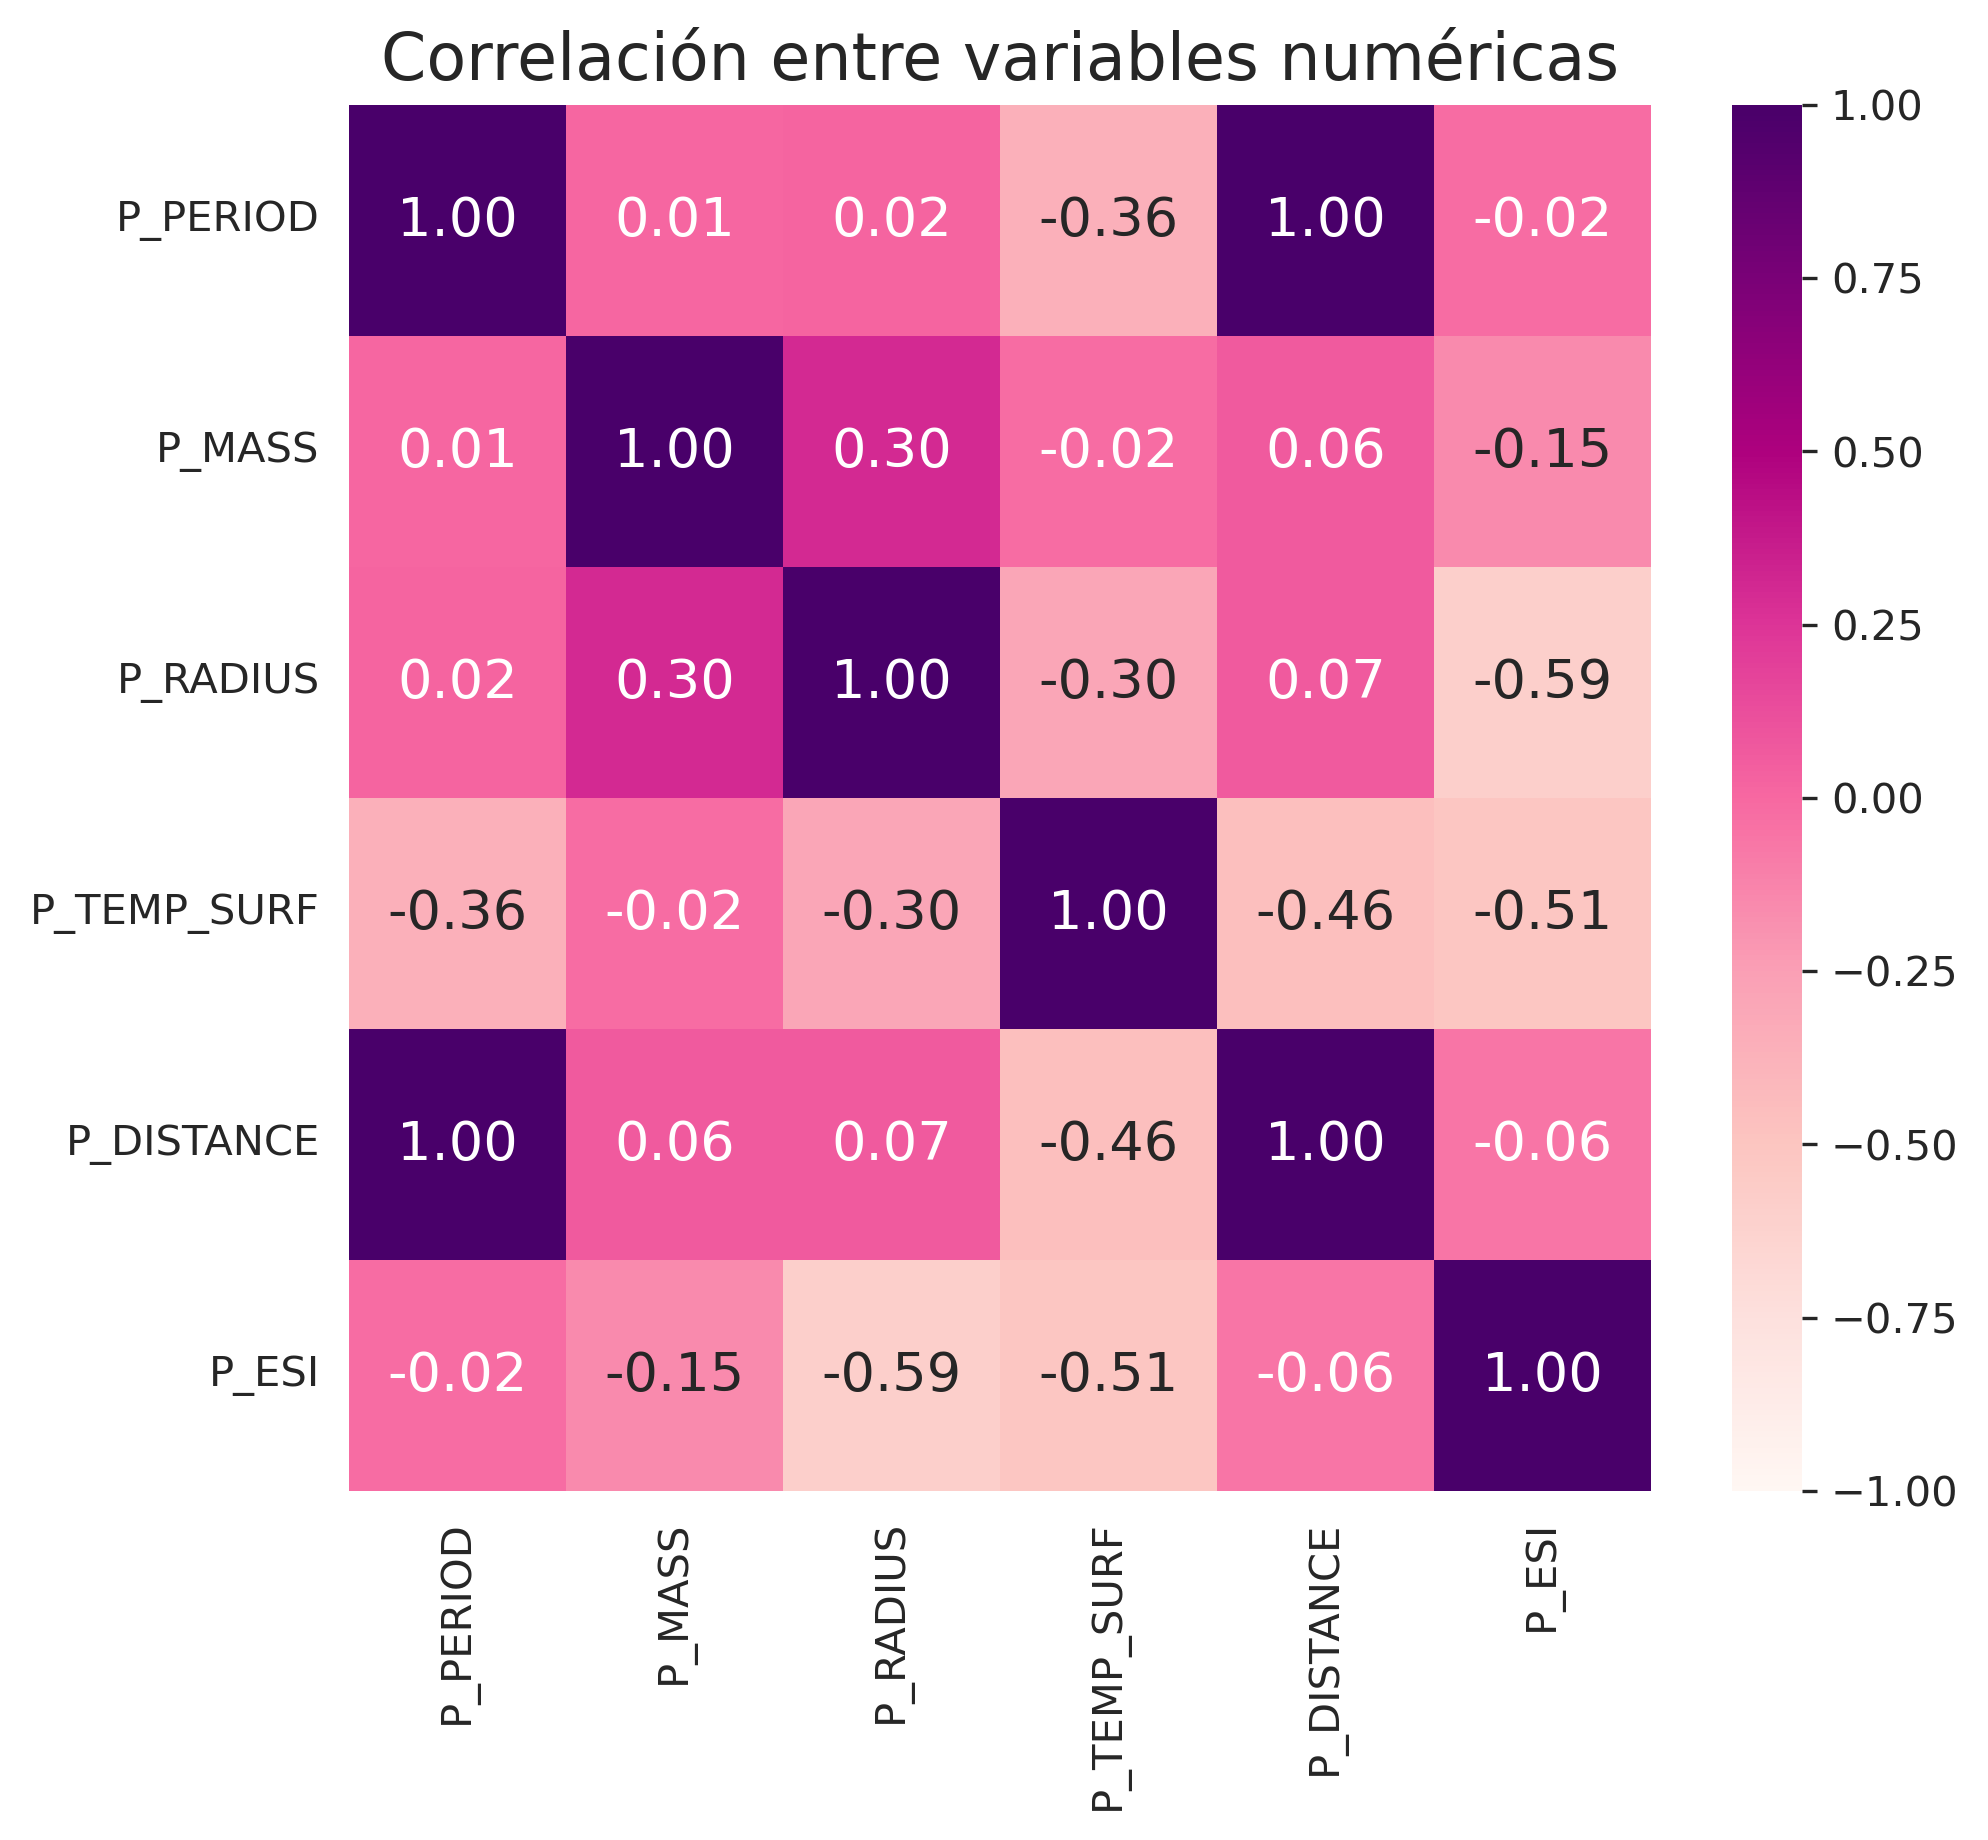

In [40]:
numericas = ["P_PERIOD", "P_MASS", "P_RADIUS", "P_TEMP_SURF", "P_DISTANCE", "P_ESI"]
corr = EXO_set[numericas].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, cmap="RdPu", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlación entre variables numéricas")
plt.show()

In [41]:
(EXO_set["P_PERIOD"] == EXO_set["P_DISTANCE"]).sum()
EXO_set[["P_PERIOD","P_DISTANCE"]].head(20)

,P_PERIOD,P_DISTANCE
0,NaN,3.400000
1,31.884000,0.199400
2,6.883376,0.067800
3,1.921036,0.029100
4,11.119907,0.091100
5,7.493134,0.065700
6,4.071820,0.053007
7,17.050300,0.120069
8,3180.600000,5.922383
9,696.620000,1.920268


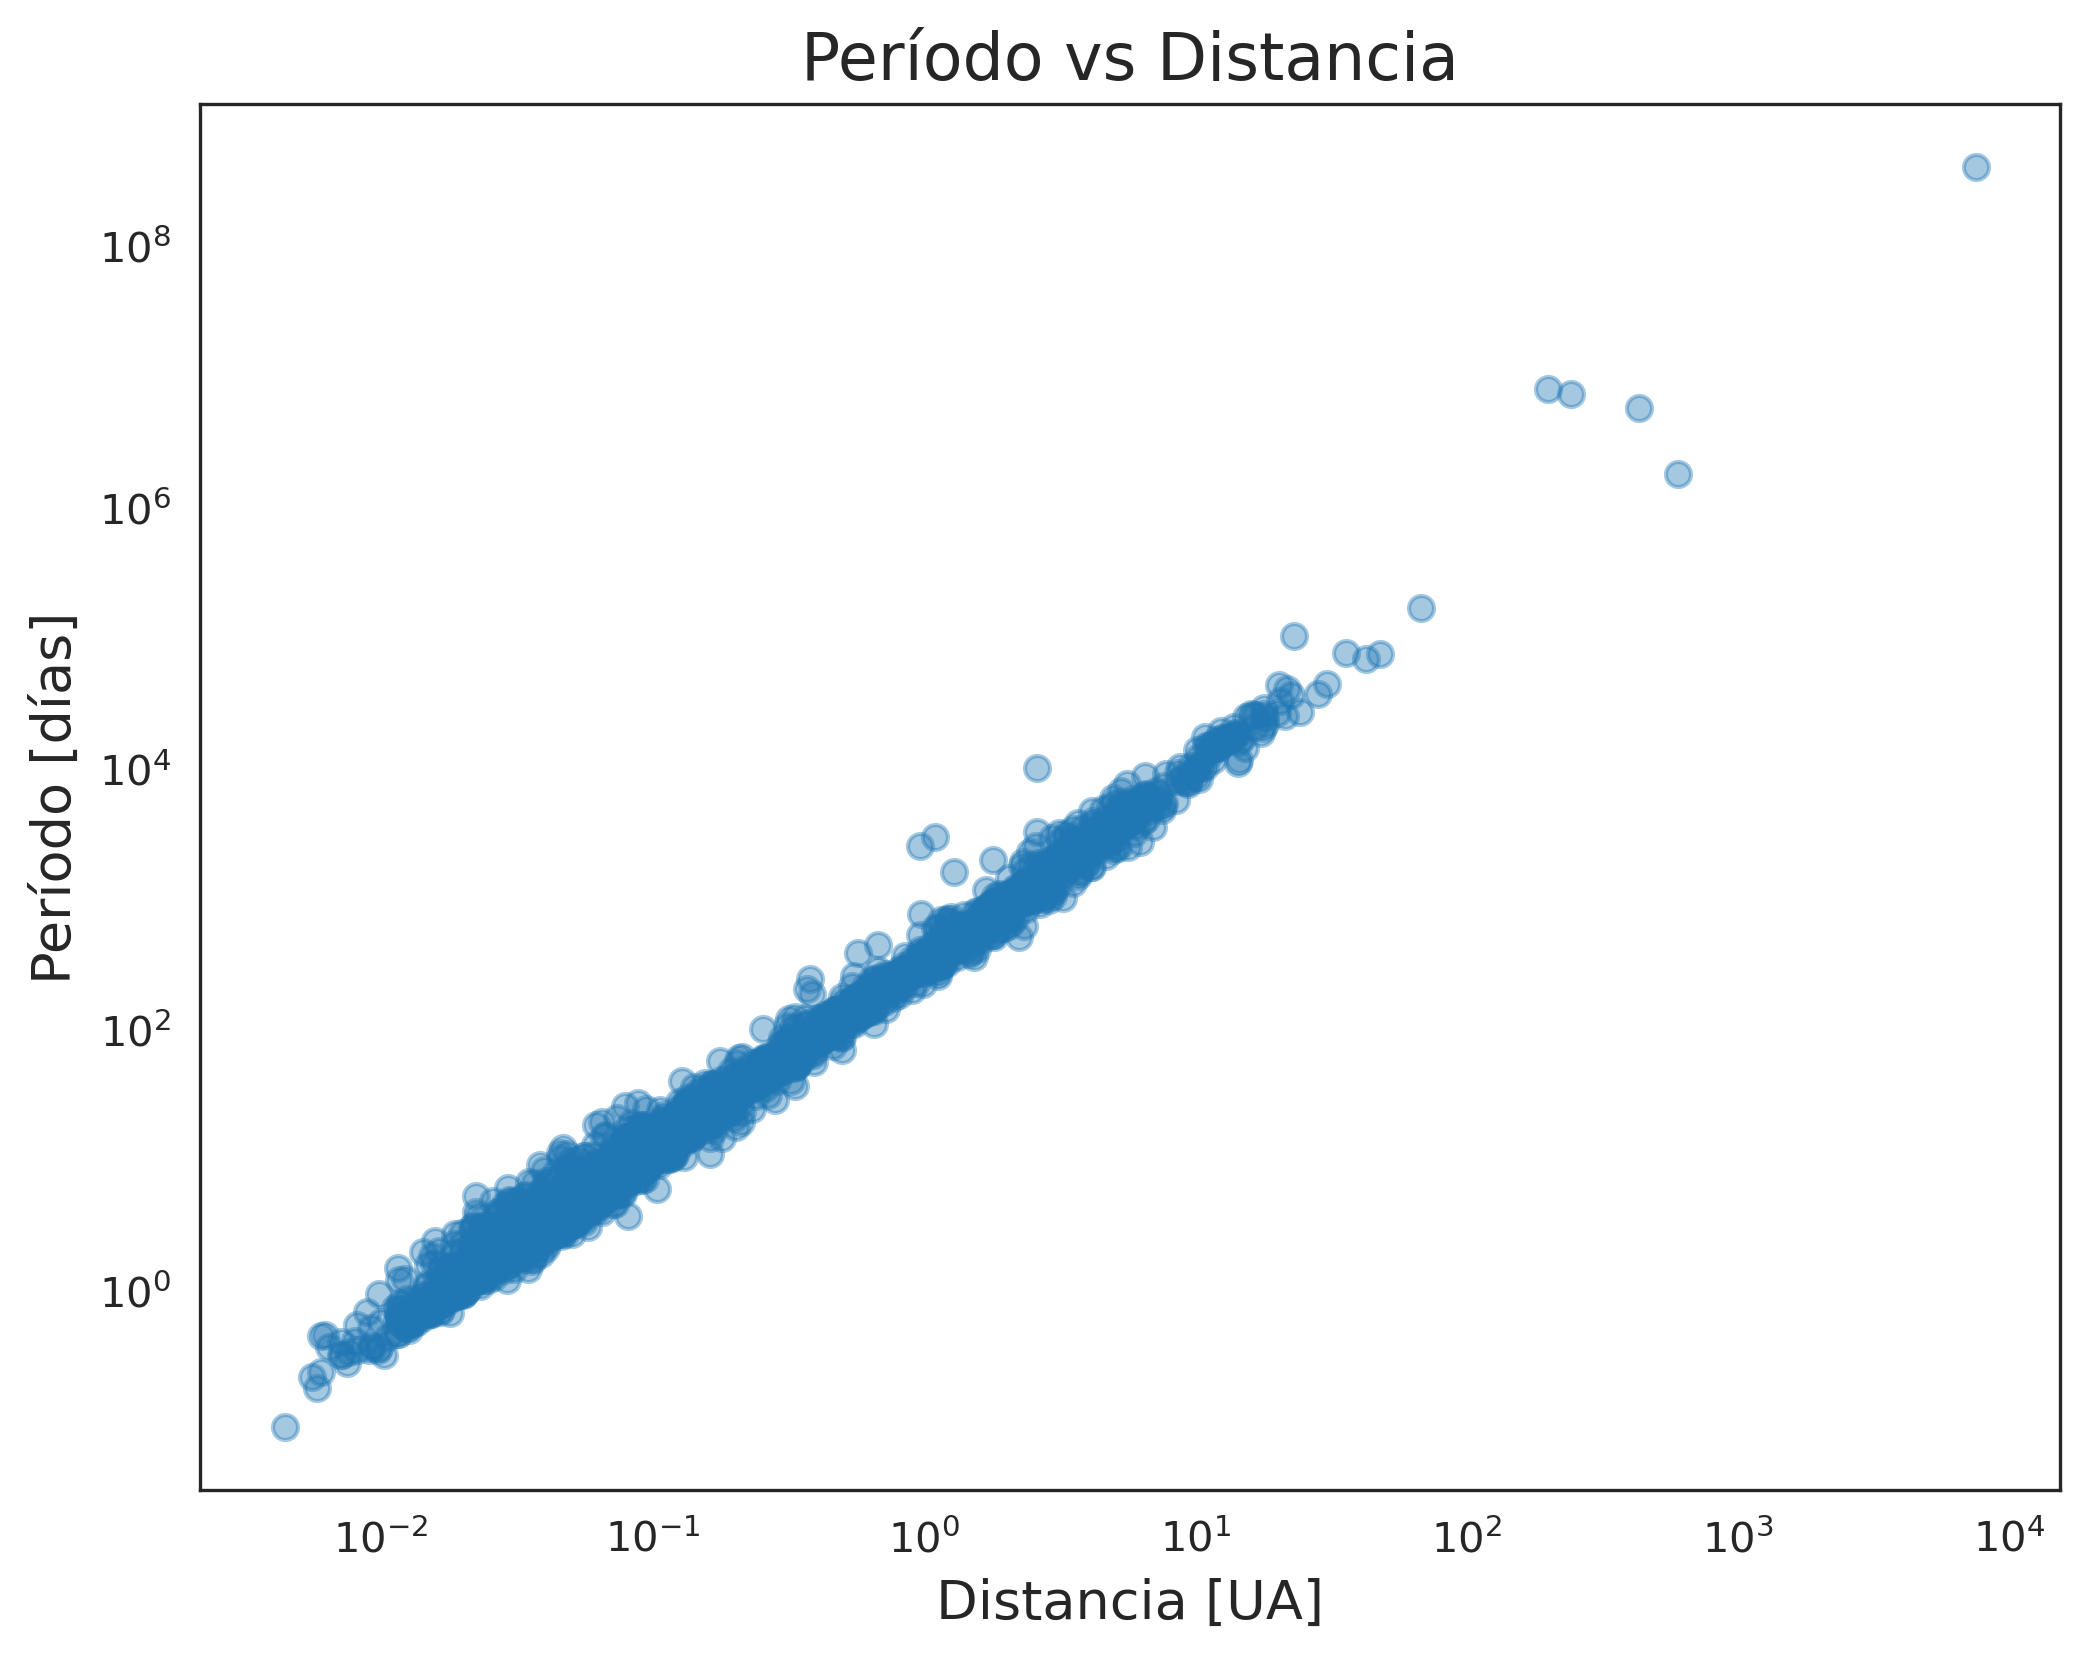

,P_PERIOD,P_DISTANCE
P_PERIOD,1.000000,0.991259
P_DISTANCE,0.991259,1.000000


In [42]:
plt.figure(figsize=(8,6))
plt.scatter(EXO_set["P_DISTANCE"], EXO_set["P_PERIOD"], alpha=0.4)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Distancia [UA]")
plt.ylabel("Período [días]")
plt.title("Período vs Distancia")
plt.show()
EXO_set[["P_PERIOD","P_DISTANCE"]].corr(method="spearman")

P_PERIOD y P_DISTANCE muestran una correlación de aproximadamente 1.00. En un primer momento esto pareció sospechoso (posible columna duplicada o error de datos), pero al verificar los valores fila por fila se confirmó que las columnas no son idénticas, y al graficar Período vs. Distancia en escala log-log se observa una relación monótona muy fuerte y consistente en todo el rango de datos.
Esto tiene sentido físico: es un reflejo directo de la Tercera Ley de Kepler, donde el período orbital de un planeta escala con su distancia a la estrella (P² ∝ a³, ajustado por la masa de la estrella). Que esta relación aparezca tan marcada en los datos es en realidad una buena señal de consistencia física del catálogo, más que un problema de calidad de datos.
Esto además muestra que P_PERIOD y P_DISTANCE contienen información muy redundante entre sí para efectos de un futuro modelo de ML: si se usa una, probablemente no aporte mucho incluir también la otra como feature independiente.

<h2 style="color:#BA55D3; font-family:; text-align:center;font-size:20px">
  Explorar relaciones entre características
</h2>
Después de estudiar las características individualmente, la idea es buscar como se relacionan las características de los exoplanetas buscando estructura en los datos.

Preguntas posibles:

- La temperatura superficial cuantitativa está relacionada con la clase cualitativa (hot,warm,cold)? Como podemos visualizar en el boxplot, podría estar relacionada, también observando en la distribución de arriba.
  
- Las temperaturas son similares en todas las características cualitativas de temperatura? No son similares. Para el boxplot de clase Hot hay valores atípicos para temperaturas hasta de 8000 K, mientras que para Cold y Warm los boxplots no sobrepasan los 350 K.

### Ejemplo de gráfico: Clases de temperaturas y temperaturas superficiales
Un boxplot permite comparar la distribución de una característica numérica entre distintos grupos.

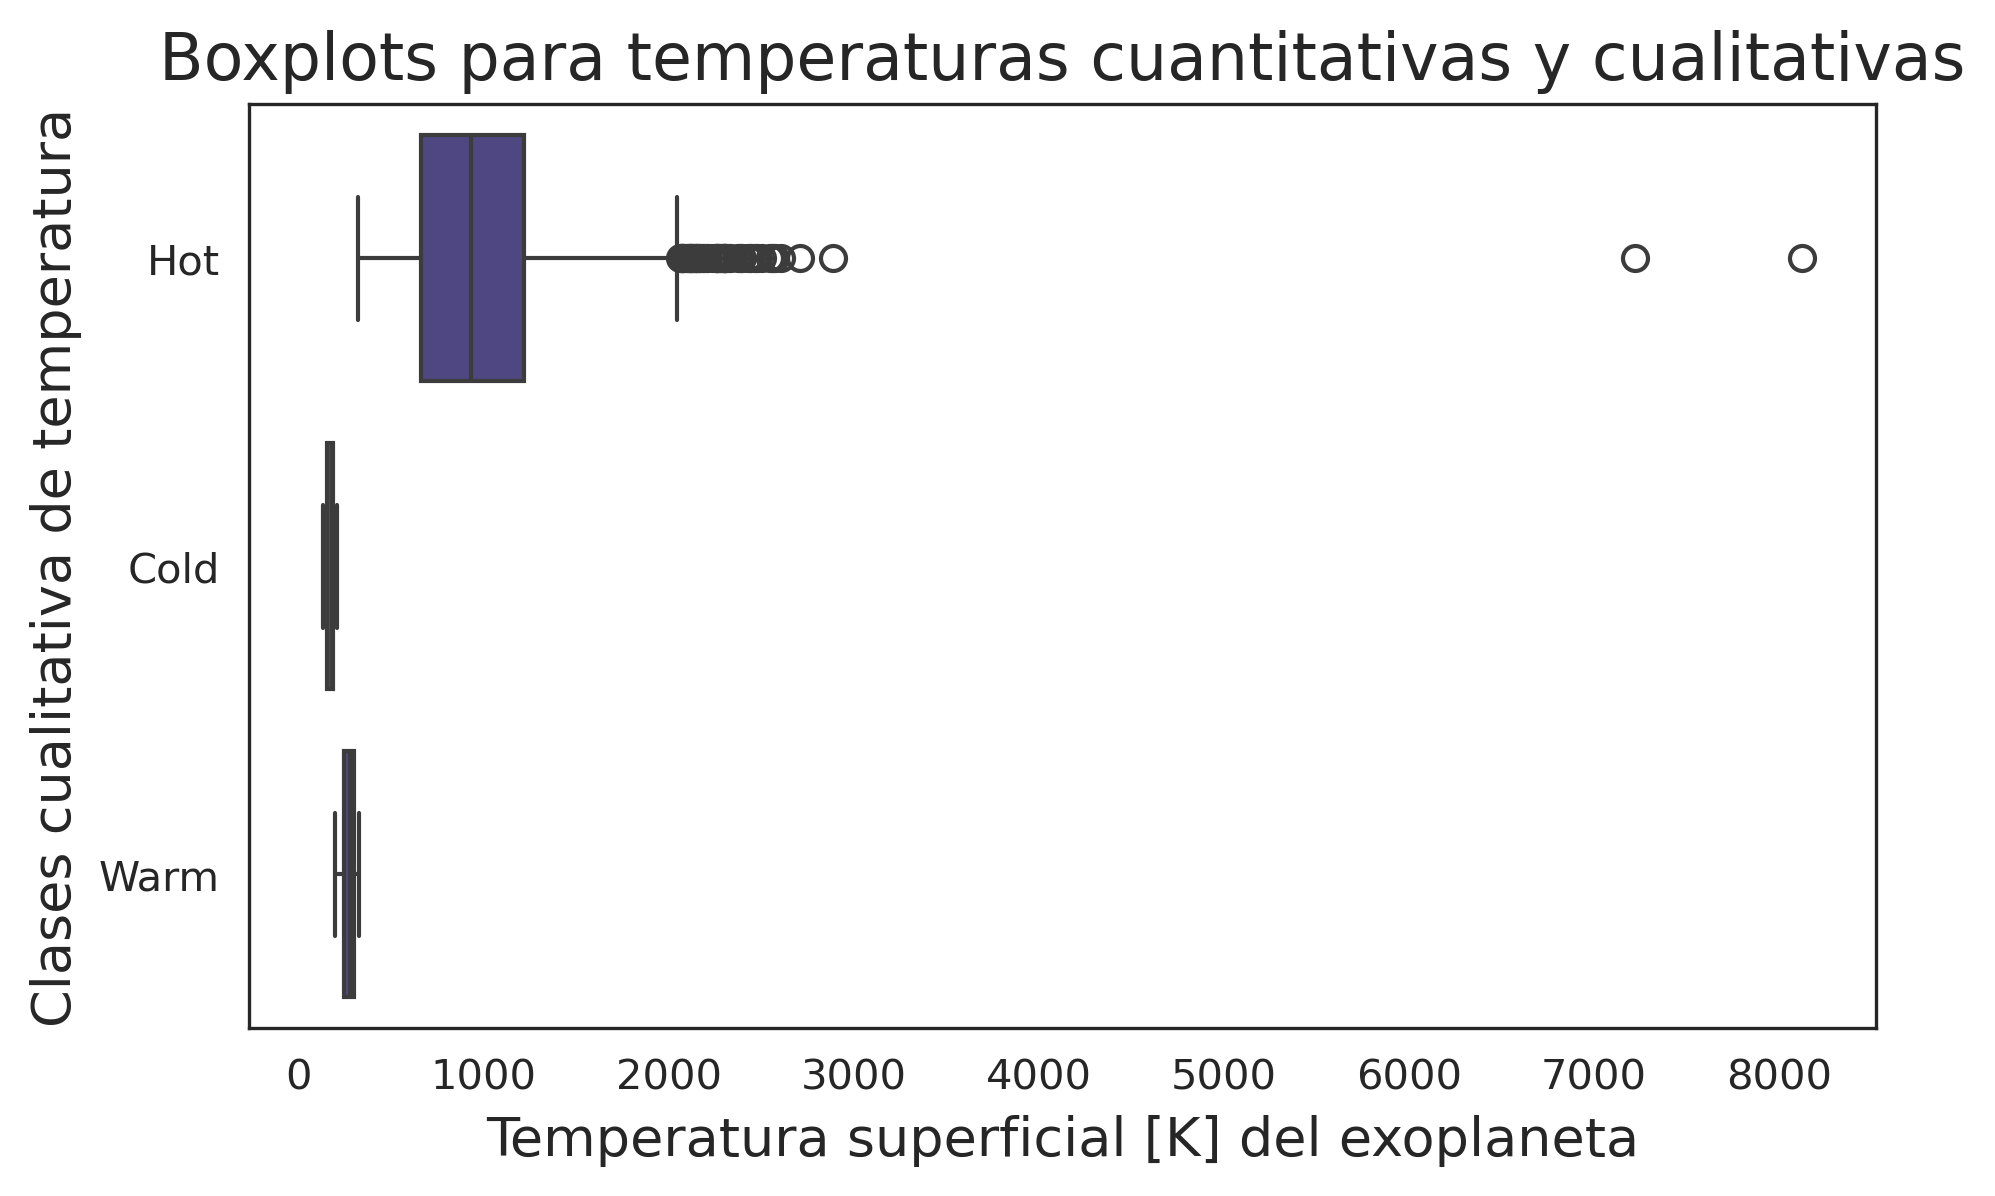

In [43]:
#Figura en general
plt.figure(figsize=(7,4))
sns.boxplot(data=EXO_set, x="P_TEMP_SURF", y="P_TYPE_TEMP", color='darkslateblue')
plt.xlabel("Temperatura superficial [K] del exoplaneta")
plt.ylabel("Clases cualitativa de temperatura")
plt.title("Boxplots para temperaturas cuantitativas y cualitativas")
plt.show()

- Cuáles exoplanetas para cada clase de exoplaneta están más cerca de su Sol? Se tiene que los Jovian están muy cerca, luego los Subterran, luego los Terran, los Superterran, Luego Neptunian y Miniterran se encuentran más alejados.
  
- Hay características que contienen información parcialmente similar? En este caso, para la relación entre clase de exoplaneta y distancia del exoplaneta a su Sol, no es que haya información similar, puesto que cada exoplaneta en si se caracterizará respecto a como sea estudiado.

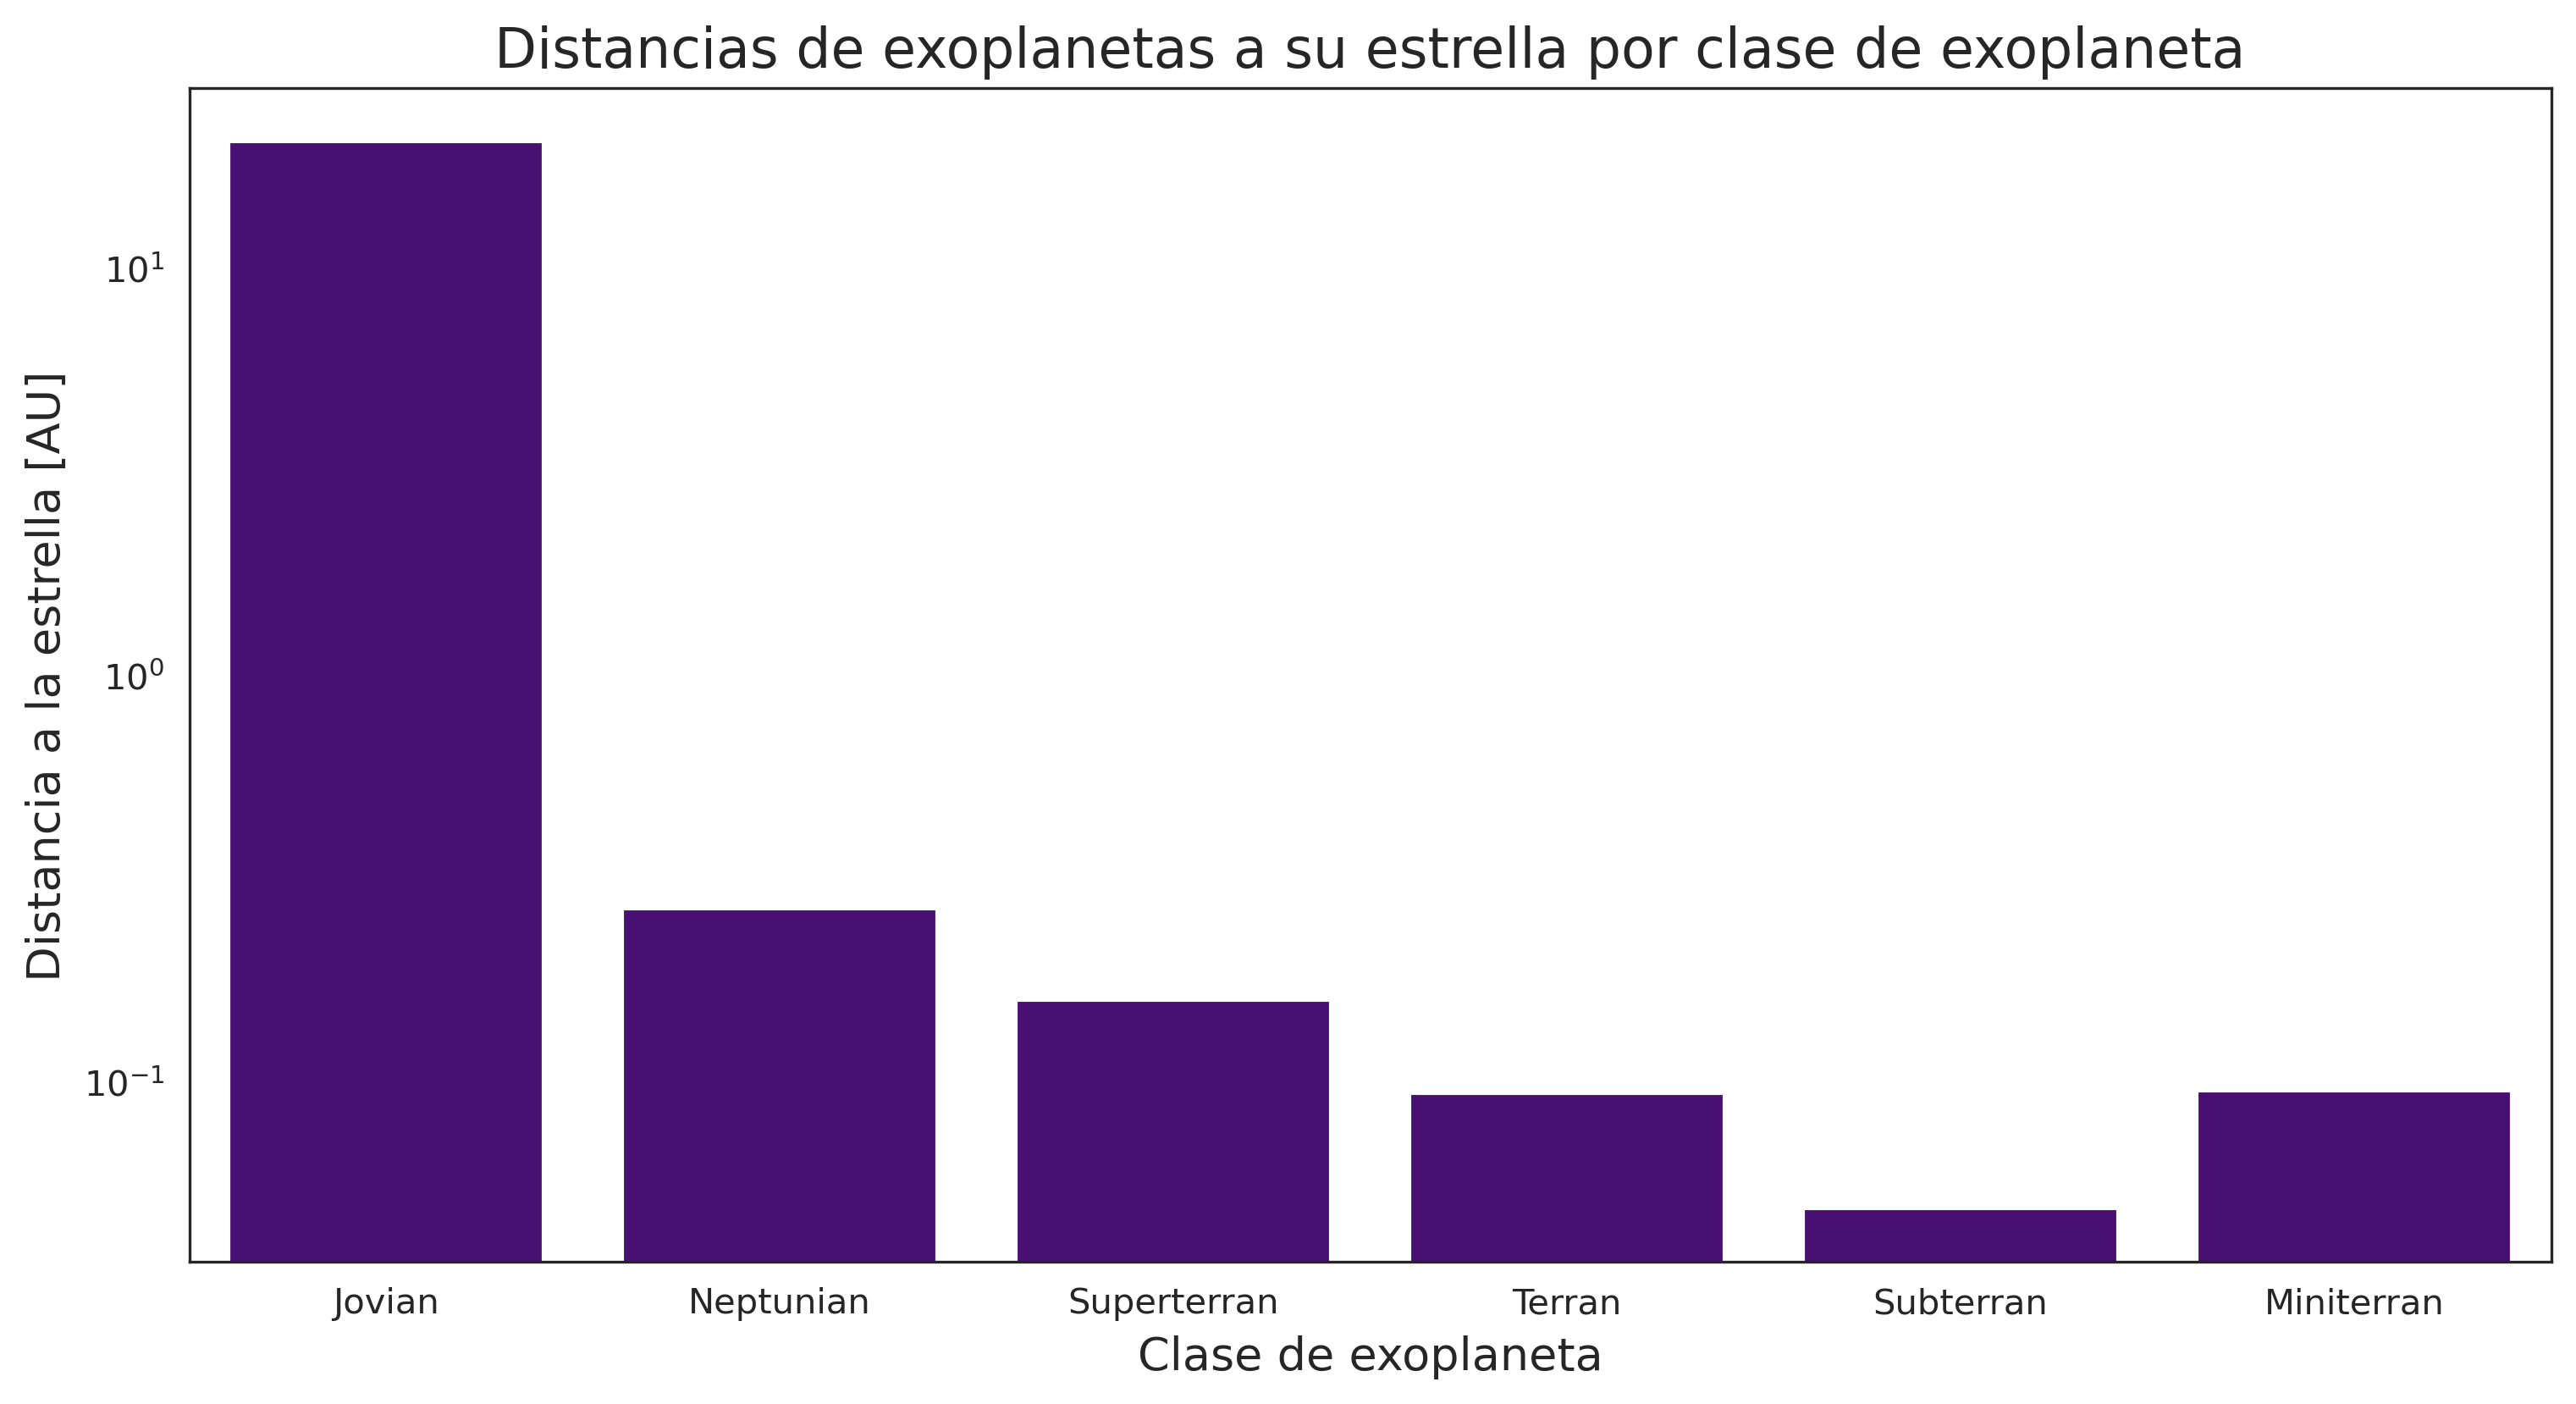

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("hwc.csv")
plt.figure(figsize=(12, 6))
sns.barplot(data=df,x="P_TYPE",y="P_DISTANCE",color="indigo",errorbar=None)
plt.xlabel("Clase de exoplaneta")
plt.ylabel("Distancia a la estrella [AU]")
plt.title("Distancias de exoplanetas a su estrella por clase de exoplaneta")
plt.yscale("log")
plt.show()

En el gráfico superior, se nota que los Jovianos están a distancias variadas hacia su Sol, mientras que los otros están a distancias menores. 

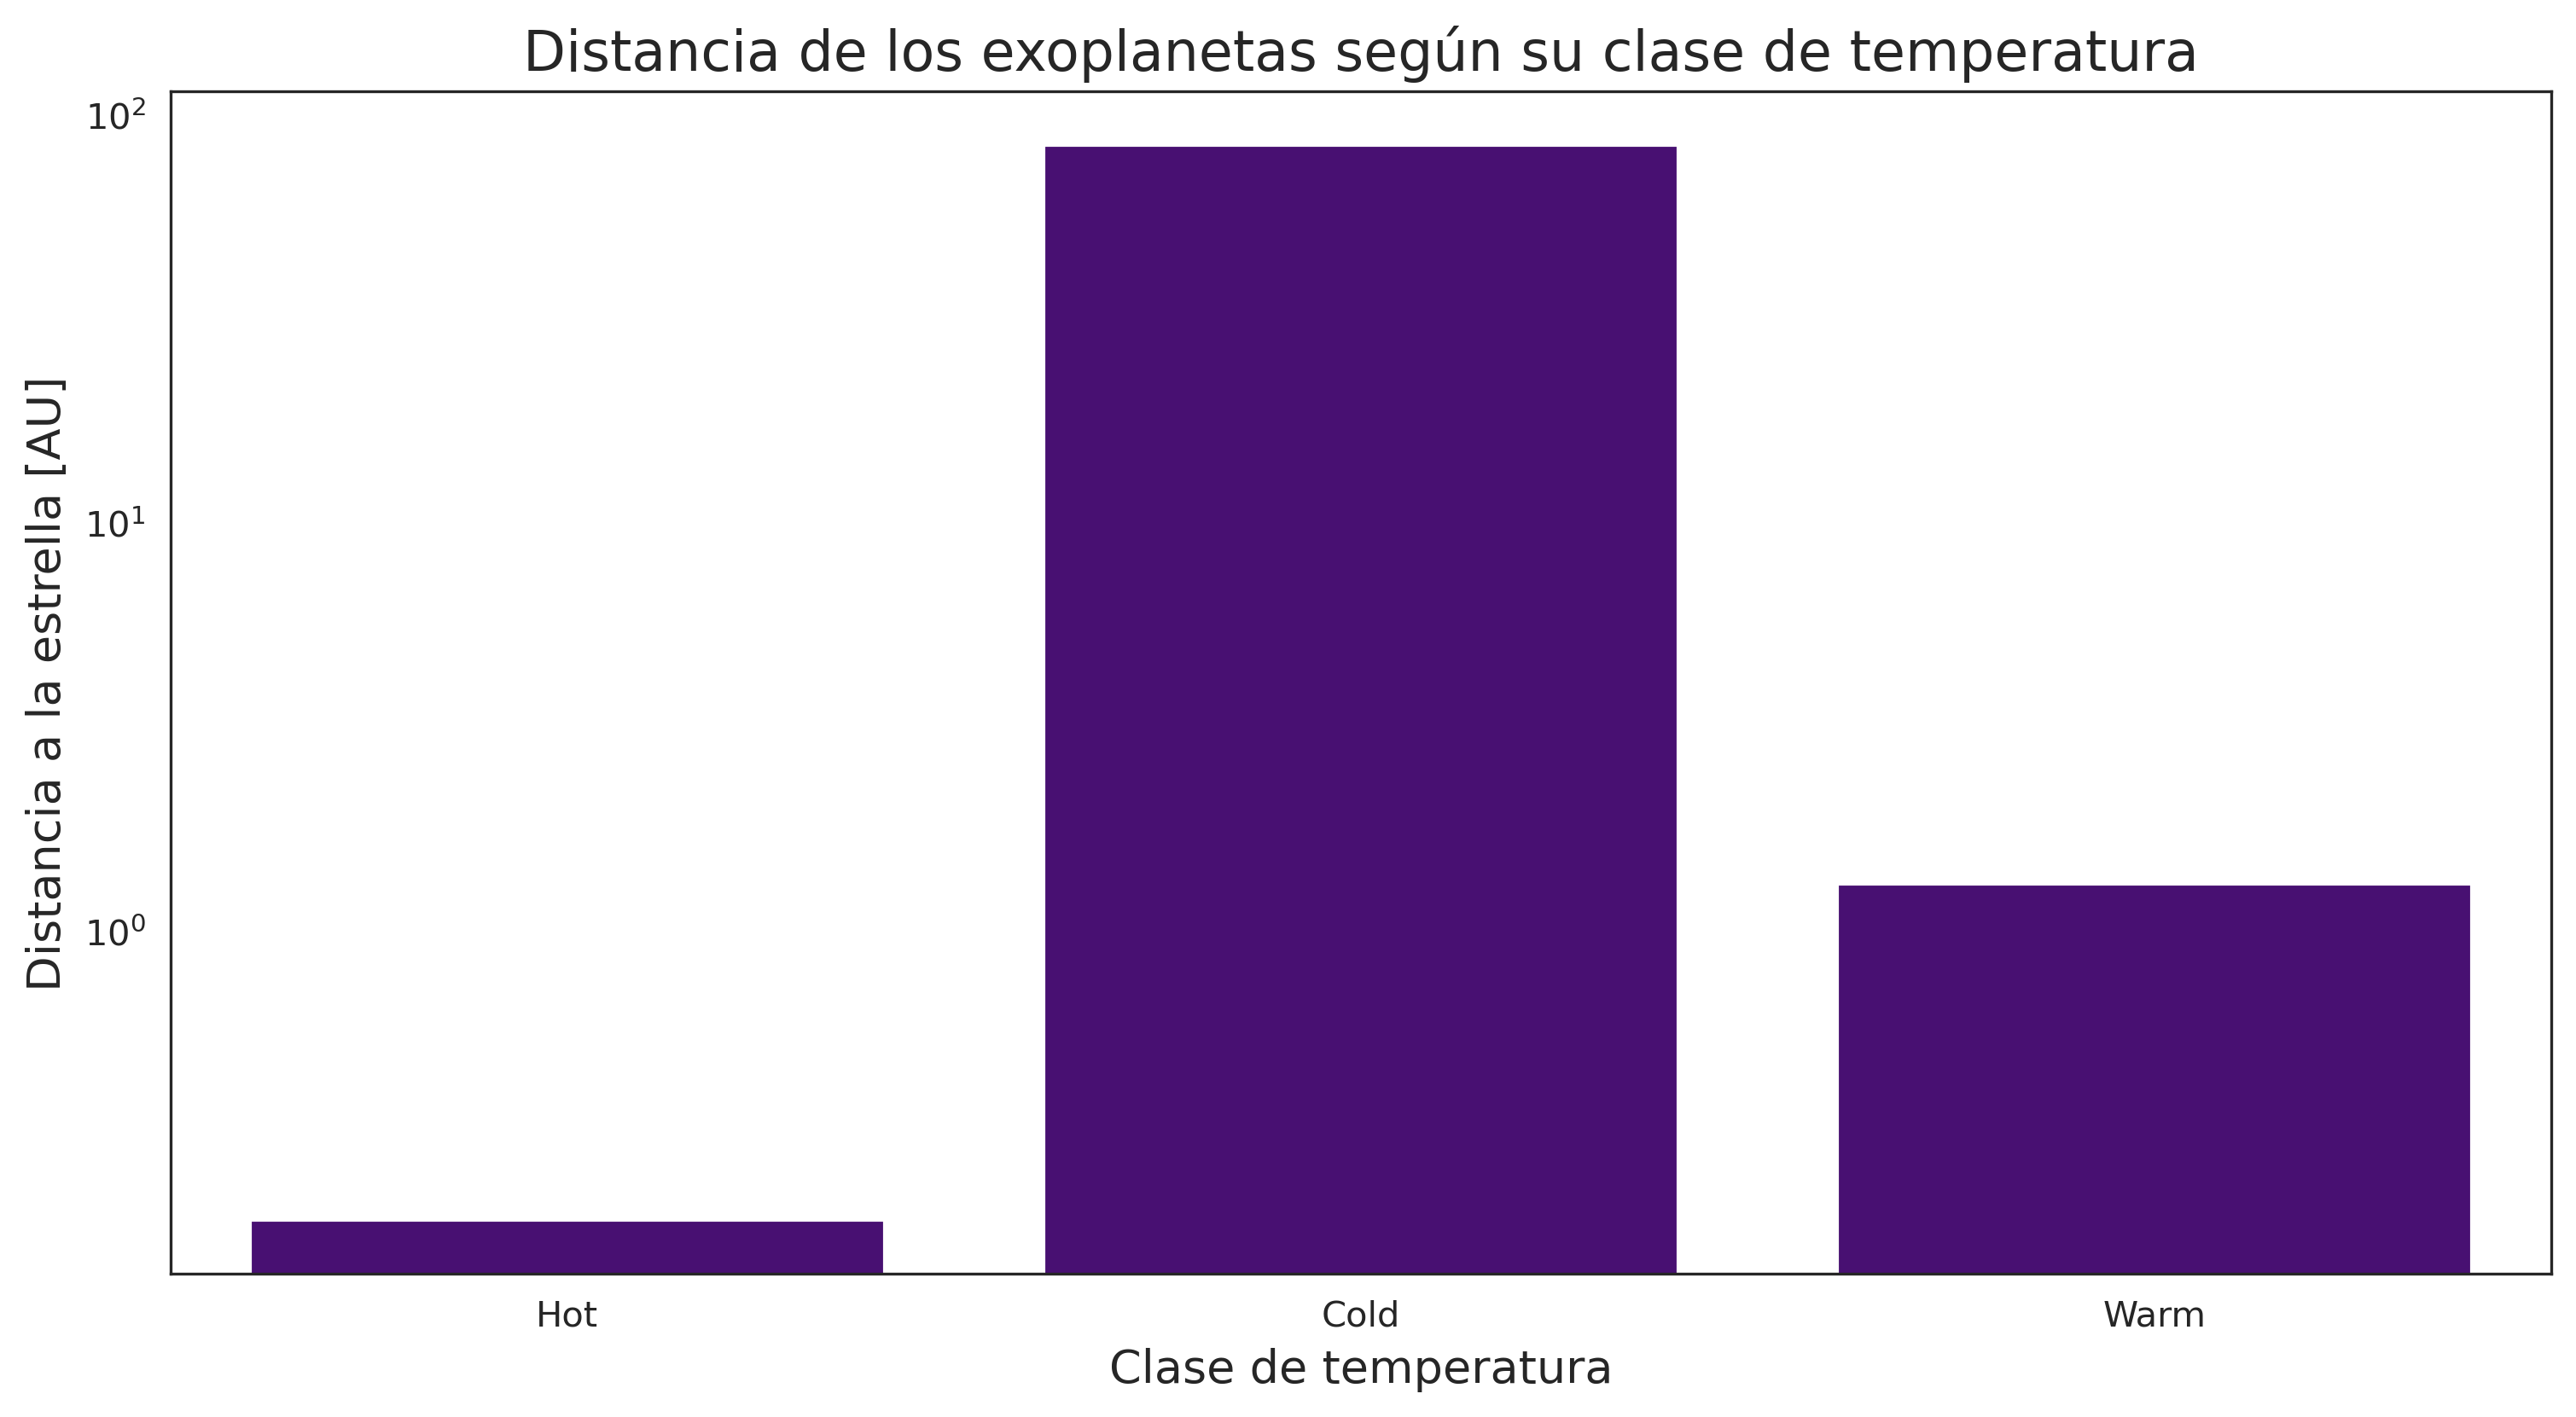

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("hwc.csv")
plt.figure(figsize=(12, 6))
sns.barplot(data=df,x="P_TYPE_TEMP",y="P_DISTANCE",color="indigo",errorbar=None)
plt.xlabel("Clase de temperatura")
plt.ylabel("Distancia a la estrella [AU]")
plt.title("Distancia de los exoplanetas según su clase de temperatura")
plt.yscale("log")
plt.show()

- Qué se puede decir sobre la distribución para cada clase de temperatura en relación con las distancias de los exoplanetas a sus "soles", es como se espera? Como se puede ver en el gráfico de barra se nota claramente que para los exoplanetas clasificados como Cold están mucho más alejados de su Sol, en comparación con los Warm donde tienen distancias menores y como se esperaría la clase Hot, aquellos exoplanetas están mucho más cerca de su Sol.

Por otra parte, se tienen las distintas distribuciones de temperaturas superficiales, dependiendo de cada clase Hot, Warm y Cold. Donde las medianas son; 929.51 K, 180.26 K y 275.60 K. Mientras que las medias son 996.21 K, 171.28 K y 269.50 K.

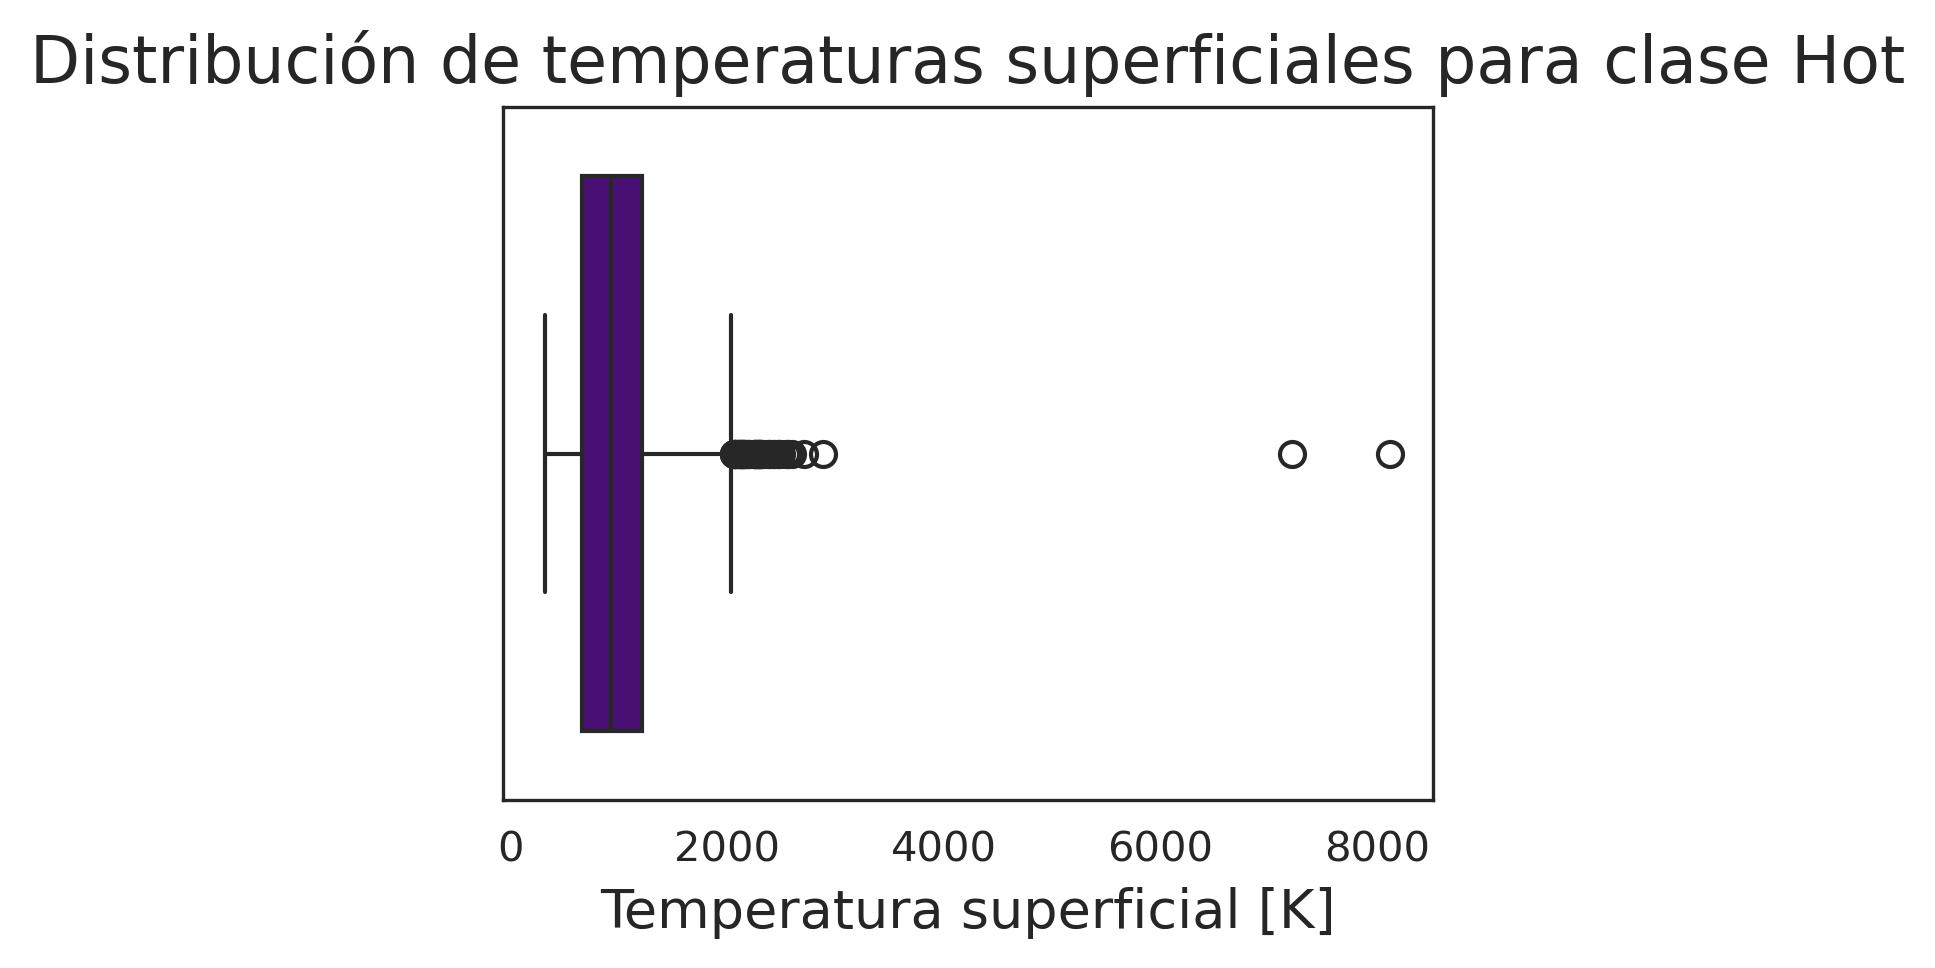

Valor de la mediana para clase Hot: 929.51 K
Valor de la media para clase Hot: 996.21 K


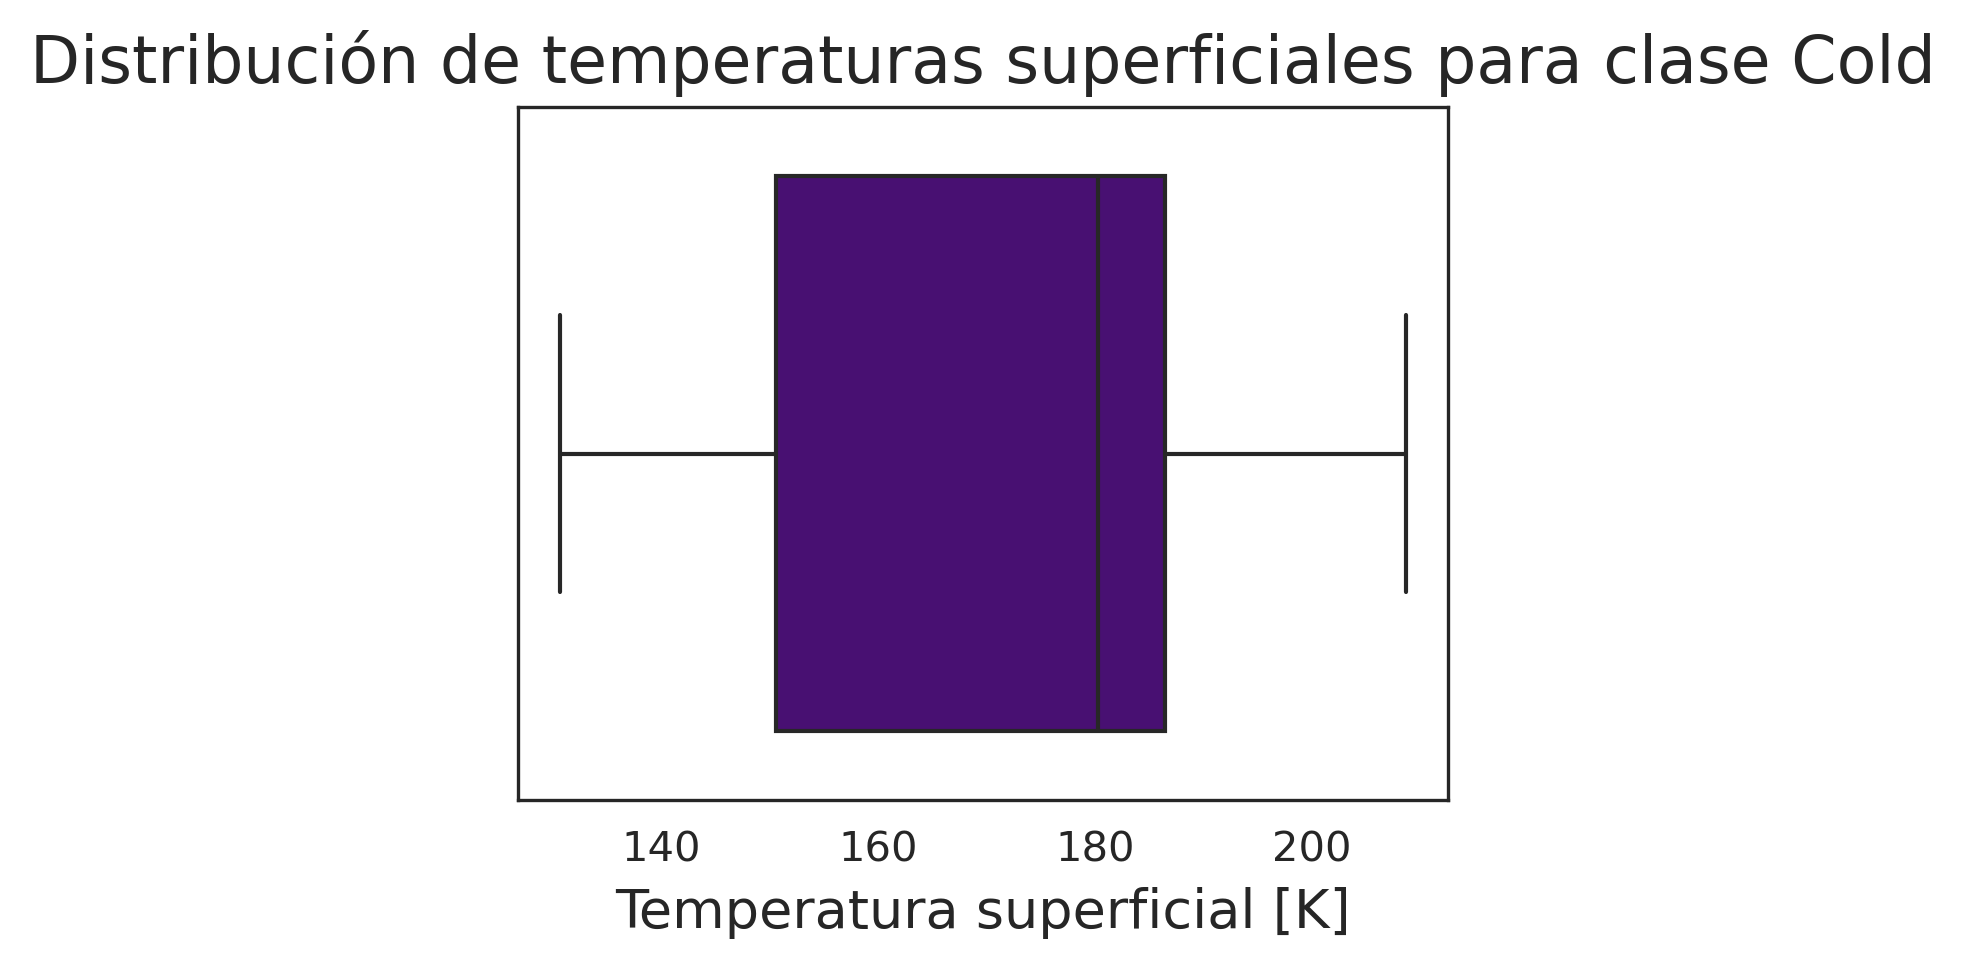

Valor de la mediana para clase Cold: 180.26 K
Valor de la media para clase Cold: 171.28 K


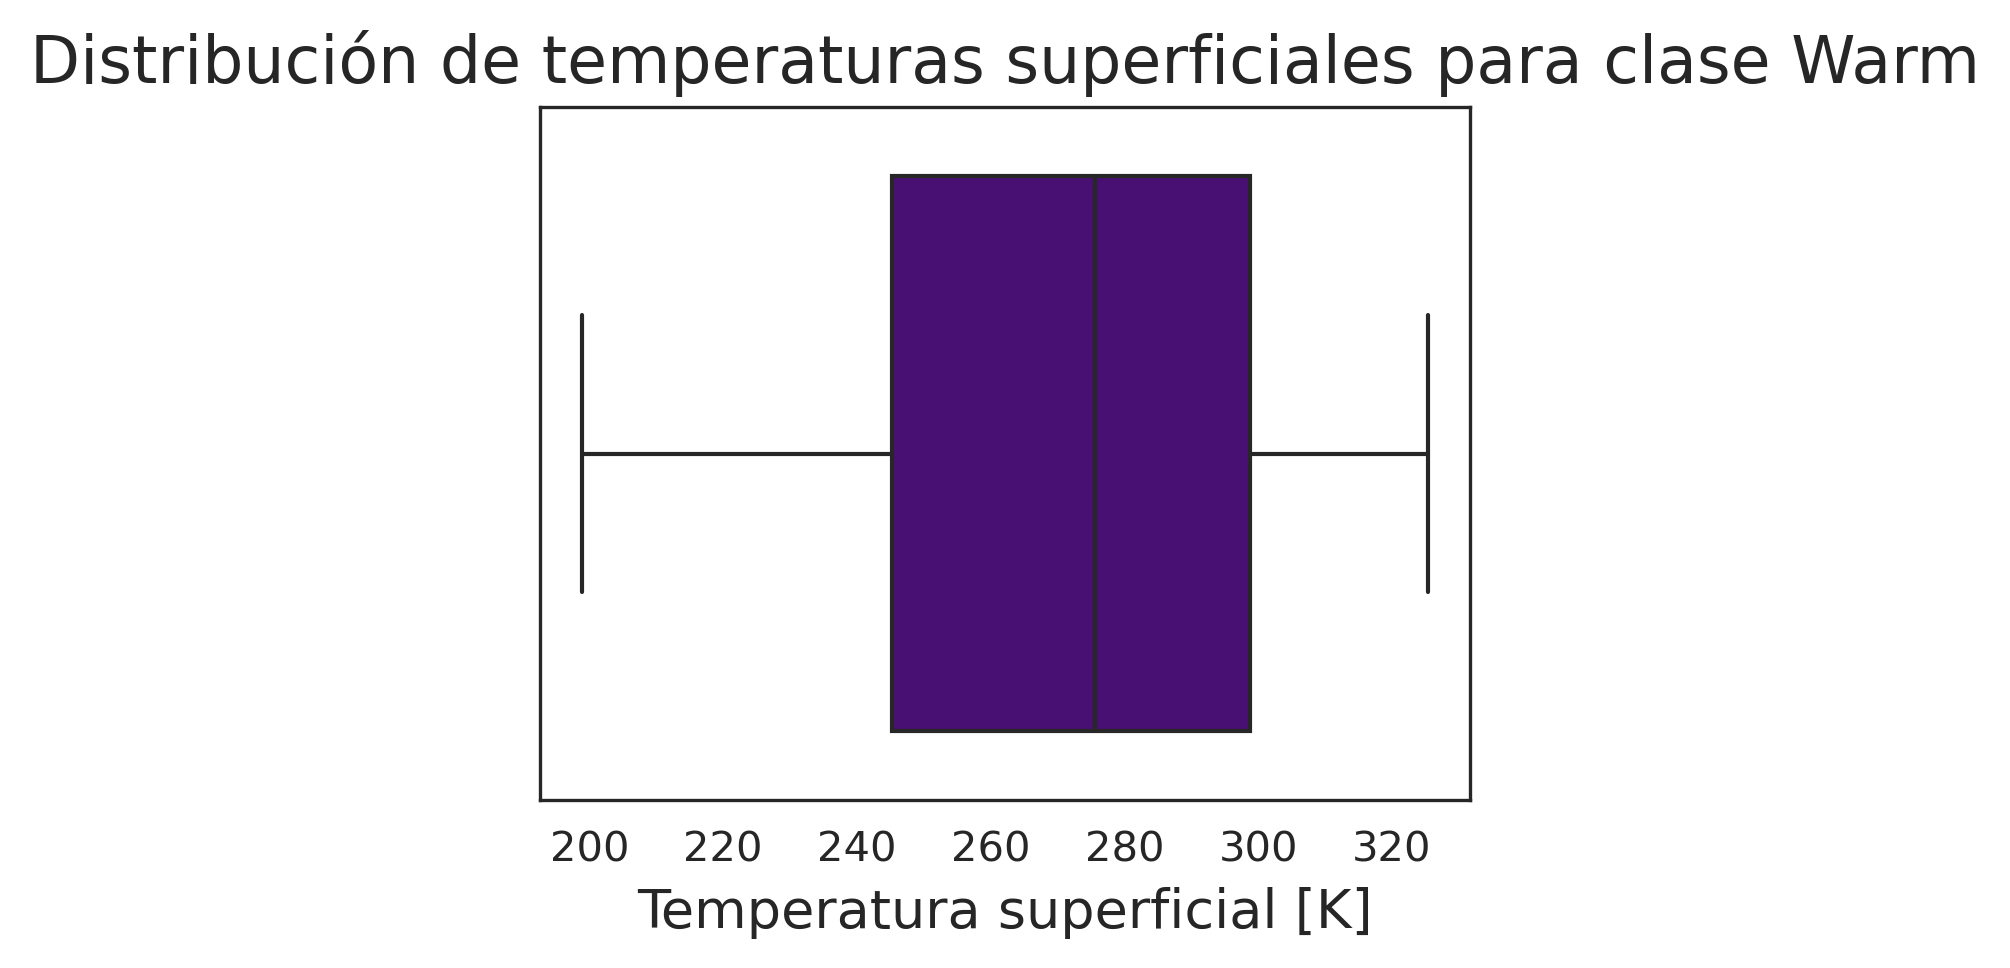

Valor de la mediana para clase Warm: 275.60 K
Valor de la media para clase Warm: 269.50 K


In [46]:
#Figuras por separado
for clasenum in ["Hot", "Cold", "Warm"]:
    clasee = EXO_set[EXO_set["P_TYPE_TEMP"] == clasenum]
    plt.figure(figsize=(4,3))
    sns.boxplot(data=clasee, x="P_TEMP_SURF", color="indigo")
    plt.xlabel("Temperatura superficial [K]")
    plt.title(f"Distribución de temperaturas superficiales para clase {clasenum}")
    #plt.xlim(0,1000)
    plt.show()
    print(f"Valor de la mediana para clase {clasenum}: {clasee['P_TEMP_SURF'].median():.2f} K")
    print(f"Valor de la media para clase {clasenum}: {clasee['P_TEMP_SURF'].mean():.2f} K")

### Preguntas

- La temperatura superficial parece estar relacionada con la clase cualitativa de temperatura? Al parecer como se ven en los boxplots, si puede estar relacionado, puesto que para la clase Hot se observa una temperatura media de 996.21 K, lo que equivale a 723.06 °C. Para el caso de la clase Cold la temperatura media es de alrededor 171.28 K, esto es -101.87°C. Por último para clase Warm se establece una temperatura media, cuyo valor es 269.50 K (-3.62°C), pero la mediana tiende a ser cercana a la de la Tierra (288K) con 275.60 K.

- Existen valores extremos? Sí existen, específicamente para la clase Hot donde incluso hay temperaturas superficiales muy extremas como 8000 K.

- Diría que la temperatura superficial y clase contienen exactamente la misma información? 
No del todo, existe relación entre ellas pero no necesariamente por ejemplo, un exoplaneta que  que sea de clase Cold y Warm podrían tener temperaturas muy cercanas siendo máxima para cold y mínima para warm. Además, aunque la clasificación de hot, warm, cold aluda a alguna temperatura esto es solo cualitativo, en cambio la temperatura superficial numérica indica concretamente si el exoplaneta es caliente o frío, por ello la relación (asociando la primera pregunta) permite ver entre que rangos se establece que sea caliente, tibio o frío.

### Ahora usted 

**1. Compare la distribución de temperaturas superficiales y distancias a su Sol entre las tres clases tanto de temperatura cualitativa como tipo de exoplaneta.**

- Se notan valores atípicos de distancias del exoplaneta a su Sol en todas las clases tanto de temperatura y como de tipo de exoplaneta? Se notan variados valores atípicos en los boxplots, tanto las diversas clases de temperatura y de tipo de exoplaneta.
  
- Qué diferencias se observan para las distintas clases de temperaturas? Tal como se había visto en el gráfico de distribución (no el boxplot) para las clases Warm y Cold para exoplanetas, están más alejados de su Sol y siendo ahora (observando el boxplot) que se observan varios valores atípicos, aquello confirma lo relacionado.

- Qué diferencias se observan para las distintas clases de exoplanetas? Para la clase de Jovianos, hay valores extendidos de distancias UA en comparación con los otros.


In [47]:
print("Max (UA):", EXO_set["P_DISTANCE"].max())
print("Min (UA):", EXO_set["P_DISTANCE"].min())

Max (UA): 7506.0
Min (UA): 0.00440792


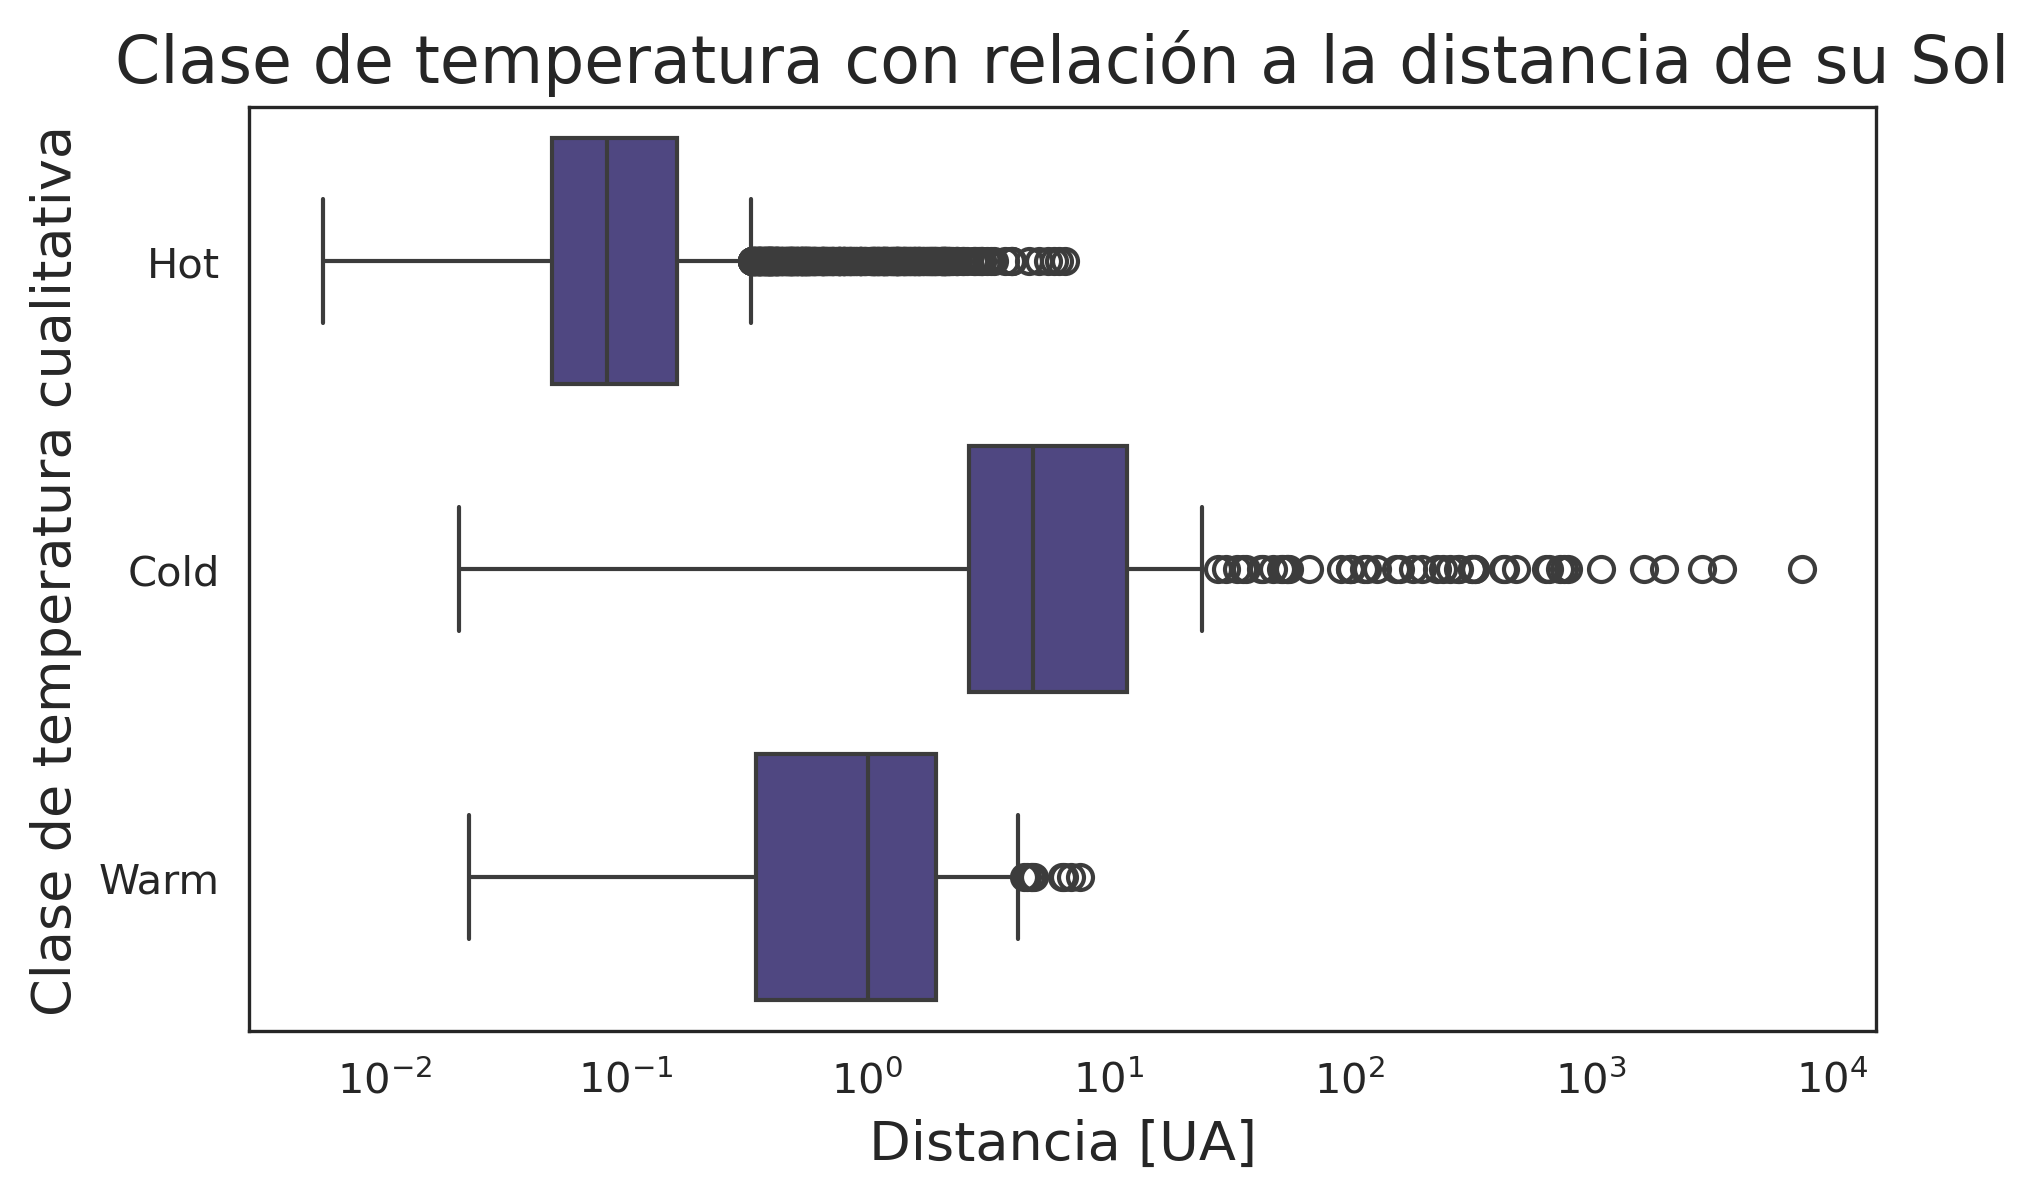

In [48]:
plt.figure(figsize=(7,4))
sns.boxplot(data=EXO_set, x="P_DISTANCE", y="P_TYPE_TEMP", color='darkslateblue')
plt.xlabel("Distancia [UA]")
plt.ylabel("Clase de temperatura cualitativa")
plt.title("Clase de temperatura con relación a la distancia de su Sol")
plt.xscale("log")
plt.show()

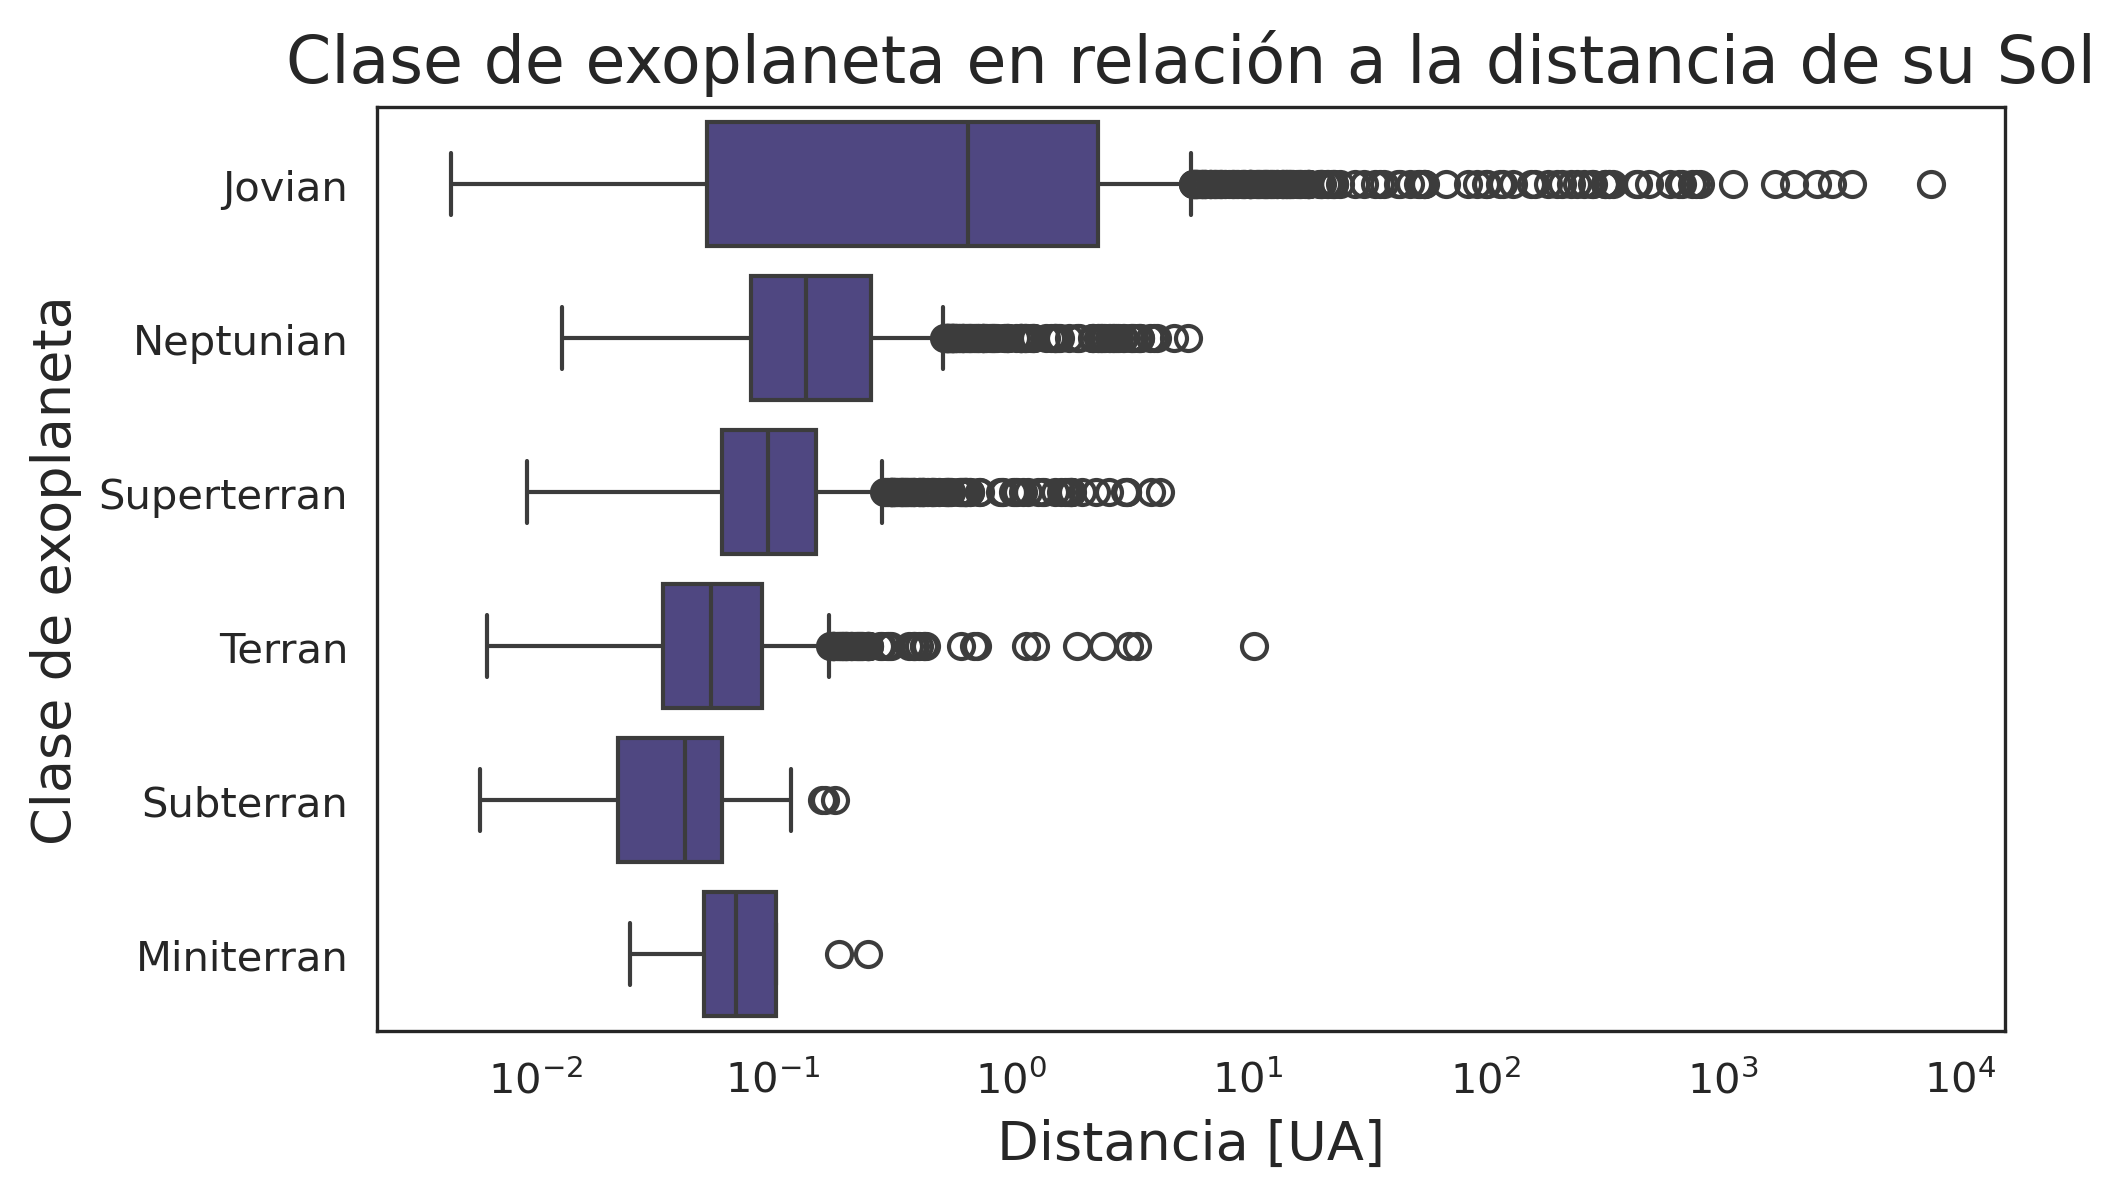

In [49]:
plt.figure(figsize=(7,4))
sns.boxplot(data=EXO_set, x="P_DISTANCE", y="P_TYPE", color='darkslateblue')
plt.xlabel("Distancia [UA]")
plt.ylabel("Clase de exoplaneta")
plt.title("Clase de exoplaneta en relación a la distancia de su Sol")
plt.xscale("log")
plt.show()

<h2 style="color:#BA55D3; font-family:; text-align:center;font-size:20px">
  Investigar sobre clases de exoplanetas existentes y su relación con temperatura cuantitativa/cualitativa
</h2>
¿Qué características estan asociadas con que un posible exoplaneta pueda ser posible habitable teniendo como base su clase y clase de temperatura?

Ahora incorporaremos `zona de habitabilidad óptima', como categoría que se quiere comprender. Además se puede comparar con el "P_ESI", que ndica cuan similar es el exoplaneta a la Tierra, con un ESI > 0.5 se considera potencialmente habitable.

Investigaremos si la zona de habitabilidad óptima y P_ESI está asociada con características como:

- temperatura superficial del exoplaneta
- clase de temperatura cualitativamente del exoplaneta
- distancia del exoplaneta a su Sol
- Tipo de planeta

<h2 style="color:fuchsia; font-family:; text-align:center;font-size:17px">
  Zona de Habitabilidad Óptima
</h2>

### Ejemplo de gráfico: supervivencia según clase de temperatura

Como la zona de habitabilidad toma valores 0 y 1, su promedio dentro de un grupo corresponde a la **fracción de exoplanetas se encuentra en una zona óptima o no para su habitabilidad**.

`seaborn.barplot` calcula por defecto la media de la variable del eje vertical.


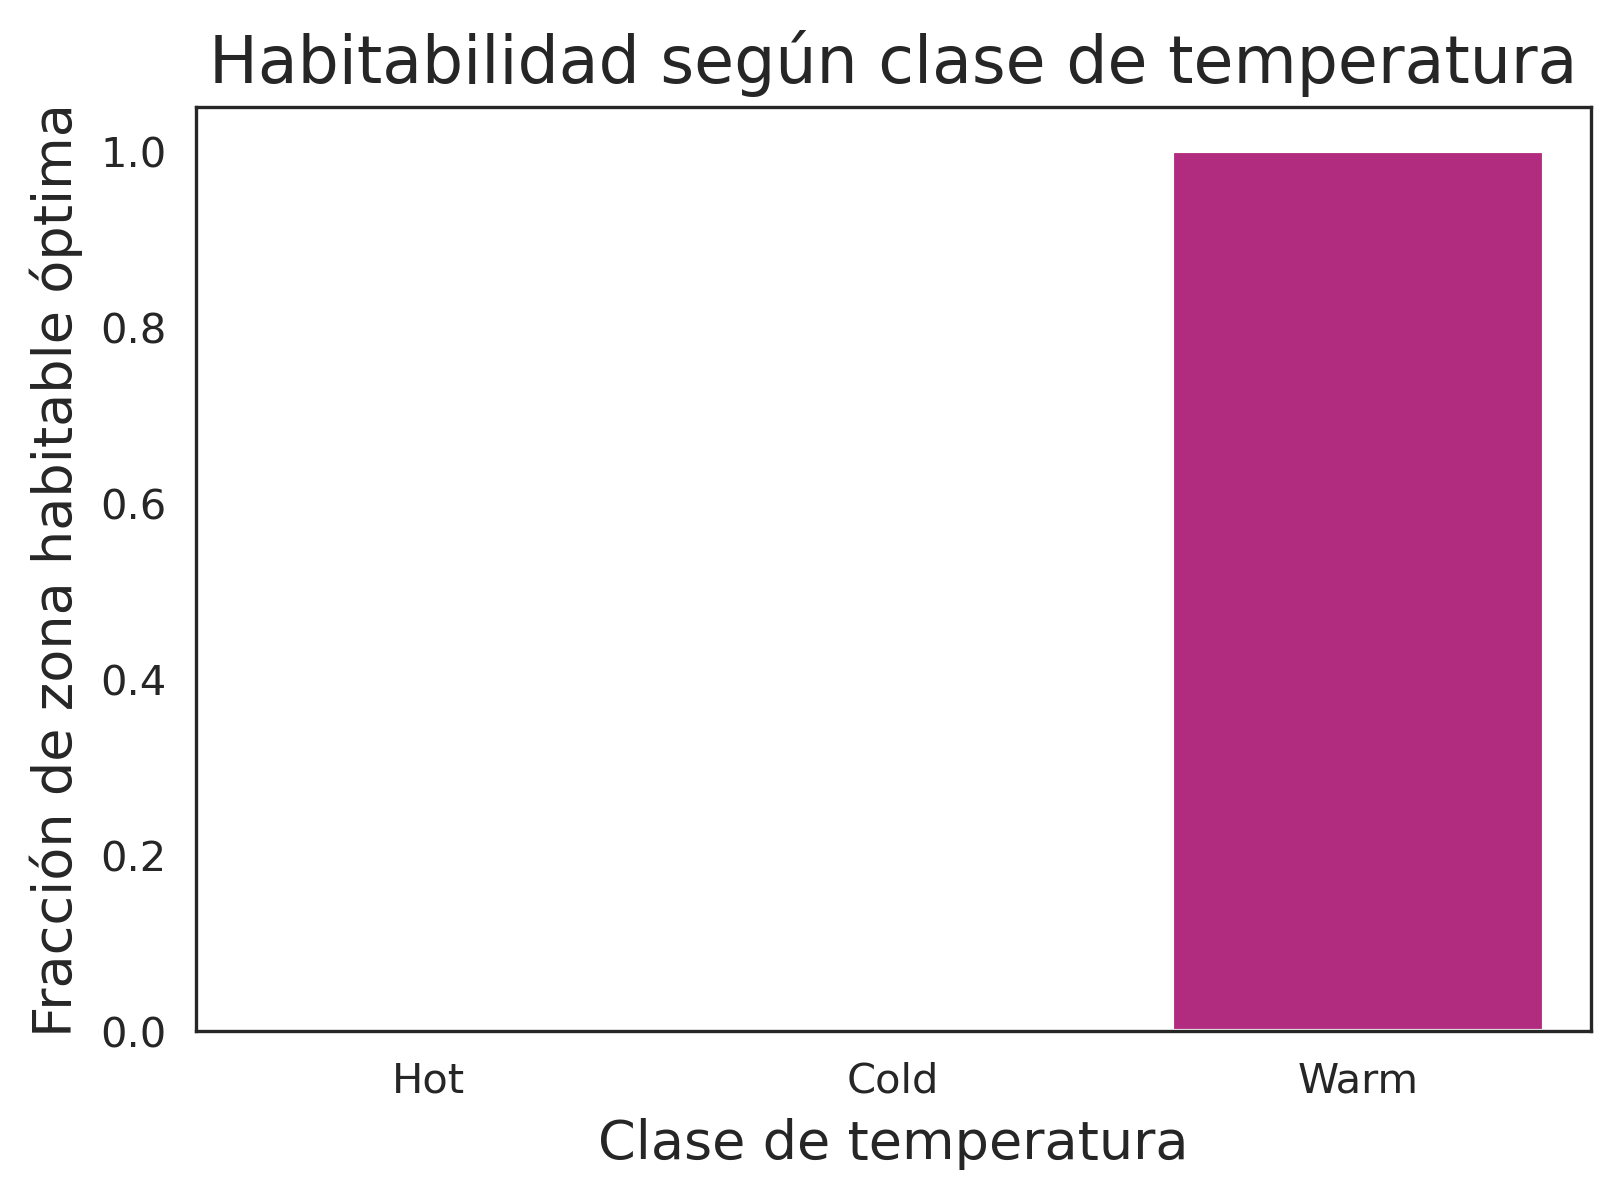

In [54]:
#Habitabilidad según clase de temperatura
plt.figure(figsize=(6,4))
sns.barplot(data=EXO_set, x="P_TYPE_TEMP", y="P_HABZONE_OPT", errorbar=None, color='mediumvioletred')
plt.xlabel("Clase de temperatura")
plt.ylabel("Fracción de zona habitable óptima")
plt.title("Habitabilidad según clase de temperatura")
plt.ylim(0,1.05)
plt.show()


### Preguntas

- La fracción de supervivencia es similar para clase cualitativa de temperatura (hot,cold,warm)? No, no es similar, la fracción de supervivencia es mayor para los exoplanetas considerados como warm.
- Podemos concluir a partir de este gráfico por qué existe la diferencia?
No se puede concluir sólo del gráfico. Aunque uno tiene en cuenta por ser el exoplaneta clasificado tibio que se puede habitar, pero por datos no se puede concluir aún.

### Ahora usted

**1. Explorando la habitabilidad según `Tipo de exoplaneta`.**

- Hay diferencias entre los tipos de exoplanetas? Sí, si hay diferencias.
- Existe una tendencia? La tendencia de habitabilidad presente tiende a ser mayor para los exoplanetas Jovian, luego para los Neptunian y posteriormente para los Superterran, Terran, SubTerran y miniterran con 0 fracción de habitabilidad.


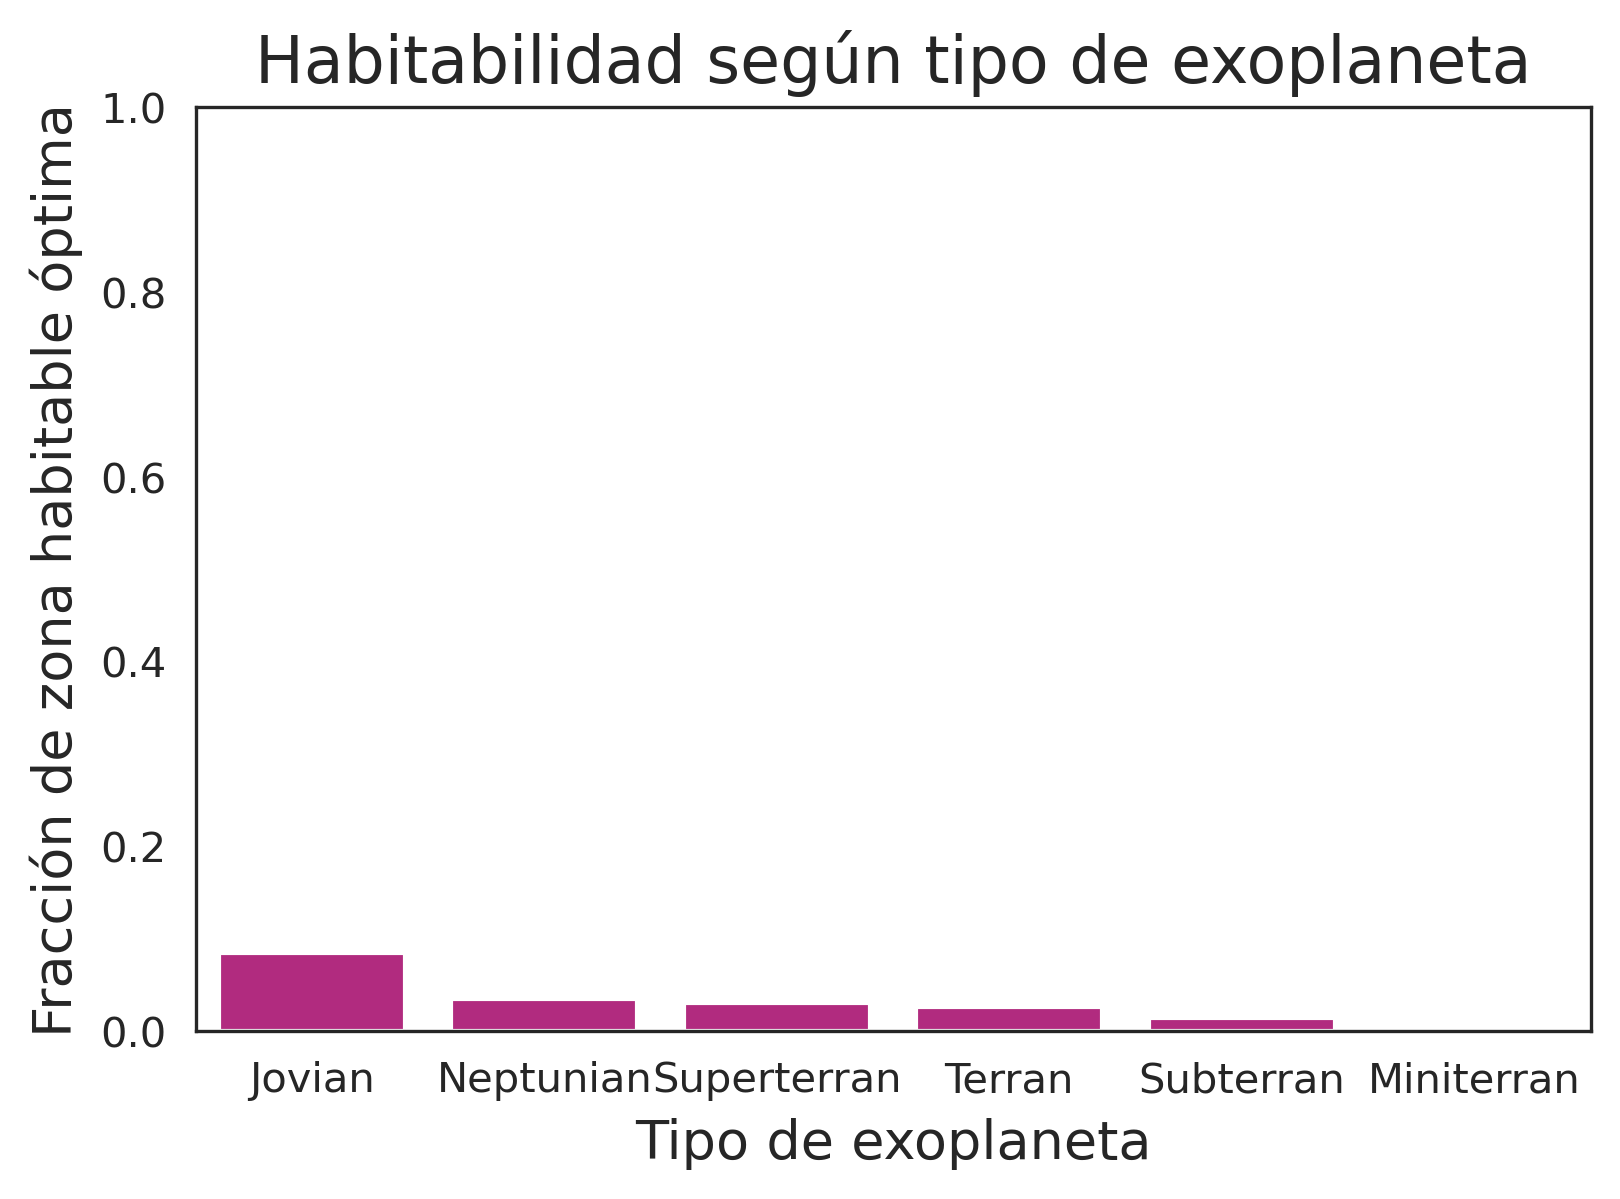

In [55]:
#Habitabilidad según tipo de exoplaneta
plt.figure(figsize=(6,4))
sns.barplot(data=EXO_set, x="P_TYPE", y="P_HABZONE_OPT", errorbar=None, color='mediumvioletred')
plt.xlabel("Tipo de exoplaneta")
plt.ylabel("Fracción de zona habitable óptima")
plt.title("Habitabilidad según tipo de exoplaneta")
plt.ylim(0,1)
plt.show()

**2. Explore la supervivencia según Temperatura superficial (cuantitativo).**

Se pueden comparar las distribuciones de temperaturas a partir de rangos de los exoplanetas que pueden ser o no ser habitables.

- La temperatura parece estar asociada con la habitabilidad? Sí, se nota claramente una asociación entre temperatura superficial del exoplaneta y su fracción de habitabilidad. Desde rangos 0 K a alrededor de 150 K no tienen muestra de ser habitables, mientras que los exoplanetas empiezan a tener tendencia de habitabilidad de alrededor 18% para 150 a 200 K, 200-250 K y 250-300 K tienen tendencia de habitabilidad de 95% y 100%, prácticamente super óptimos para ser habitables lo que confirma lo visto más arriba, en donde se encontraron exoplanetas clasificados como warm que tenían temperaturas en rango 200 a 300 K, y por otra parte para temperaturas de 300 a 350 K el porcentaje de habitabilidad es alrededor del 33%.

- Hay algún grupo de temperatura que llame particularmente la atención? Quizás las temperaturas bien bajas o muy altas, que claramente no tienen fracción de habitabilidad, lo que igual se asocia incluso sin tener un gráfico.


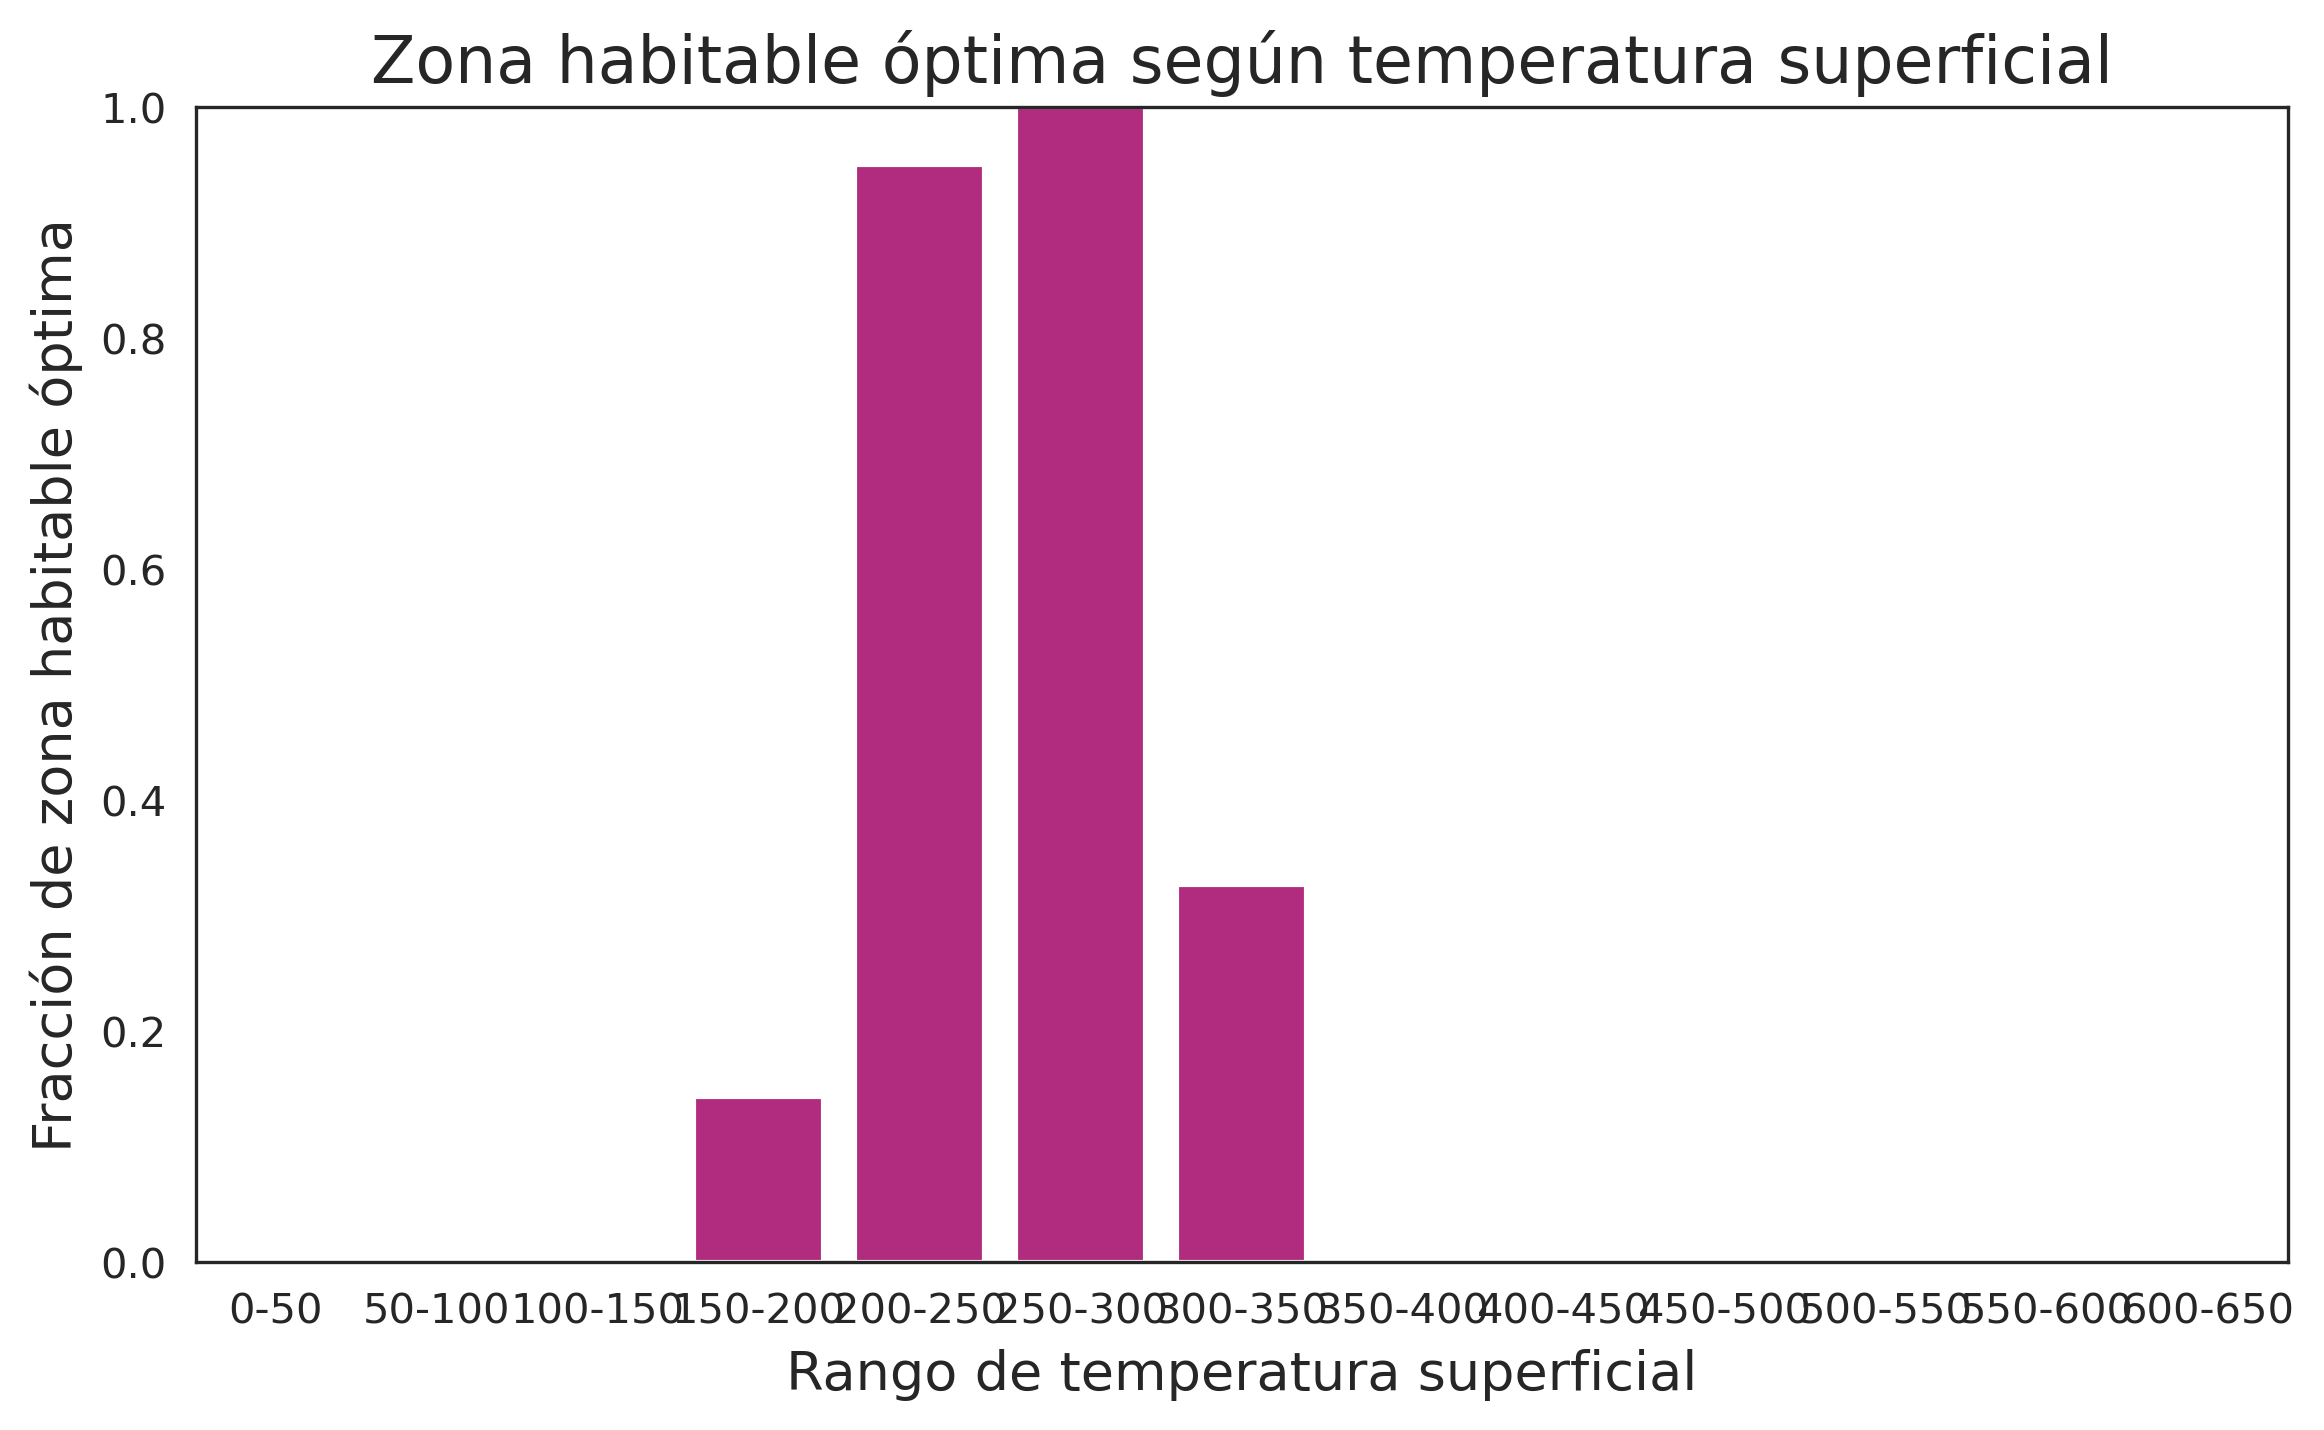

In [56]:
#Zona habitable óptima según temperatura superficial
bins = [0, 50,100, 150, 200, 250,300,350,400,450,500,550,600,650]
#los rangos se vieron de manera que ya no quedaran rangos con valores, puesto que por ejemplo más allá de 650 K ya no hay clasificados exoplanetas
rangos = ["0-50", "50-100","100-150","150-200","200-250", "250-300", "300-350","350-400","400-450","450-500","500-550","550-600","600-650"]
#esto ayuda a agrupar por rangos de temperatura
EXO_set["TEMPERATUREEEE"] = pd.cut(EXO_set["P_TEMP_SURF"],bins=bins,labels=rangos)
plt.figure(figsize=(9, 5))
sns.barplot(data=EXO_set,x="TEMPERATUREEEE",y="P_HABZONE_OPT",color='mediumvioletred',errorbar=None)
plt.xlabel("Rango de temperatura superficial")
plt.ylabel("Fracción de zona habitable óptima")
plt.title("Zona habitable óptima según temperatura superficial")
plt.ylim(0, 1)
plt.show()

**3. Explore la habitabilidad según distancia del exoplaneta a su Sol.**

- Hay distancias que se puedan considerar favorables o desfavorables? En general diría que no hay distancias realmente favorables, puesto que para todos los rangos de distancias la fracción de supervivencia es menor al 30%.
- La relación parece simple? Quizás no, puesto que igual se podría pensar que justamente hay una distancia óptima aprox con más del 50% de posibilidad de ser habitable.
- Qué ocurre con los distancias en UA más grandes? En realidad es variable la fracción de supervivencia pero no óptima/favorable. 

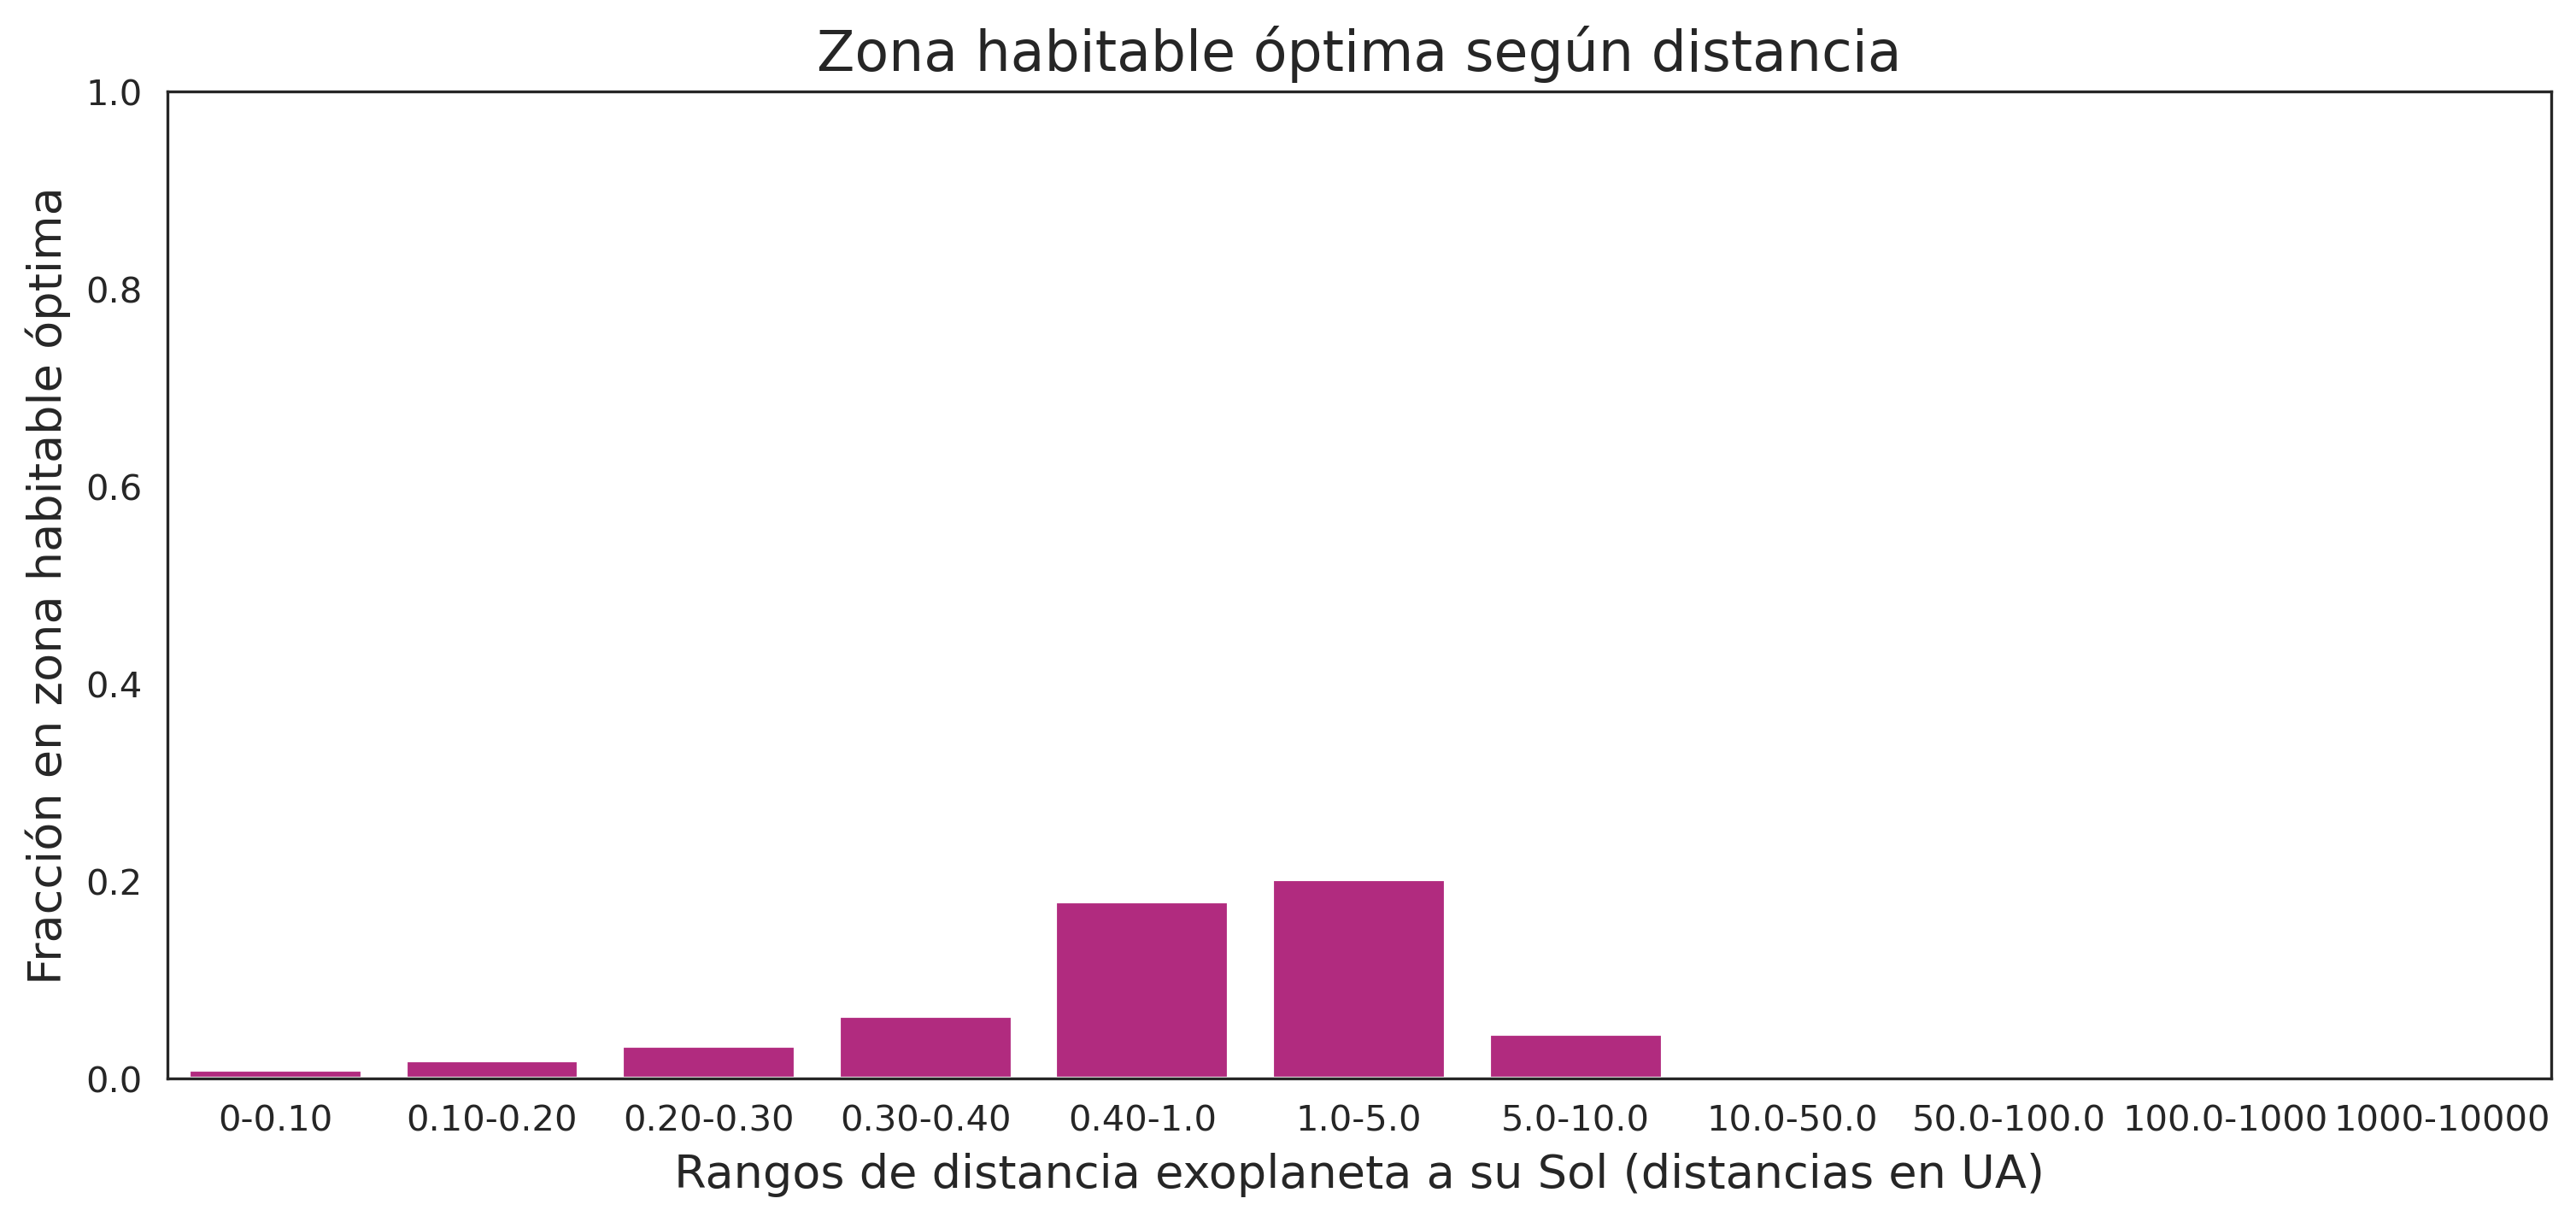

In [57]:
bins = [0,0.1,0.2,0.3,0.4,1,5,10,50,100,1000,10000]
rangos = ["0-0.10","0.10-0.20","0.20-0.30","0.30-0.40","0.40-1.0","1.0-5.0","5.0-10.0","10.0-50.0","50.0-100.0","100.0-1000","1000-10000"]
# Agrupar por rangos de temperatura
EXO_set["PPPP"] = pd.cut(EXO_set["P_DISTANCE"],bins=bins,labels=rangos)
plt.figure(figsize=(12, 5))
sns.barplot(data=EXO_set, x="PPPP",y="P_HABZONE_OPT",color='mediumvioletred',errorbar=None)
plt.xlabel("Rangos de distancia exoplaneta a su Sol (distancias en UA)")
plt.ylabel("Fracción en zona habitable óptima")
plt.title("Zona habitable óptima según distancia")
plt.ylim(0, 1)
plt.show()

<h2 style="color:fuchsia; font-family:; text-align:center;font-size:17px">
  P_ESI (como  Earth Similarity Index, o estilo Earth-Alike)
</h2>

### Ejemplo de gráfico: exoplanetas similares a la Tierra representados por un factor donde si P_ESI > 0.5 se considera potencialmente habitable (porque tendría más del 50% características que tiene la Tierra), según clase de temperatura.


Nota importante: El hecho de que para un P_ESI > 0.5 se considere potencialmente habitable, no es siempre verdad!! porque desde el medio donde se extrajo a tabla, el criterio de habitabilidad es independiente del ESI. Además, existen otros factores debido a que se estaría viendo si es que los exoplanetas que se asimilan a la Tierra tienen o radio o distancia a su Sol, temperatura superficial, si es que tiene agua líquida, etc. Aquello es ambiguo, uno lo supone porque uno investiga sobre eso, pero de los gráficos no se otorga esa información. Aquello sirve como investigación futura como planteamiento de otro problema de ML.

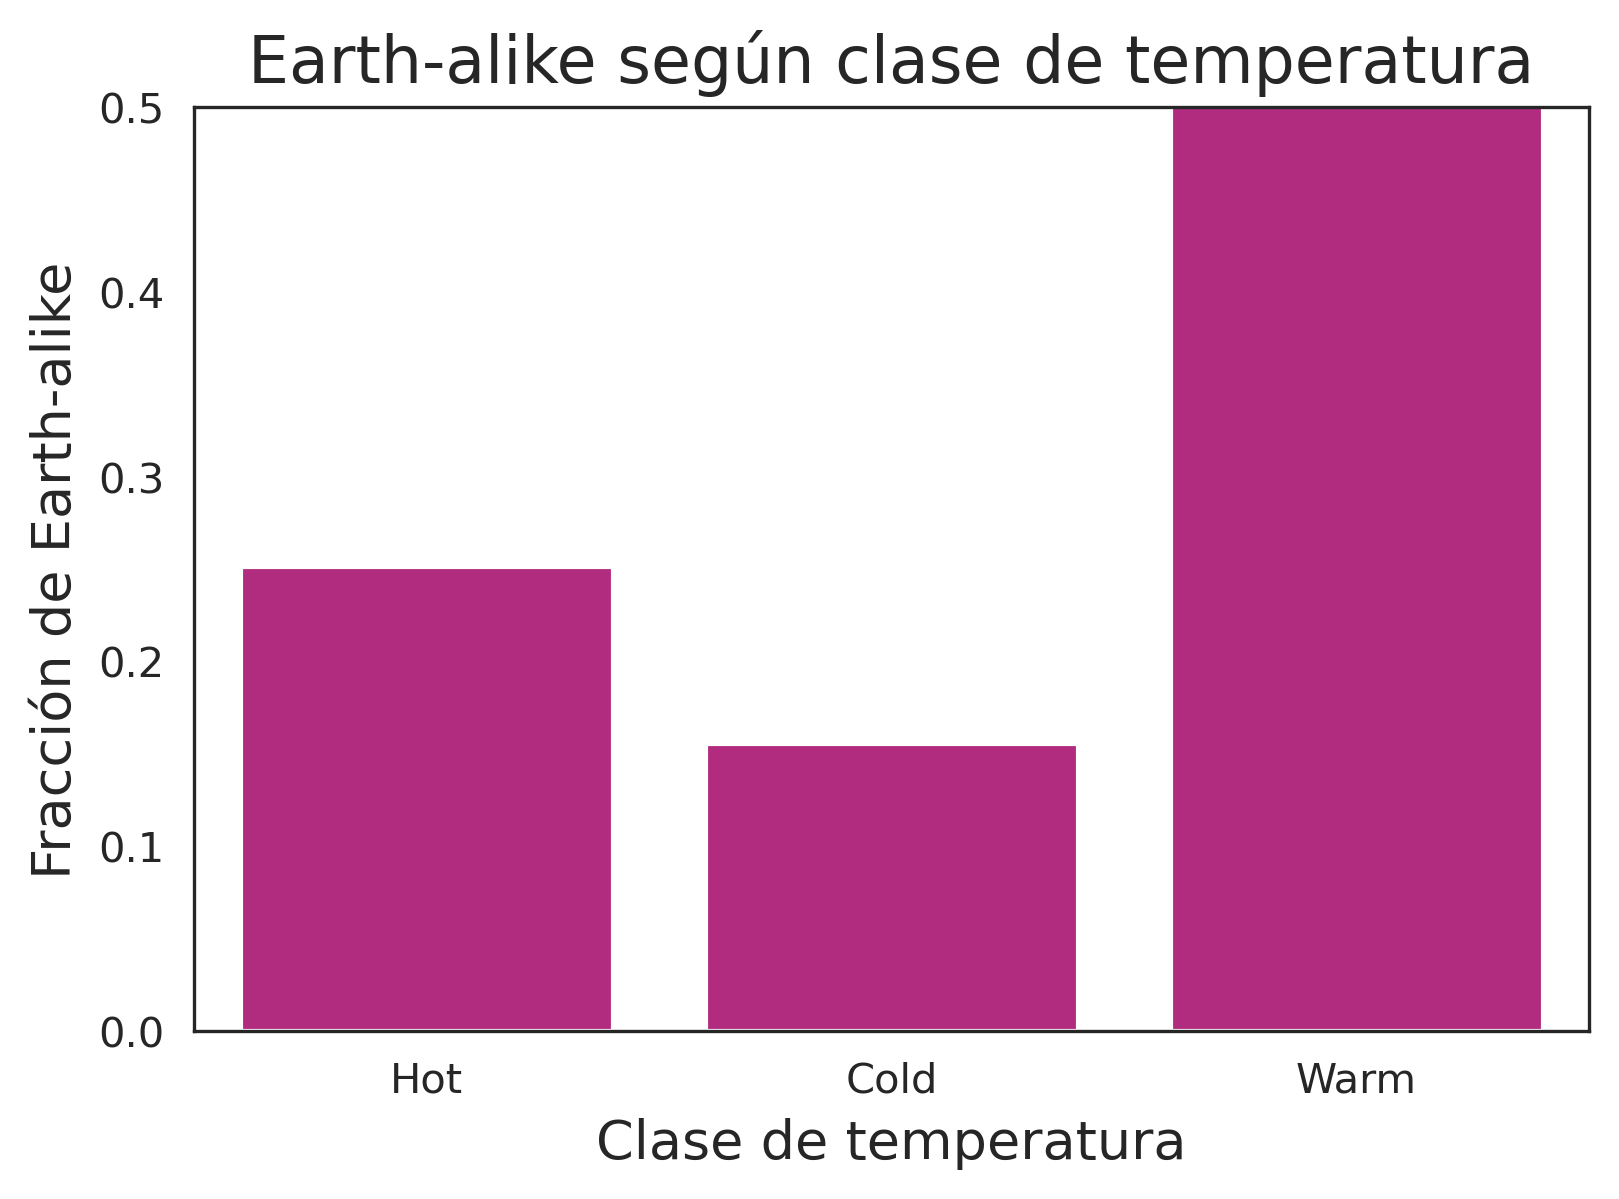

In [58]:
#Habitabilidad según clase de temperatura
plt.figure(figsize=(6,4))
sns.barplot(data=EXO_set, x="P_TYPE_TEMP", y="P_ESI", errorbar=None, color='mediumvioletred')
plt.xlabel("Clase de temperatura")
plt.ylabel("Fracción de Earth-alike")
plt.title("Earth-alike según clase de temperatura")
plt.ylim(0,0.5)
plt.show()

- Cómo se distribuyen las fracciones de earth-alike para los exoplanetas según clase de temperatura? Se distribuyen variadamente, por ejemplo para los exoplanetas clasificados como Hot tienen características parecidas a la de la Tierra en alrededor un 25%, para los exoplanetas como Cold tienen alrededor de 15% similitudes con la Tierra y para los exoplanetas Warm alcanzan 50% del índice de similitud con la Tierra

- Existen diferencias en relación con la habitabilidad netamente? Sí, claramente hay diferencias puesto que para la habitabilidad

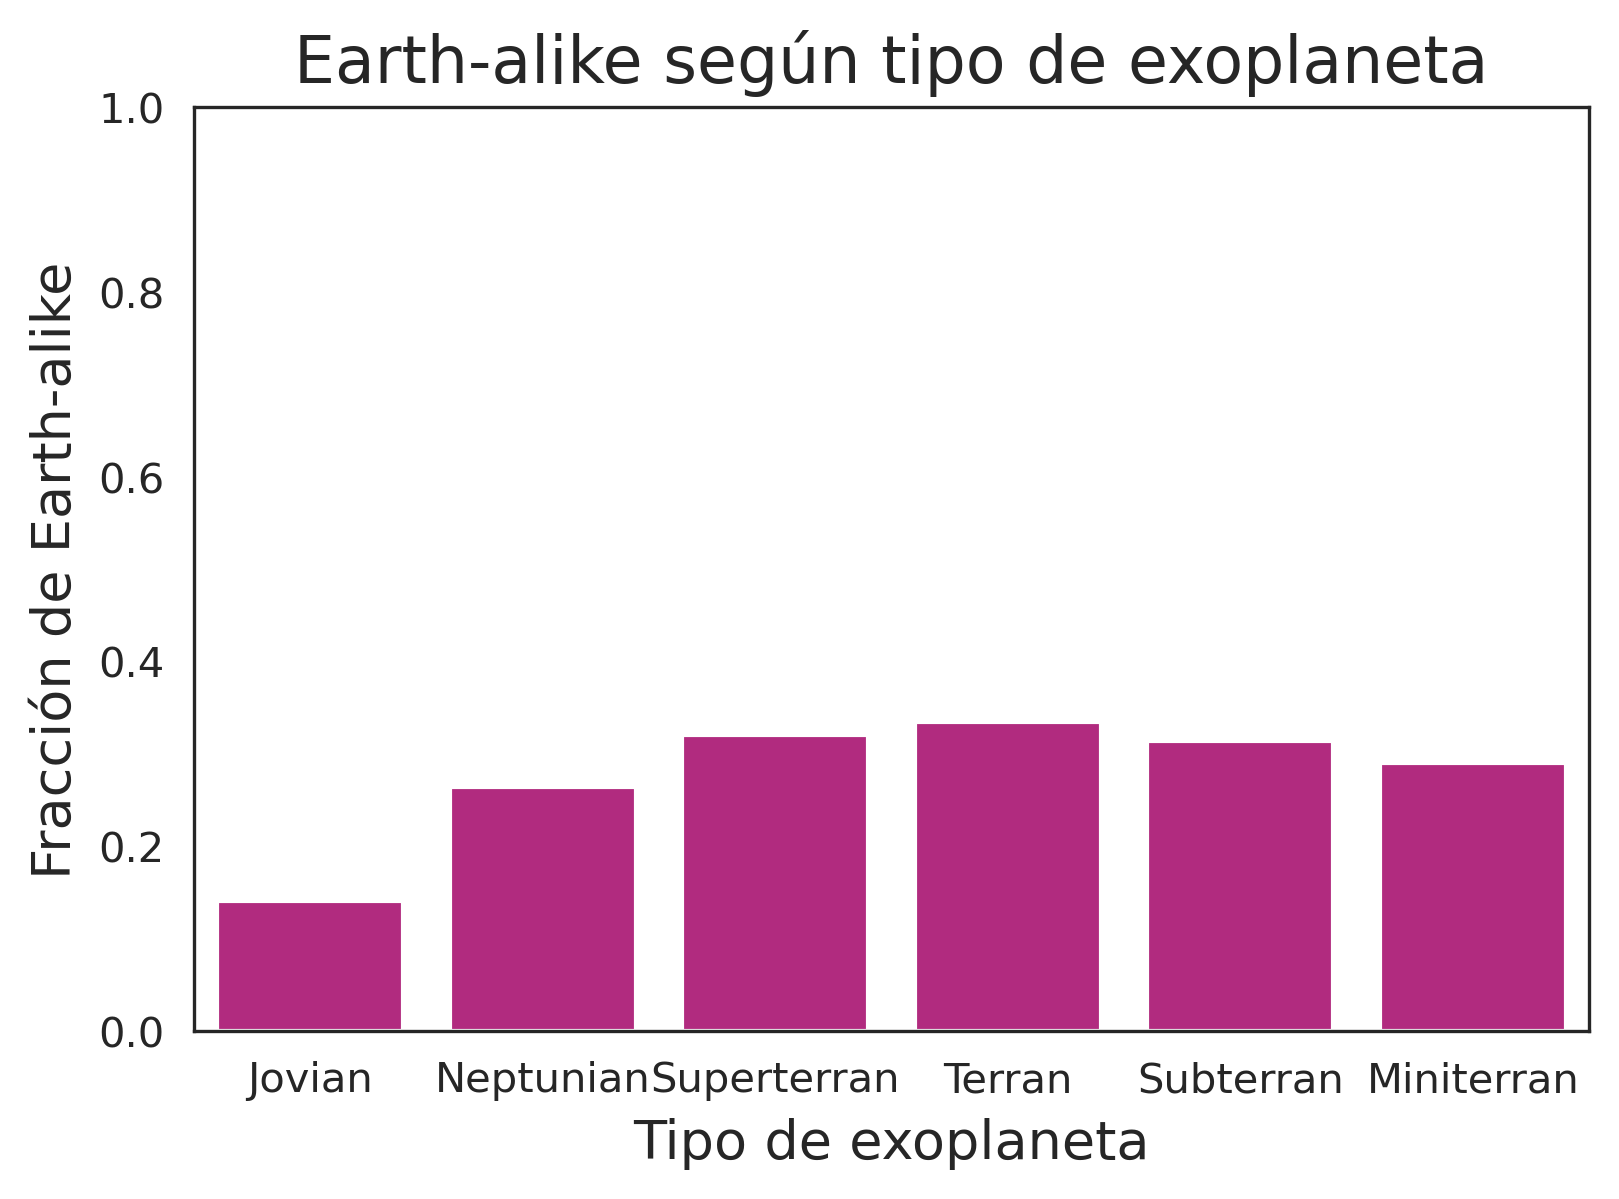

In [59]:
plt.figure(figsize=(6,4))
sns.barplot(data=EXO_set, x="P_TYPE", y="P_ESI", errorbar=None, color='mediumvioletred')
plt.xlabel("Tipo de exoplaneta")
plt.ylabel("Fracción de Earth-alike")
plt.title("Earth-alike según tipo de exoplaneta")
plt.ylim(0,1)
plt.show()

- Cómo se distribuyen las fracciones de earth-alike para los exoplanetas según clase de exoplaneta? Se distribuyen variadamente, donde los Terran tienen un mayor porcentaje de earth-alike respecto a los otros tipos, pero ninguno claramente alcanza a ser ni el 40% similar a la Tierra.

- Existen diferencias en relación con la habitabilidad netamente? Sí, claramente hay diferencias puesto que para la habitabilidad, los jovian tienen un mayor porcentaje que las otras con respecto a que se encuentre en una zona habitable relativamente óptima pero de igual forma no alcanza el 50%, por ejemplo, en cambio usando el ESI, el jovian es el que menos tiene similitud con la Tierra.

- Podrían representar entre ESI y zona de habitabilidad óptima lo mismo? No, los ESI son los similares a la Tierra asociado con un potencial para ser habitable, pero la zona óptima es el lugar localizado que podría permitir o dar lugar a que el exoplaneta sea potencialmente habitable. Si un exoplaneta se pareciera más a la Tierra no significa que tenga un índice de habitabilidad mayor, y viceversa, ahí se tienen que ver otros factores, como las temperaturas.

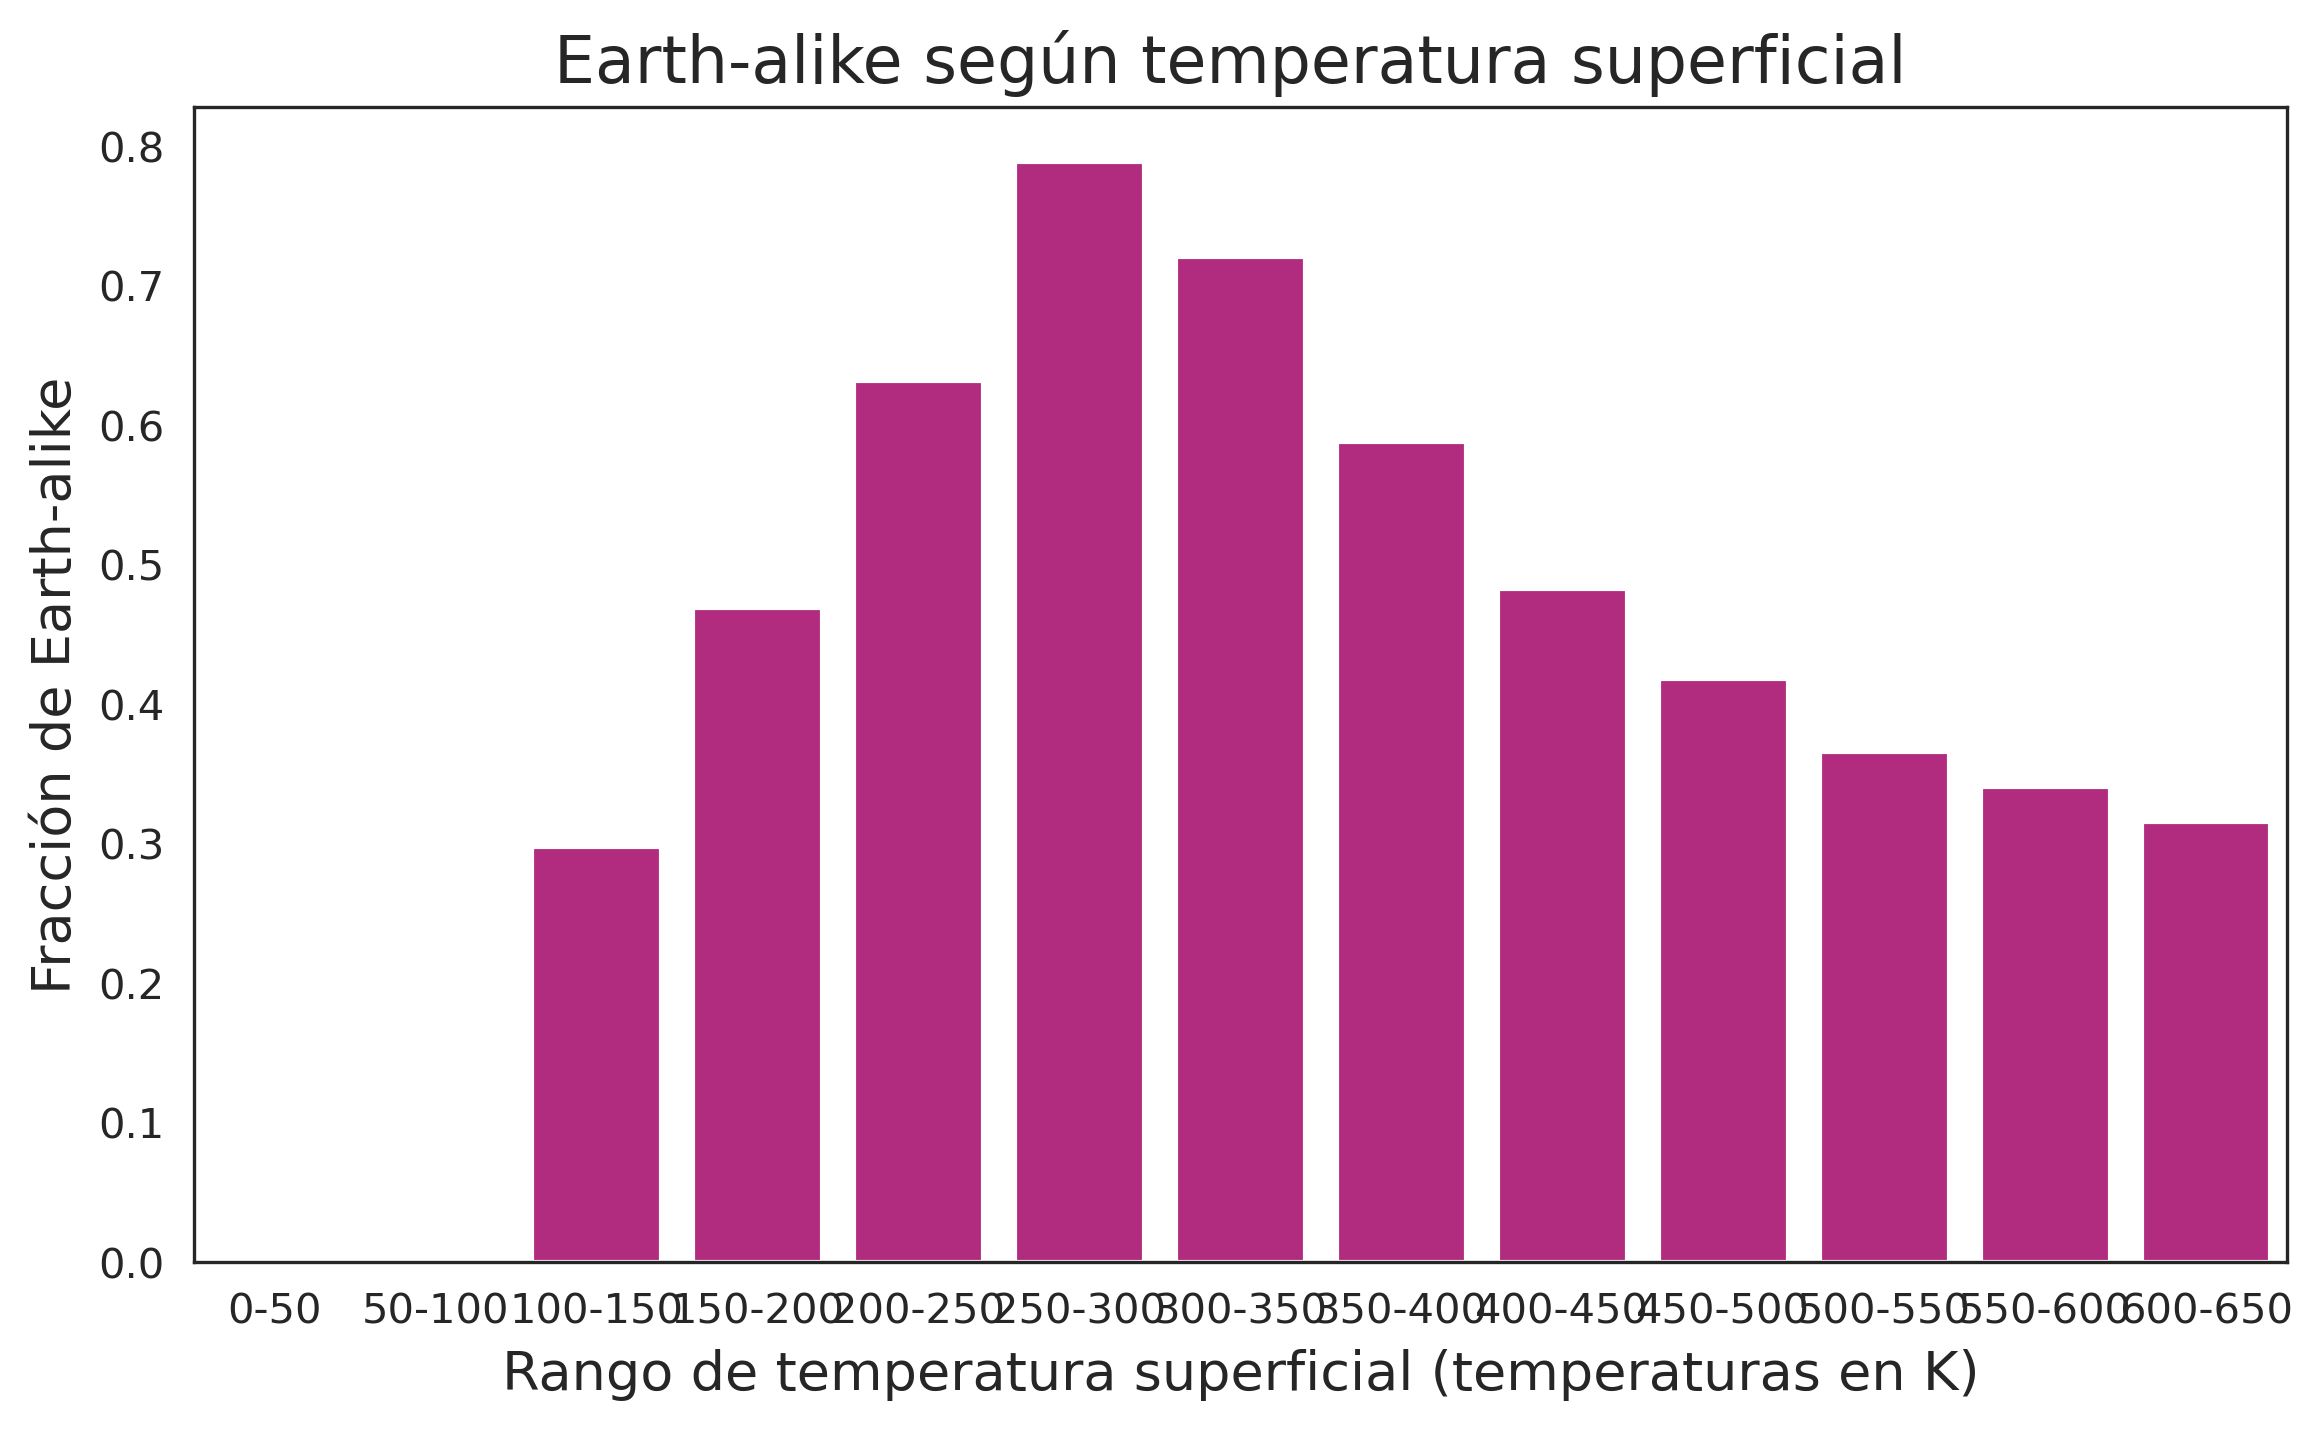

In [60]:
bins = [0, 50,100, 150, 200, 250,300,350,400,450,500,550,600,650]
#para poder hacer comparaciones con los de zona de habitabilidad se considero el mismo rango
rangos = ["0-50", "50-100","100-150","150-200","200-250", "250-300", "300-350","350-400","400-450","450-500","500-550","550-600","600-650"]
#esto ayuda a agrupar por rangos de temperatura
EXO_set["TEMPERATUREEEE"] = pd.cut(EXO_set["P_TEMP_SURF"],bins=bins,labels=rangos)
plt.figure(figsize=(9, 5))
sns.barplot(data=EXO_set,x="TEMPERATUREEEE",y="P_ESI",color='mediumvioletred',errorbar=None)
plt.xlabel("Rango de temperatura superficial (temperaturas en K)")
plt.ylabel("Fracción de Earth-alike")
plt.title("Earth-alike según temperatura superficial ")
#plt.ylim(0, 1)
plt.show()

- Cómo se distribuyen las fracciones de earth-alike para los exoplanetas según rangos de temperatura superficial? También se distribuyen variadamente, donde como se había encontrado en secciones anteriores, para temperaturas entre 250 a 300 K (un rango más ajustado) el factor de Earth-alike es alrededor del 80%, lo que también ocurre respecto a la zona óptima de habitabilidad donde ese rango tiene un 100%. En cambio para rangos pequeños la fracción es mucho menor o nada, y para rangos mayores al mencionado también va disminuyendo pero el hecho de que tenga valores hace un poco de "ruido", pero eso es porque falta más que considerar solo el factor ESI. 

- Existen diferencias en relación con la habitabilidad netamente? Sí, especialmente para valores de temperaturas menores y mayores que el rango 250-300 K, donde se está encontrando que ese es bastante óptimo.

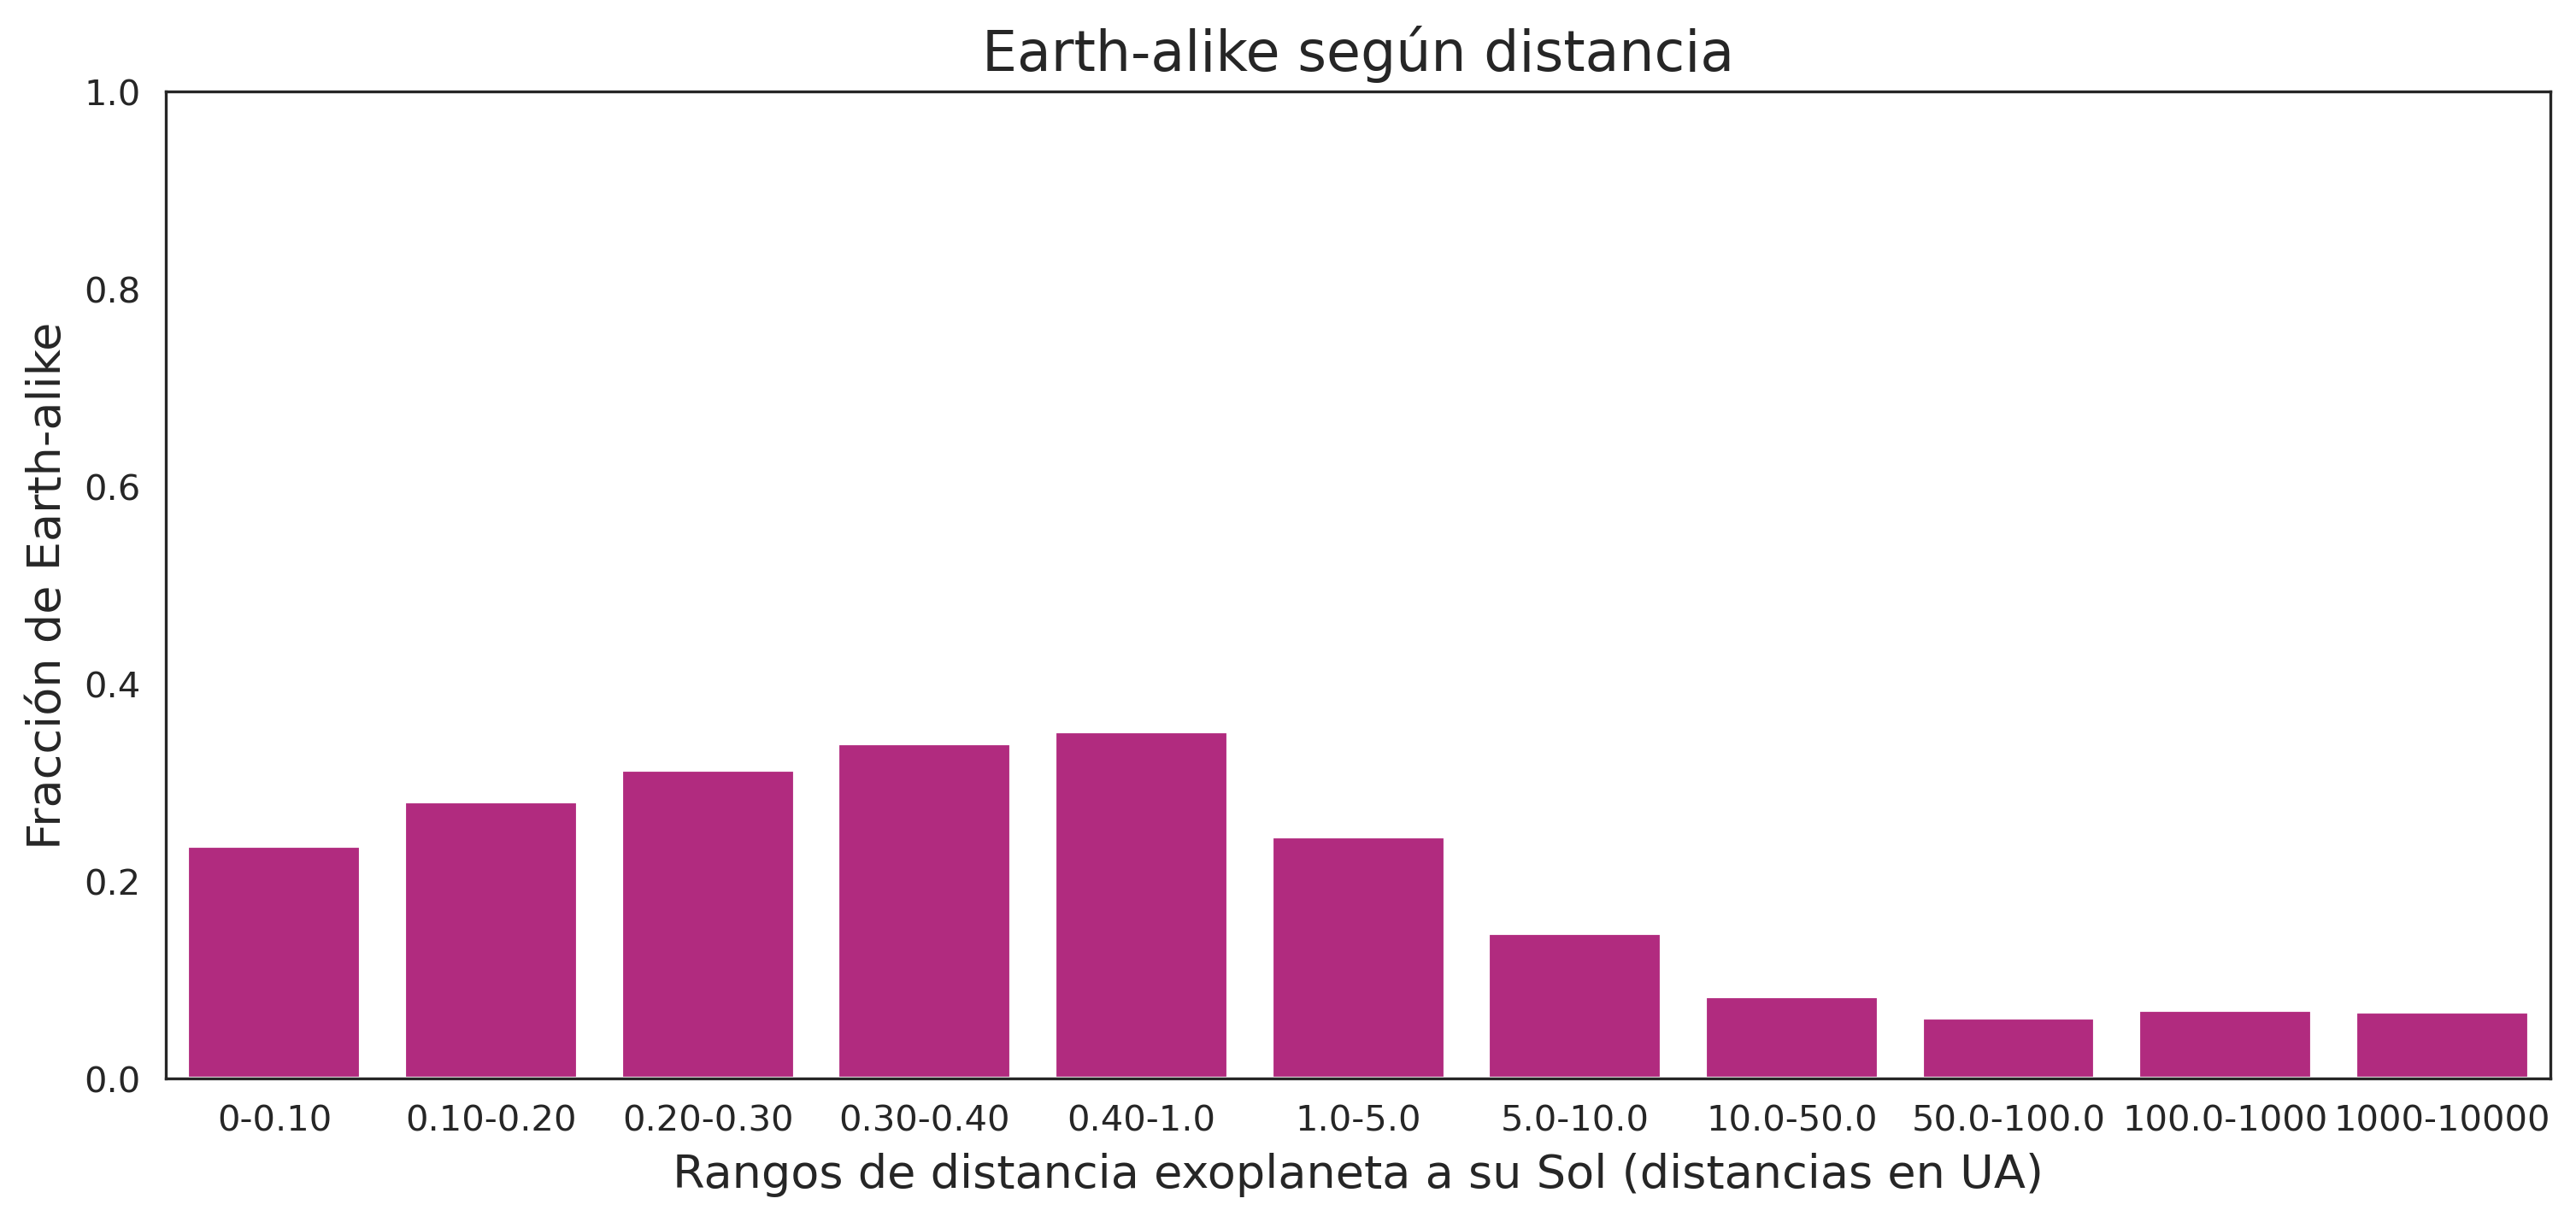

In [61]:
bins = [0,0.1,0.2,0.3,0.4,1,5,10,50,100,1000,10000]
rangos = ["0-0.10","0.10-0.20","0.20-0.30","0.30-0.40","0.40-1.0","1.0-5.0","5.0-10.0","10.0-50.0","50.0-100.0","100.0-1000","1000-10000"]
# Agrupar por rangos de temperatura
EXO_set["PPPP"] = pd.cut(EXO_set["P_DISTANCE"],bins=bins,labels=rangos)
plt.figure(figsize=(12, 5))
sns.barplot(data=EXO_set, x="PPPP",y="P_ESI",color='mediumvioletred',errorbar=None)
plt.xlabel("Rangos de distancia exoplaneta a su Sol (distancias en UA)")
plt.ylabel("Fracción de Earth-alike")
plt.title("Earth-alike según distancia")
plt.ylim(0, 1)
plt.show()

- Cómo se distribuyen las fracciones de earth-alike para los exoplanetas según rangos de distancias ? También se distribuyen variadamente, siendo que hay exoplanetas que se encuentran a distancias entre 0.4 y 1 UA con fracción mayor que otros rangos con respecto a ser similar a la Tierra, pero no alcanza ni el 40%.

- Existen diferencias en relación con la zona de habitabilidad netamente? Sí, porque para ese caso el rango 1.0 a 5.0 UA tiene más porcentaje, siendo la distancias óptimas para que el exoplaneta sea habitable, pero no así para la relación earth-alike, aquí es 0.40 a 1.0 UA, donde los exoplanetas tienen más parecido a la Tierra, pero de igual forma como no se alcanza el 40% no es posible concluir del todo en realidad.

<h2 style="color:#BA55D3; font-family:; text-align:center;font-size:20px">
  Agregar contexto
</h2>
# ¿Cambia una relación cuando consideramos otra característica?

Una relación global puede esconder comportamientos diferentes dentro de la muestra. Para ello se investiga entre otras relaciones agregando contexto, pero aquello se realiza en base a la zona óptima de habitabilidad, no para el factor P_ESI, puesto que no siempre será verdad ese factor en relación con el potencial para ser habitable.
Ya estudiamos por separado:

- `P_DISTANCE` y zona óptima de habitabilidad
- `clase de temperatura` y zona óptima de habitabilidad
- `clase de exoplaneta` y zona óptima de habitabilidad
- `temperatura superficial` y zona óptima de habitabilidad

Ahora podemos preguntar:
 **¿La relación entre temperatura superficial y clase es igual para las distintas clases de exoplanetas?**

Esta es una forma sencilla de análisis multivariado: consideramos varias características al mismo tiempo.


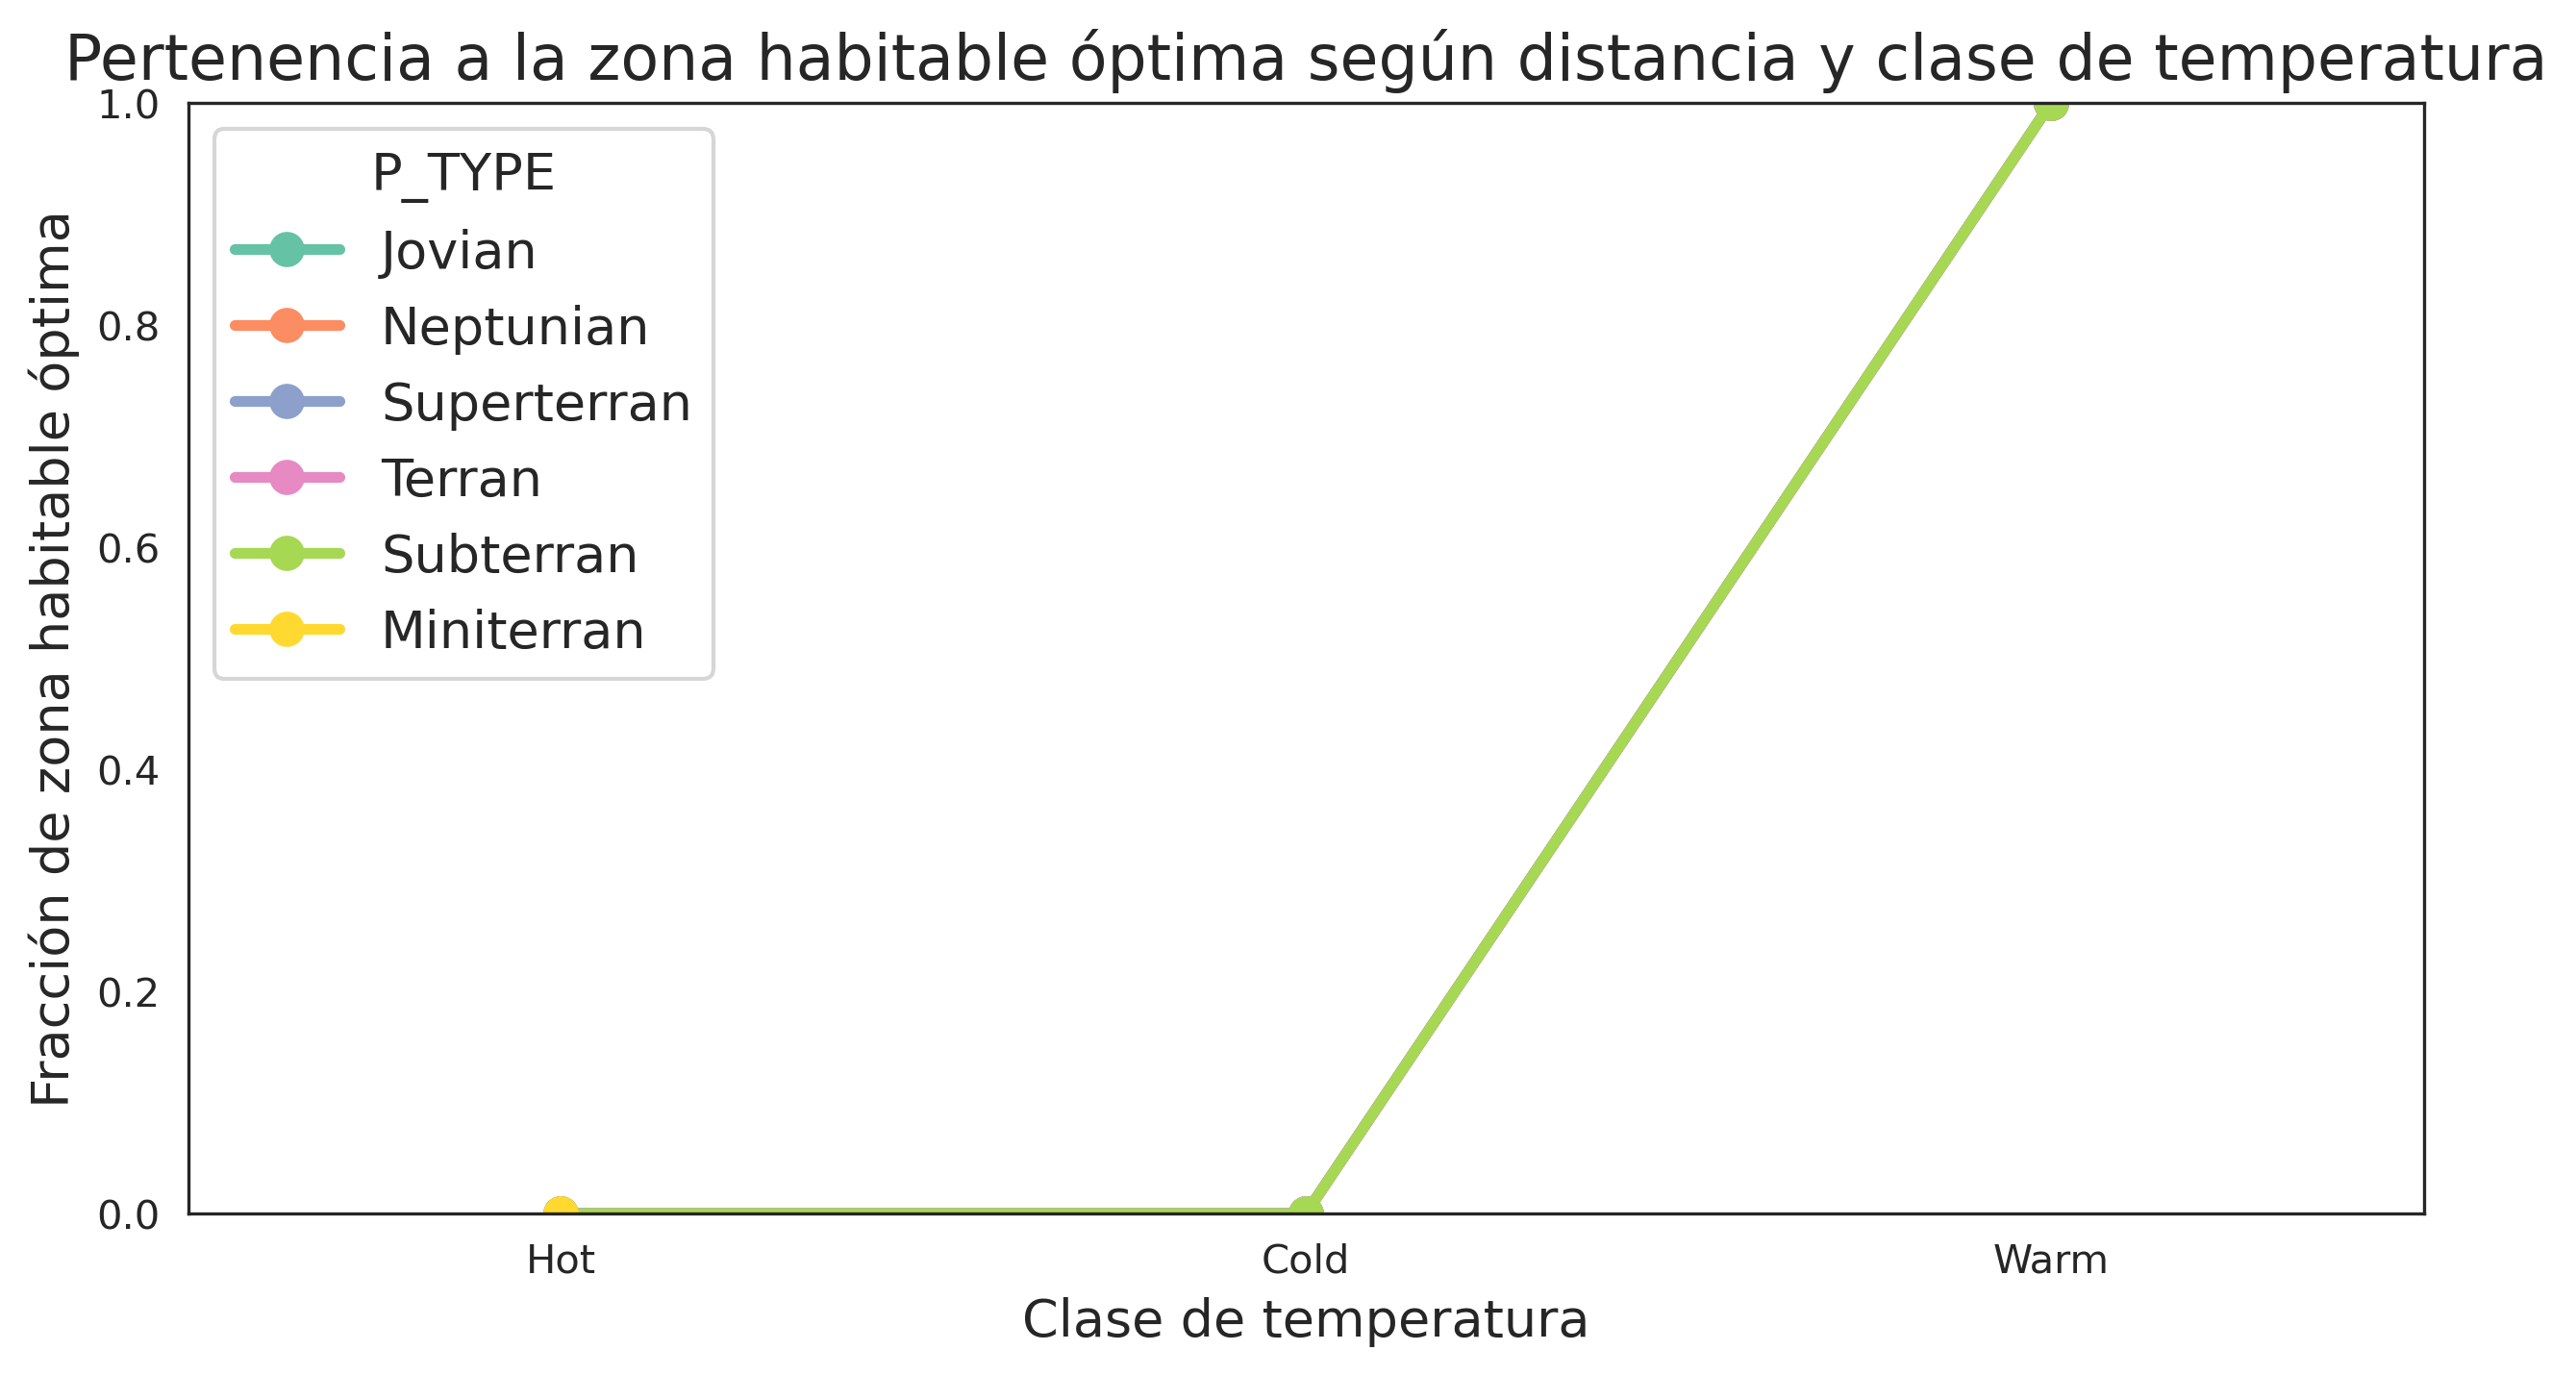

In [62]:
plt.figure(figsize=(10,5))
sns.pointplot(data=EXO_set,x="P_TYPE_TEMP",y="P_HABZONE_OPT",hue="P_TYPE",palette="Set2",errorbar=None)
plt.xlabel("Clase de temperatura")
plt.ylabel("Fracción de zona habitable óptima")
plt.title("Pertenencia a la zona habitable óptima según distancia y clase de temperatura")
plt.ylim(0,1.0)
plt.show()

**2. Explorando la fracción de zona de habitabilidad según tipo de exoplaneta y clase de temperatura.**

- La relación entre clase de temperatura y fracción de zona de habitabilidad óptima es igual para los tipos de exoplanetas? No, no es igual. Para la clase Hot y Cold se tiene que los tipos de exoplanetas no están en zonas habitables, mientras que para warm sí.
- Hay algún grupo particularmente favorecido o desfavorecido? En este caso, por mientras todos los tipos de exoplanetas están favorecidos para la clase warm, encontrándose en una zona óptima de habitabilidad en un 100%

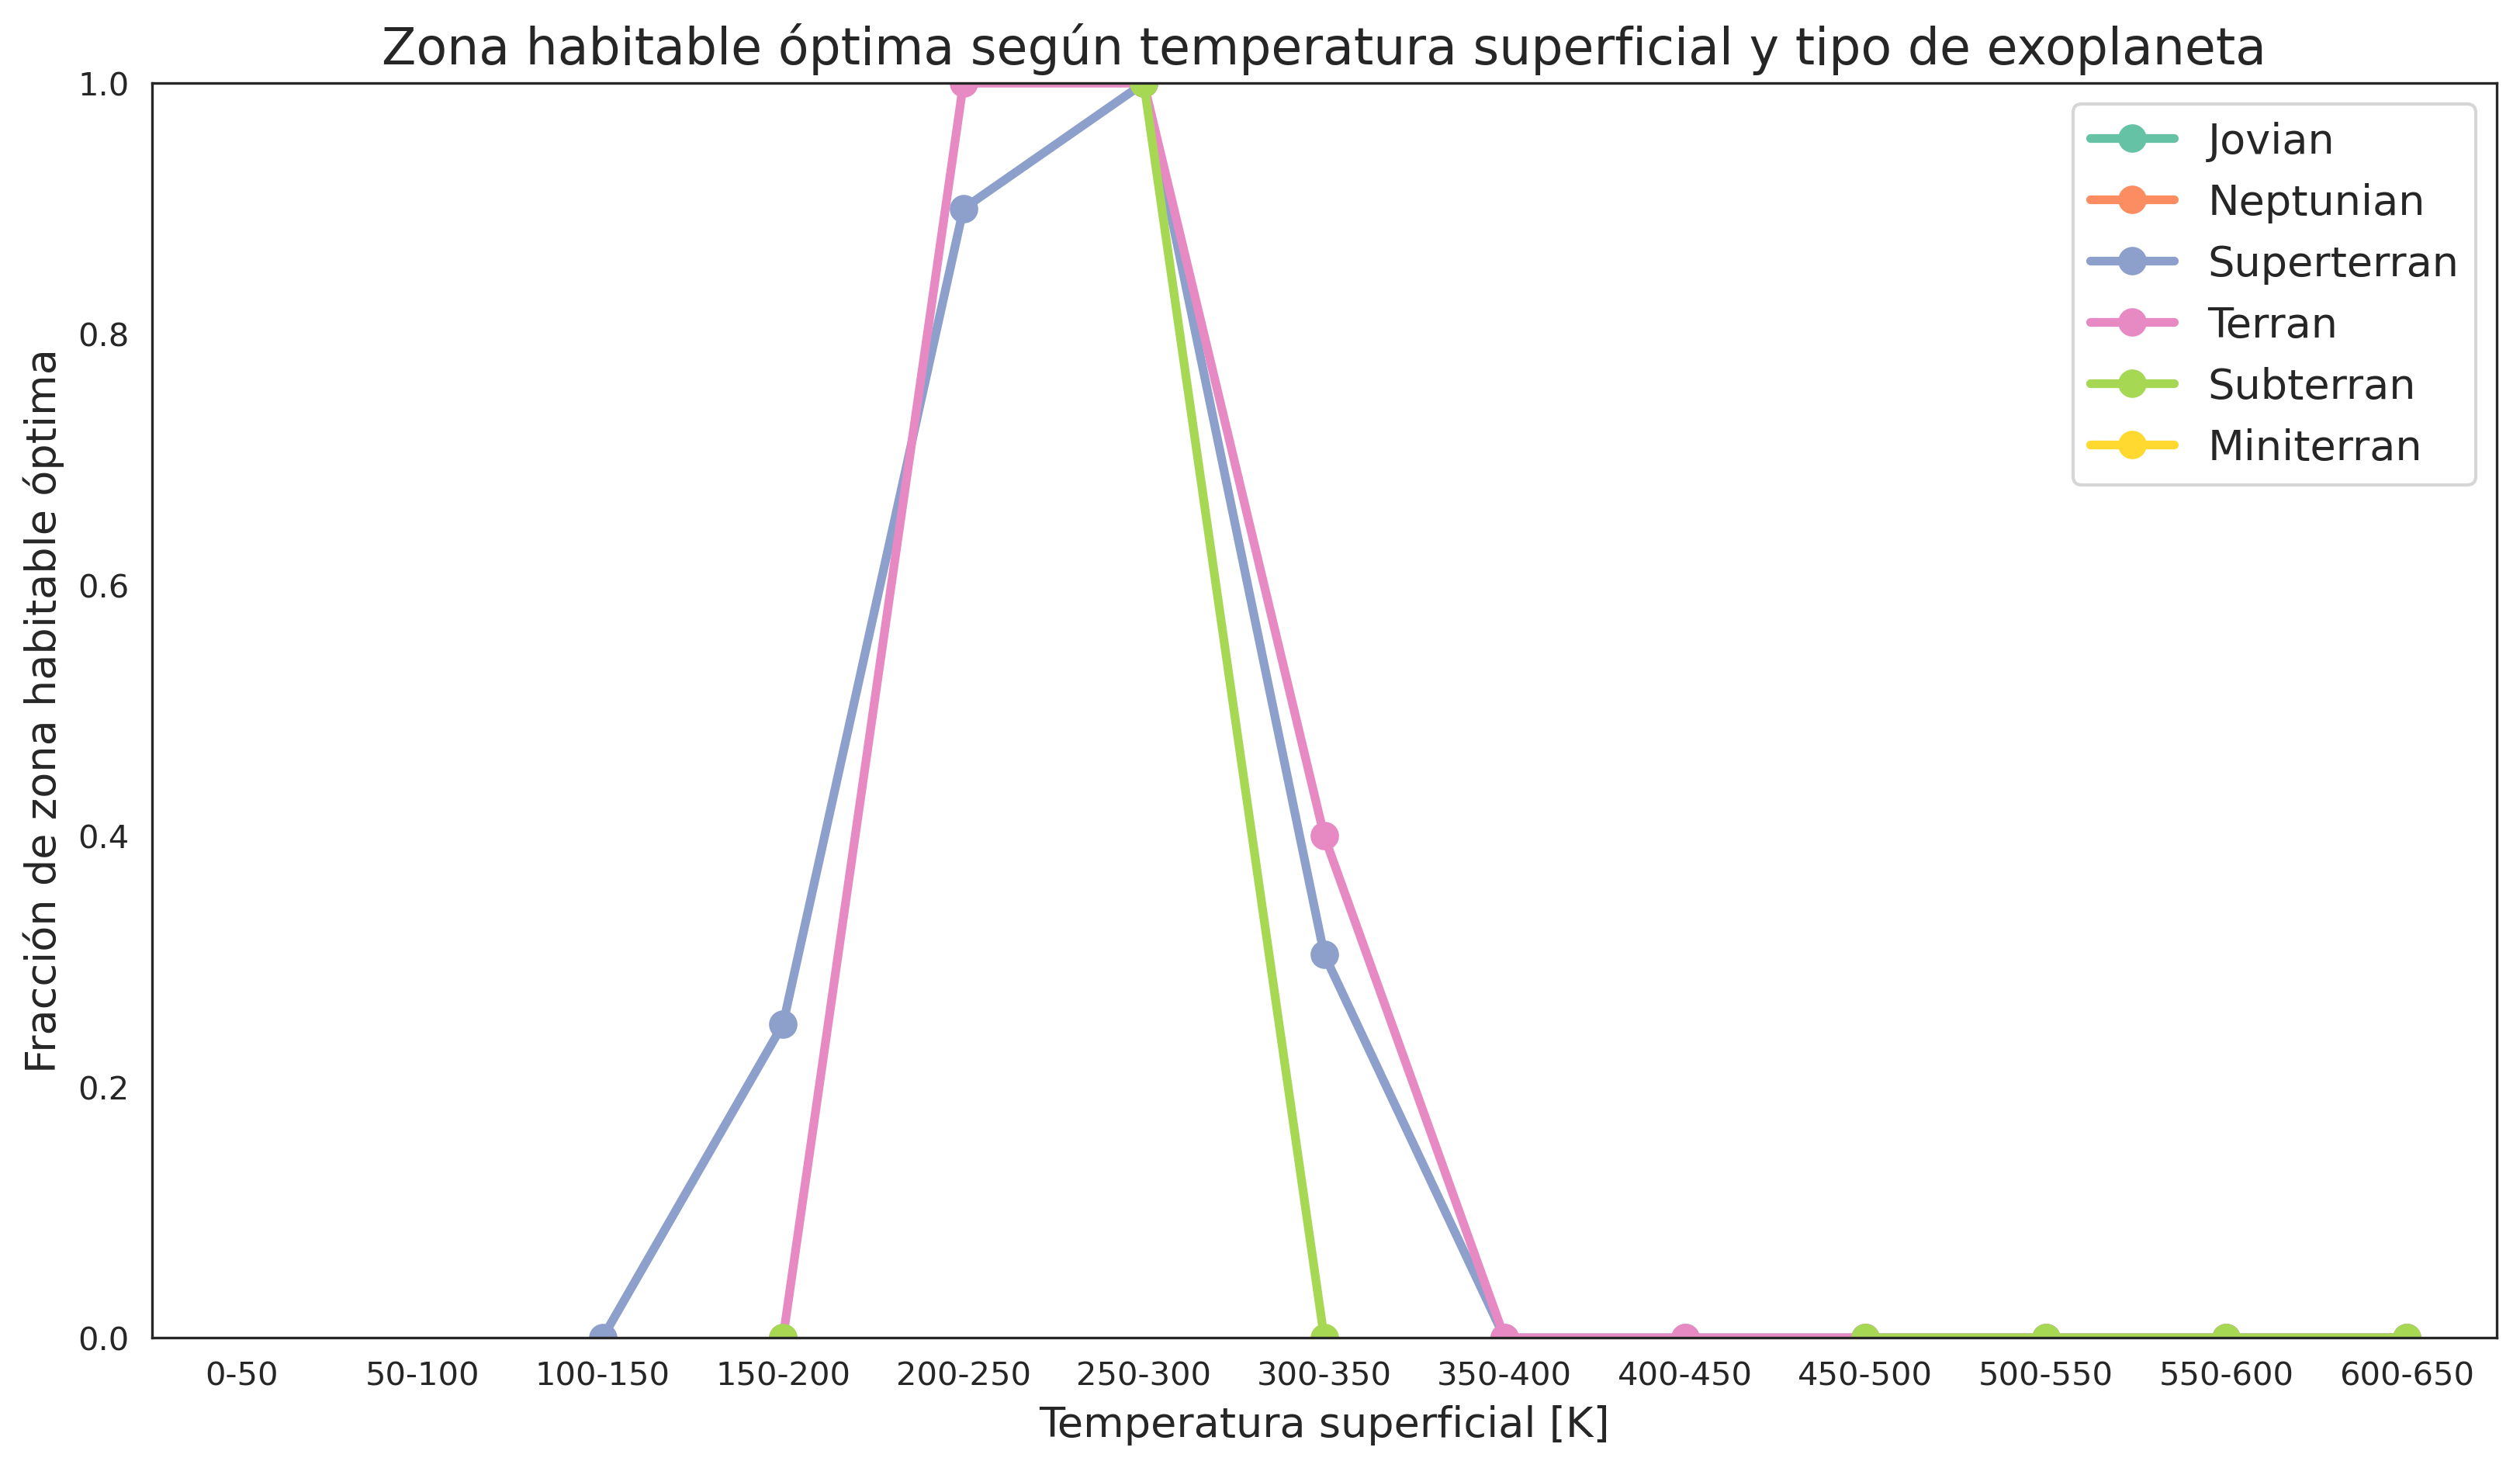

In [63]:
#tal como se hizo en la sección anterior, es conveniente dividir por rangos los valores
bins = [0, 50,100, 150, 200, 250,300,350,400,450,500,550,600,650]
rangos = ["0-50", "50-100","100-150","150-200","200-250", "250-300", "300-350","350-400","400-450","450-500","500-550","550-600","600-650"]
EXO_set["P_TEMP_SURFF"] = pd.cut(EXO_set["P_TEMP_SURF"],bins=bins,labels=rangos) #pd.cut permite agrupar los datos
plt.figure(figsize=(13,7))
sns.pointplot(data=EXO_set,x="P_TEMP_SURFF",y="P_HABZONE_OPT",hue="P_TYPE",palette="Set2",errorbar=None)
plt.xlabel("Temperatura superficial [K]")
plt.ylabel("Fracción de zona habitable óptima")
plt.title("Zona habitable óptima según temperatura superficial y tipo de exoplaneta")
plt.ylim(0,1.0)
plt.legend(loc="upper right",fontsize=13)
plt.show()

**2. Explorando la fracción de zona de habitabilidad según tipo de exoplaneta y distancia.**

- Hay algún patrón que se repite para los tipos de exoplanetas? Sí, se puede ver que hay una temperatura superficial que se repite especialmente para los exoplanetas Terran, SubTerran y SuperTerran, para 250-300 K. Además, para ese rango los exoplanetas se encuentran en una zona habitable óptima en su totalidad.
- La clase de exoplaneta sigue siendo importante dentro de cada rango de temperatura superficial? Quizás, debido a los rangos coincidentes.
- Qué rango parece asociarse con la mayor fracción de zona de habitabilidad óptima? Quizás el rango 200-250 K debido a que para los Terran y SuperTerran la fracción es mayor (al menos mayor al 50%), y además para 250-300 K, como se ha mencionado antes. En general para el rango 200 a 300 K, aproximadamente.

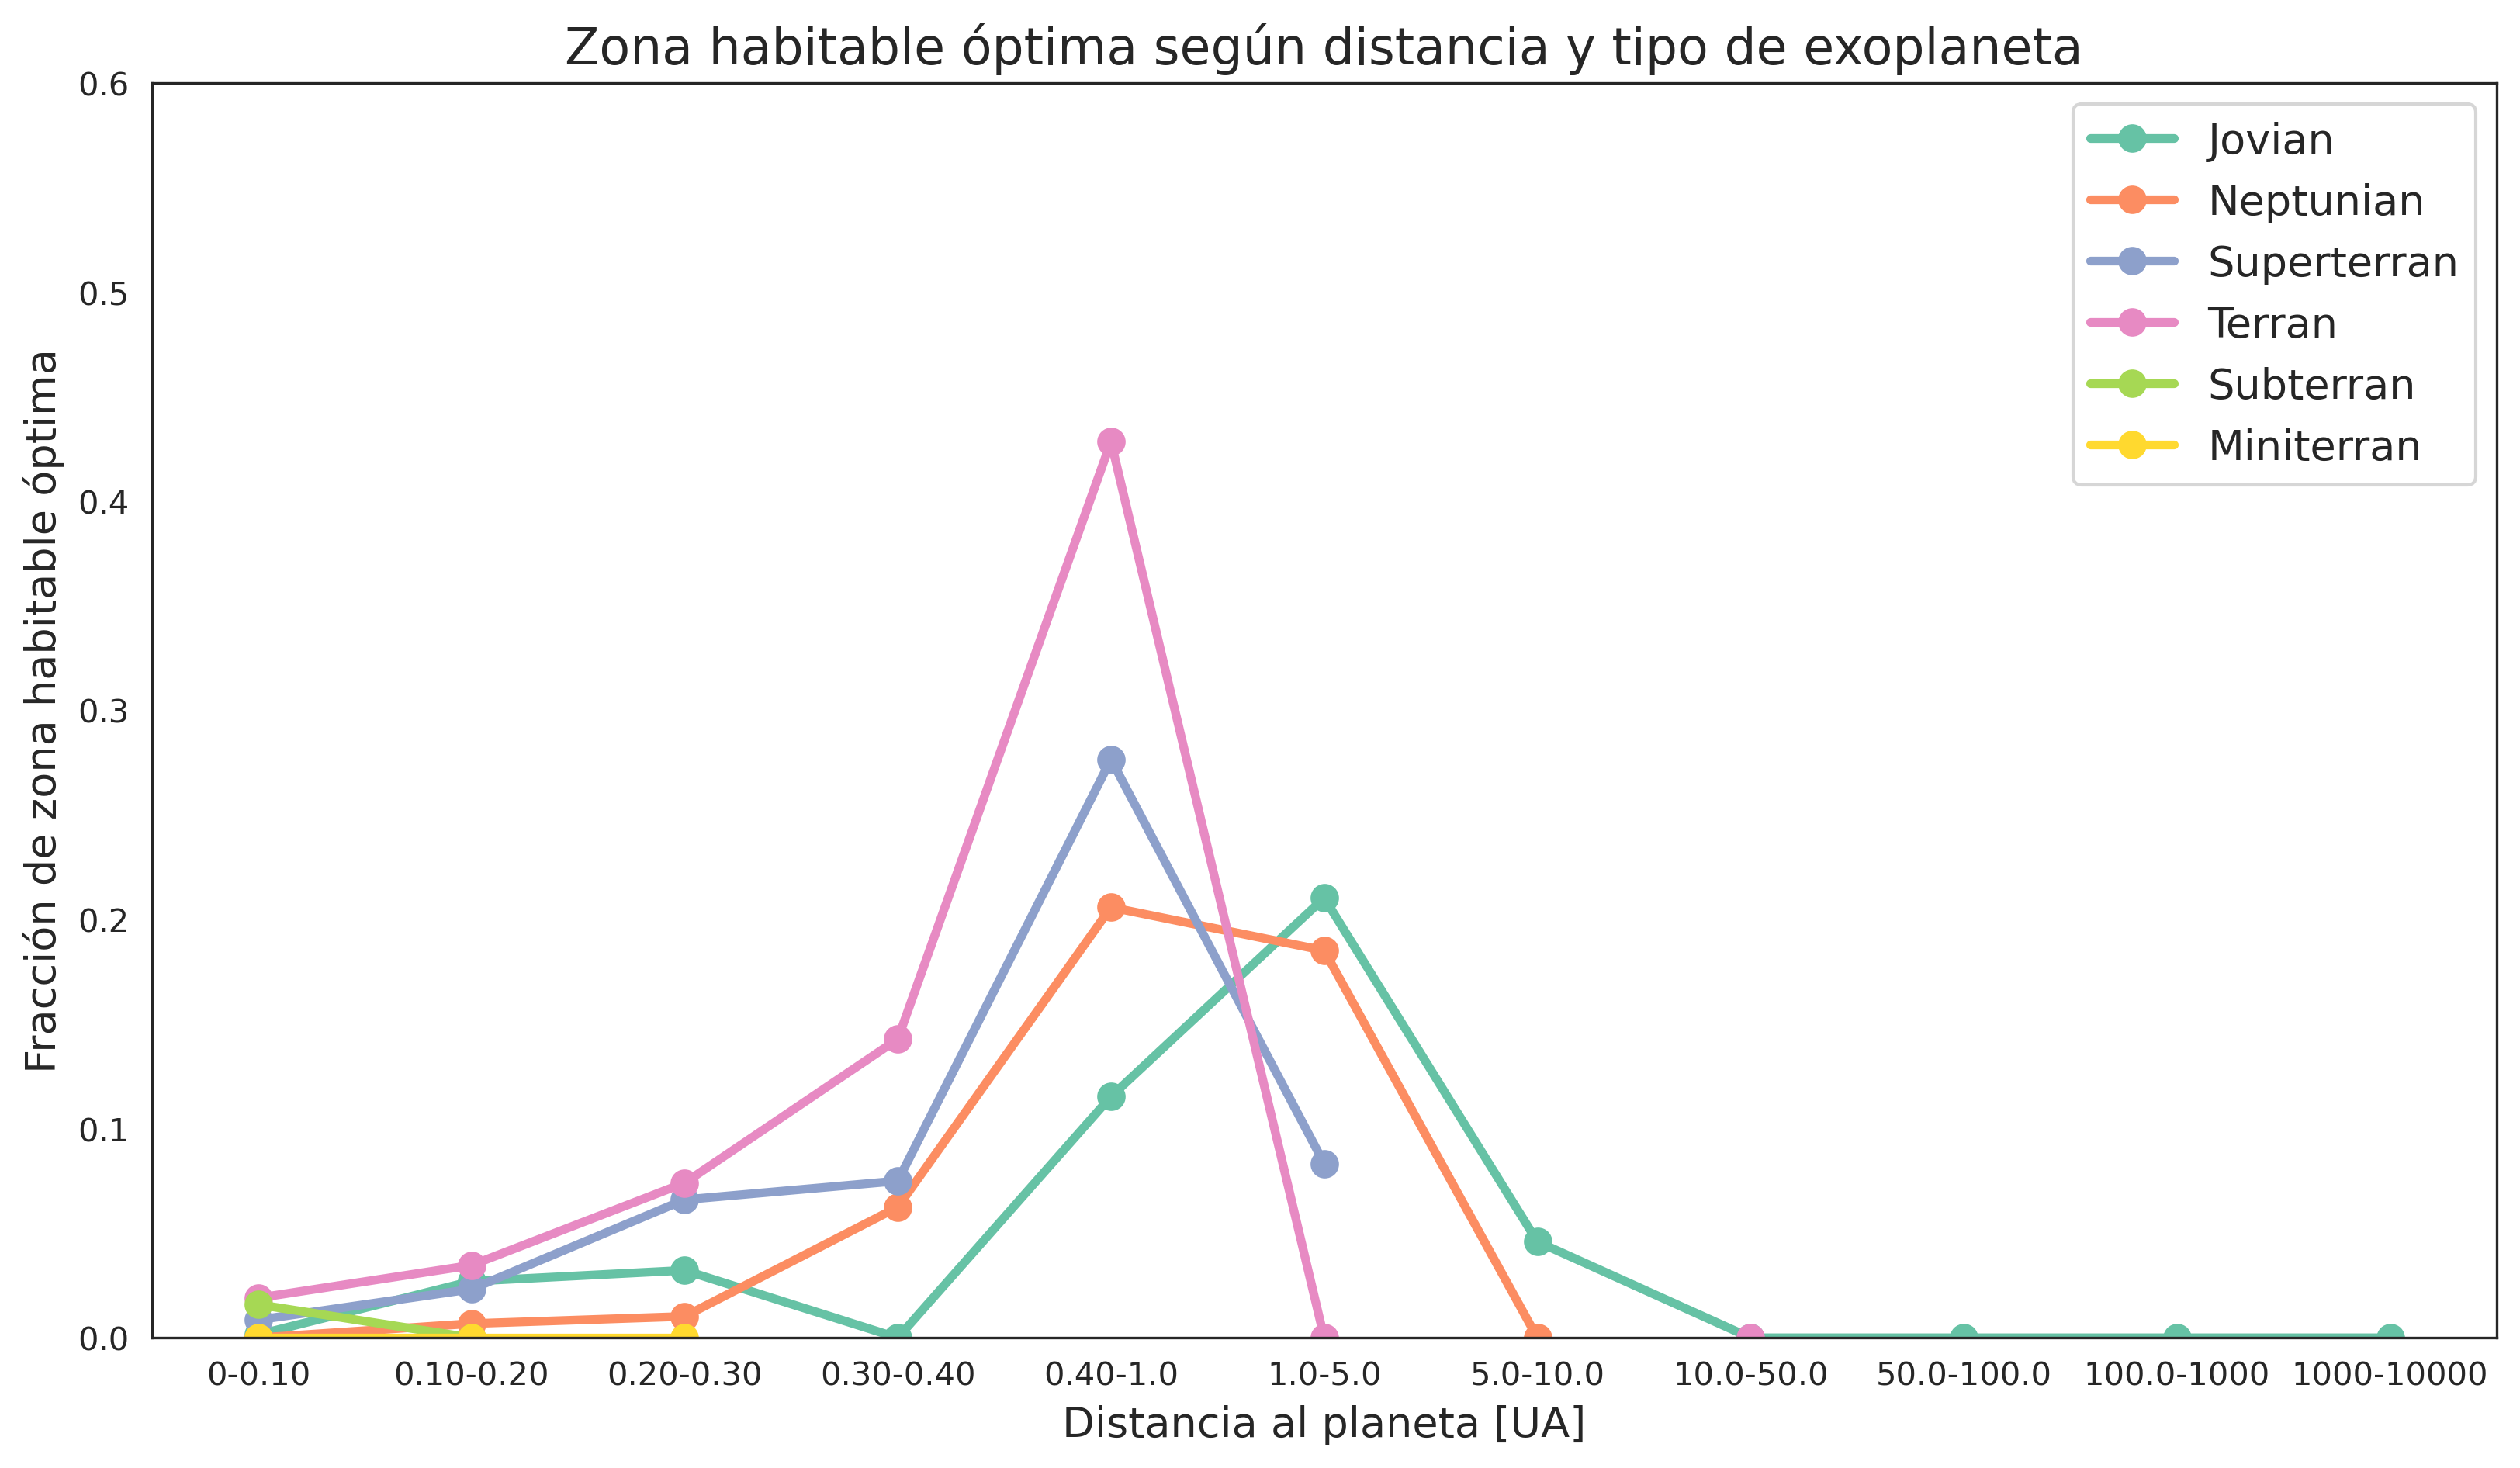

In [64]:
#tal como se hizo en la sección anterior, es conveniente dividir por rangos los valores
bins = [0,0.1,0.2,0.3,0.4,1,5,10,50,100,1000,10000]
rangos = ["0-0.10","0.10-0.20","0.20-0.30","0.30-0.40","0.40-1.0","1.0-5.0","5.0-10.0","10.0-50.0","50.0-100.0","100.0-1000","1000-10000"]
EXO_set["DIST_GROUP"] = pd.cut(EXO_set["P_DISTANCE"],bins=bins,labels=rangos) #pd.cut permite agrupar los datos
plt.figure(figsize=(13,7))
sns.pointplot(data=EXO_set,x="DIST_GROUP",y="P_HABZONE_OPT",hue="P_TYPE",palette="Set2",errorbar=None)
plt.xlabel("Distancia al planeta [UA]")
plt.ylabel("Fracción de zona habitable óptima")
plt.title("Zona habitable óptima según distancia y tipo de exoplaneta")
plt.ylim(0,0.6)
plt.legend(loc="upper right",fontsize=13)
plt.show()

- Como en este caso también se trabajó con rangos pero para distancias, se tiene algún rango que puede asociarse con una zona de habitabilidad óptima? En realidad para los diversos rangos, a lo más para los Terran en distancias de 0.4 a 1.0 UA son óptimas puesto que se alcanza alrededor de 45% como porcentaje de que justamente ese rango sea zona óptima para que el exoplaneta sea habitable. Respecto a los demás, ocurre para los superterran, Neptunian y Jovian, que para el rango 0.4 a 1.0 UA tienen más valor de fracción de zona óptima para habitabilidad, pero quizás no podría concluirse del todo debido a que es menos que el 50% o 0.5. 

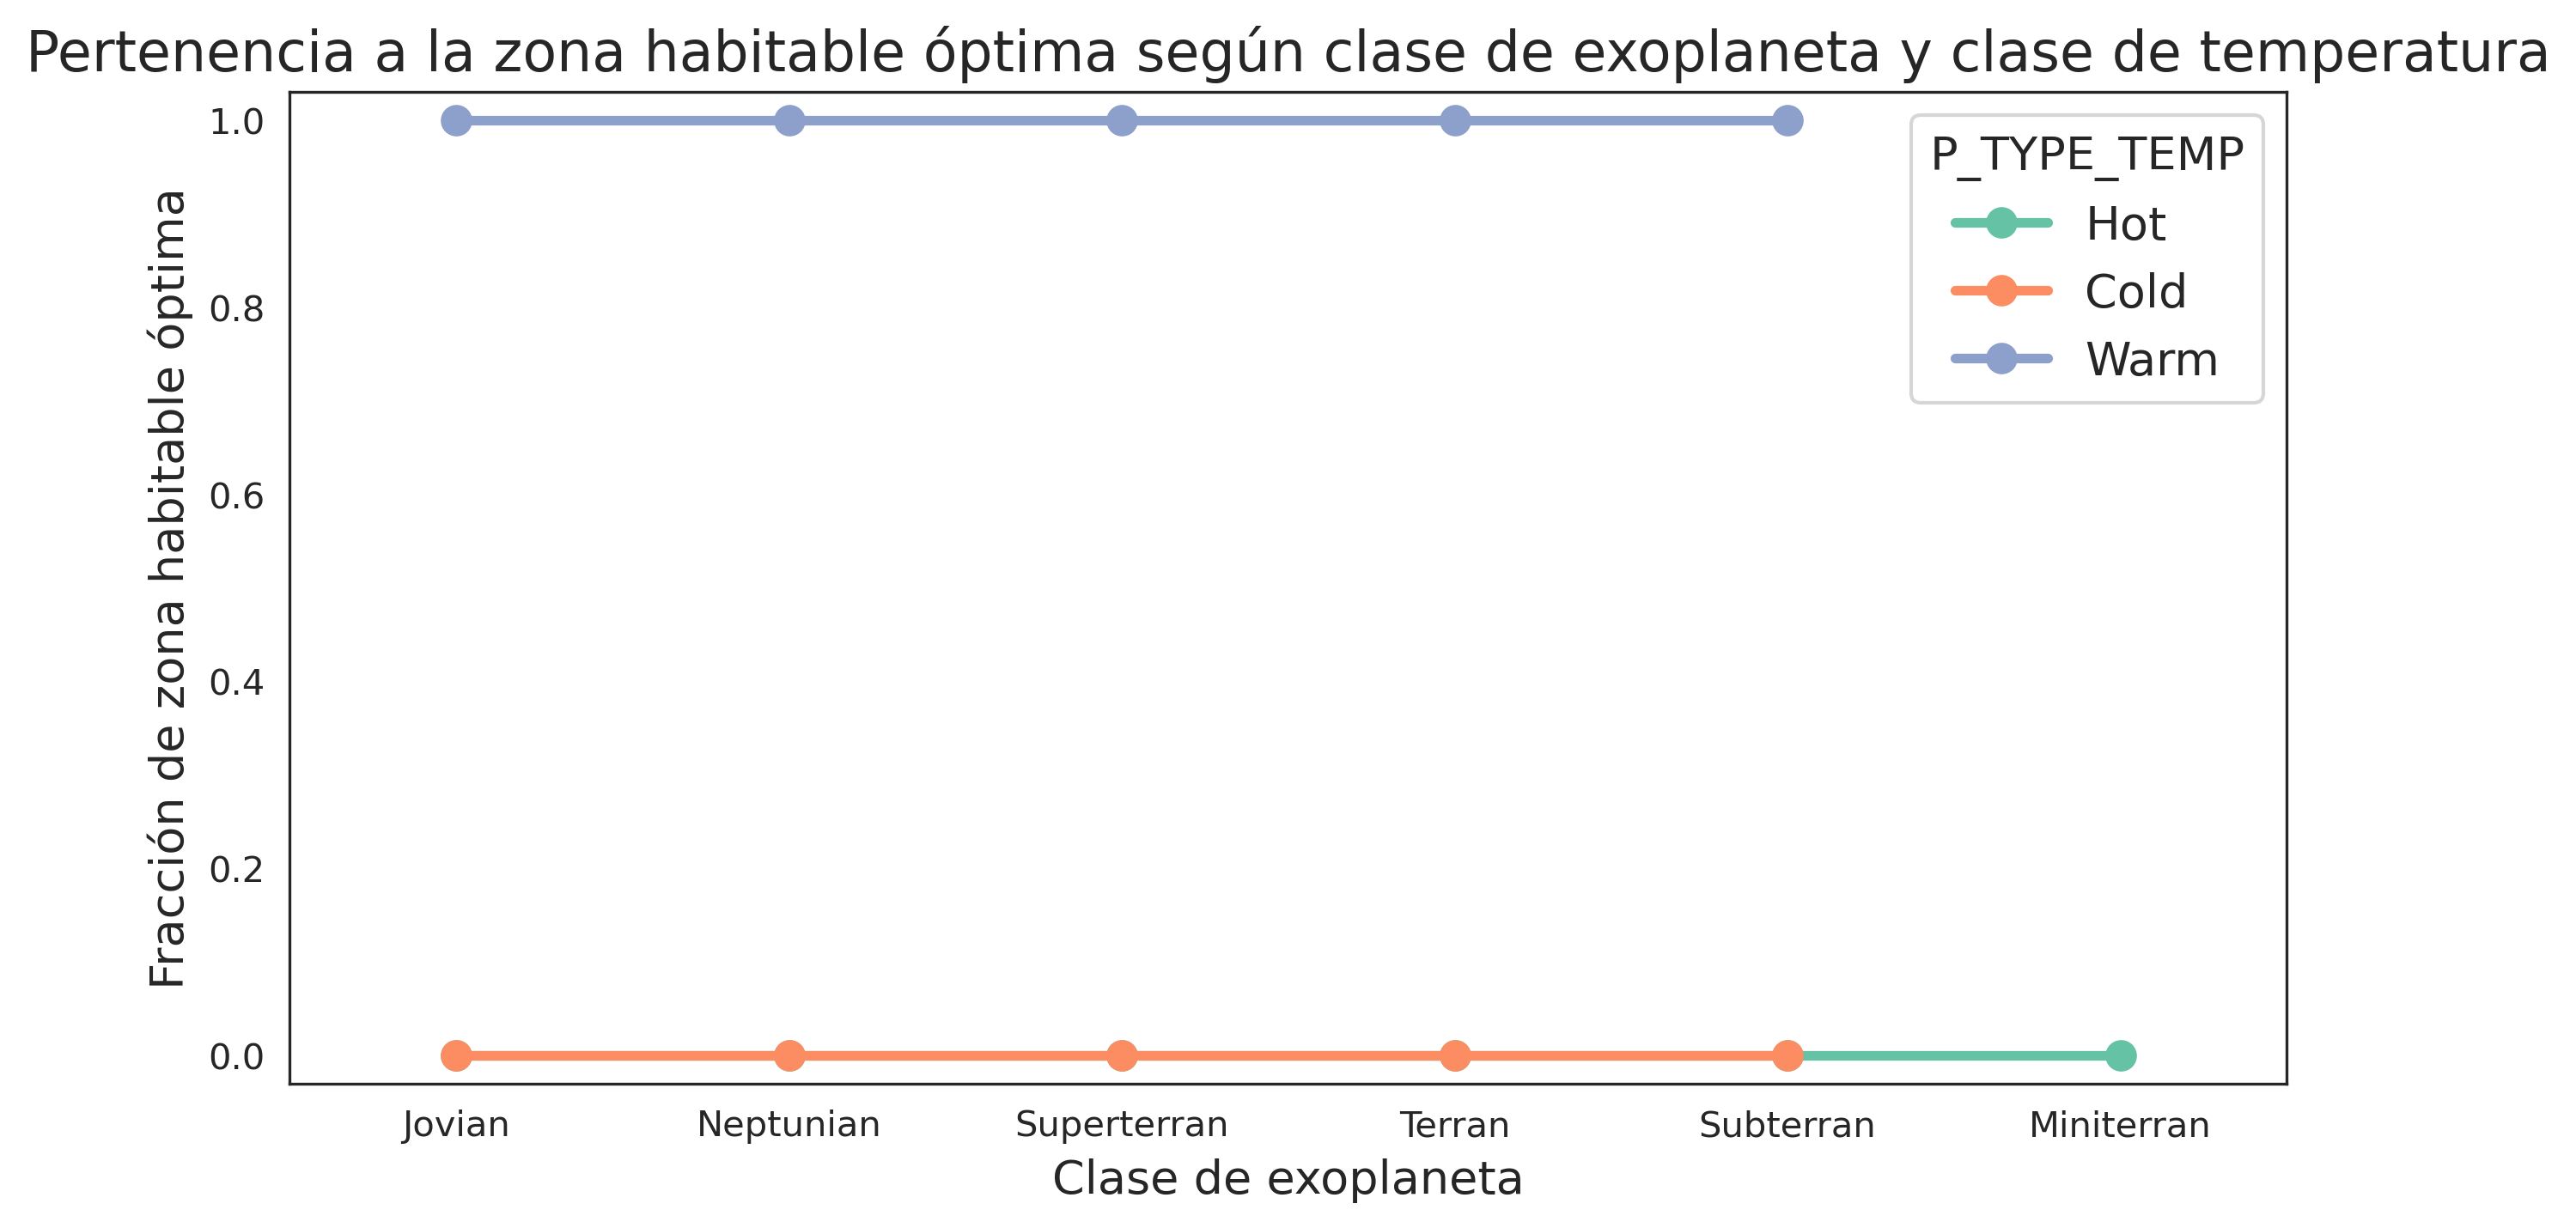

In [65]:
plt.figure(figsize=(10,5))
sns.pointplot(data=EXO_set,x="P_TYPE",y="P_HABZONE_OPT",hue="P_TYPE_TEMP",palette="Set2",errorbar=None)
plt.xlabel("Clase de exoplaneta")
plt.ylabel("Fracción de zona habitable óptima")
plt.title("Pertenencia a la zona habitable óptima según clase de exoplaneta y clase de temperatura")
plt.ylim(-0.03,1.03)
plt.show()

- Cómo son las fracciones para las clases de exoplanetas considerando las clases de temperatura? Se puede ver que tanto los Jovian, Neptunian, Superterran, Terran y Subterran que son Warm se encuentran en un 100% en zona habitable óptimano así para los MiniTerran.

<h2 style="color:#BA55D3; font-family:; text-align:center;font-size:23px">
  Conclusiones
</h2>

¿Qué podemos concluir?

El EDA no termina cuando encontramos diferencias entre grupos.

Queremos distinguir entre:

### Observación
Algo que vemos directamente en los datos.

### Interpretación
Cómo describimos ese patrón.

### Hipótesis
Una explicación posible que debería ser evaluada con más información.

- **Podemos concluir, solo a partir de esta base de datos, que por ejemplo los Subterran sean habitables?** Aún no se puede concluir, dado que a pesar de que posea una temperatura entre 250-300 K, además que pueda ser tibio, para la distancia no hay rango que presente una fracción de zona de habitabilidad óptima mayor al 50% (ejemplo).
- **Qué información adicional necesitaríamos para evaluar esa hipótesis?** Si es que el exoplaneta posee agua líquida, también la composición química de su atmósfera, la temperatura en la noche y en el día, como se comporta el clima, etc.

Alguna figura clave que enfatizar? Podría ser la que relaciona "Zona habitable óptima según temperatura superficial y tipo de exoplaneta", "Zona habitable óptima según temperatura superficial", "Pertenencia a la zona habitable óptima según clase de exoplaneta y clase de temperatura" y "Distancia de los exoplanetas según su clase de temperatura". 
Explique brevemente:
- ¿qué pregunta responde? Entre las figuras se puede responder cuál es la temperatura más típica que considera además exoplanetas Warm y con alto potencial de encontrarse en zonas de habitabilidad óptimas. 
- ¿qué patrón/patrones se muestra/n? Tendencia a rango de temperatura de 250-300 K, a ser Warm, y quizás entre exoplanetas SubTerran, SuperTerran, Terran.
- ¿por qué es importante para su interpretación? Porque ayuda a determinar alguna representación respecto a los exoplanetas con potencial para habitabilidad general, pero de todas formas no se podría concluir aún, pues como se había mencionado, hay otros factores un poco ambiguos.

<h2 style="color:fuchsia; font-family:; text-align:center;font-size:18px">
  Volviendo a las preguntas de desafío y de investigación
</h2>


- ¿La población de exoplanetas observada representa realmente la población de
planetas que existe? Para aquelllo apun falta por indagar, por ejemplo otras relaciones para un futuro problema de ML.

- ¿Qué características tienen los exoplanetas en relación con su habitabilidad?  Aún no se puede concluir, pero de acuerdo a lo visto, las tendencias que se siguen son; tener un rango tentativamente óptimo de temperatura es 250-300 K, especialmente para los SubTerran, Terran y SuperTerran clasificados como Warm y que están en distancias 0.4 a 1 UA respecto a su Sol.

Como parte de encontrar resultados
- Observación: ¿qué muestran directamente los datos?
En general los datos muestran variedad de valores, desde donde se extraen rangos para poder visualizar mejor el comportamiento de diversas clases. Directamente se muestran clases de exoplanetas, clases de temperaturas, además de masas y períodos, como algunas de las categorías estudiadas. 
- Hipótesis: ¿qué posible explicación propone? (Esto se hace para los gráficos arriba)
- Evidencia adicional: ¿qué información necesitaría para evaluar esa hipótesis? En algunas secciones, se requeriría de como es la atmósfera del exoplaneta, por ejemplo.

<h2 style="color:#BA8BAB; font-family:; text-align:center;font-size:23px">
  Posible problema de Machine Learning 
</h2>
A partir de lo obtenido en el EDA para exoplanetas, si continuáramos el trabajo utilizando ML, se puede establecer un problema de predicción que tenga sentido con los datos trabajados. Para un futuro trabajo se tiene;

    • ¿Qué intentariamos predecir? Se puede intentar predecir que los SubTerran, SuperTerran y Terran clasificados como Warm, con temperaturas entre 250-300 K y rangos de distancias hacia su Sol entre 0.4 a 1 UA son potencialmente habitables, dependiendo también de su zona óptima de habitabilidad y de ahí como adicionalmente escoger exoplanetas específicos con sus nombres respectivos para ver si es que en la literatura ha sido investigado.

    • ¿Qué features utilizariamos como información de entrada? Quizás algún factor de agua líquida presente en el exoplaneta, o también si el exoplaneta tiene una atmósfera apropiada de acuerdo a lo que se conoce por la literatura de la atmósfera terrestre, entre otros posibles features.
    
    • ¿Sería un problema de clasificación o de regresión? ¿Por qué? De clasificación, porque se quiere justamente clasificar cuáles exoplanetas serían habitables o no.
    
    • ¿Qué observaciones de su EDA sugieren que podría existir información útil para realizar esa predicción? La observación del rango 250-300 K de temperatura, las fracciones de zona de habitabilidad óptima, los mismos tipos de exoplanetas y su análisis.
    
    • ¿Qué dificultades se podrían presentar? Como se observó, existen datos faltantes, además de variados outliers, además de posibles sesgos por alguna variable.
    (Por ejemplo: datos faltantes, clases desbalanceadas, pocas observaciones, outliers, features muy relacionadas entre sí o posibles sesgos en la muestra.)